In [1]:
# Waveform and Firing Rate Clustering Analysis
# This notebook performs comprehensive clustering analysis combining waveform data with firing rate and bursting metrics

import pynapple as nap
from spikeinterface import load_sorting_analyzer
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import fnmatch
import matplotlib as mpl
import re
import os
from scipy import stats
from sklearn.decomposition import PCA, FastICA
from scipy.linalg import norm
from scipy.stats import kstest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import umap
from scipy.signal import correlate
import warnings
warnings.filterwarnings('ignore')

print("All imports loaded successfully!")


All imports loaded successfully!


In [2]:
nwb_paths = [
    Path("/data_store2/neuropixels/nwb/NP93_B1/NP93_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP95_B1/NP95_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP101_B3/NP101_B3.nwb"),
    Path("/data_store2/neuropixels/nwb/NP105_B1/NP105_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP113_B1/NP113_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP114_B1/NP114_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP116_B2/NP116_B2.nwb"),
    Path("/data_store2/neuropixels/nwb/NP122_B1/NP122_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP128_B1/NP128_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP129_B1/NP129_B1.nwb"),
    #Path("/data_store2/neuropixels/nwb/NP132_B2/NP132_B2.nwb"),
    #Path("/data_store2/neuropixels/nwb/NP132_B3/NP132_B3.nwb"),
    Path("/data_store2/neuropixels/nwb/NP136_B1/NP136_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP137_B1/NP137_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP138_B1/NP138_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP139_B1/NP139_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP139_B2/NP139_B2.nwb"),
    Path("/data_store2/neuropixels/nwb/NP147_B2/NP147_B2.nwb"),
    Path("/data_store2/neuropixels/nwb/NP150_B1/NP150_B1.nwb"),
    Path("/data_store2/neuropixels/nwb/NP153_B1/NP153_B1.nwb"),
]   

manual_exclude_lists = [
    [2], # NP93_B1.imec0
    [], # NP95_B1.imec0
    [], # NP101_B3.imec0
    [130, 150, 151, 245, 371, 375, 377, 380, 386, 452], # NP105_B1.imec0
    [149, 156, 172, 173, 176, 217, 221, 253, 272, 276, 336, 487], # NP113_B1.imec0
    [22, 112, 149, 155, 161, 167, 176, 188, 190, 196, 213, 216, 241, 252, 255, 258, 286, 289, 307, 325, 326, 370, 395, 442, 443, 448, 449, 451, 455, 510, 549, 582, 692, 710, 717, 719, 722, 726, 729], # NP113_B1.imec1
    [385, 448], # NP113_B2.imec2
    [32, 34, 37, 39, 67, 142, 145, 175, 188, 310, 325, 331, 391, 392], # NP114_B1.imec0
    [], # NP116_B2.imec0
    [340, 382], # NP122_B1.imec0
    [54, 109, 152], # NP128_B1.imec0
    [], # NP128_B1.imec1
    [0, 6, 13, 33, 51, 52], # NP129_B1.imec0
    [], # NP132_B2.imec0
    [], # NP132_B3.imec0
    [334, 335], # NP136_B1.imec0
    [361], # NP137_B1.imec0
    [], # NP138_B1.imec0
    [169, 195, 198], # NP138_B1.imec1
    [137, 149, 196, 197, 199, 206, 212, 220, 223, 231], # NP139_B1.imec0
    [129, 248, 249], # NP139_B1.imec1
    [28, 59, 60, 62, 63, 82, 104, 112, 146], # NP139_B2.imec0
    [47, 57, 59, 73, 82, 88, 116, 124, 125, 126, 127, 129, 148, 175, 194, 196, 239, 240, 242, 243, 244, 246, 253, 267], # NP147_B2.imec0
    [], # NP150_B1.imec0
    [34, 64, 119, 135], # NP150_B1.imec1
    [20, 22, 47, 71, 80, 118, 125, 134, 141, 145, 146, 166, 173, 176, 191, 270, 298, 307, 385, 414, 391], # NP153_B1.imec0
]

tipDepth_list = [
    5000, # NP93_B1.imec0
    6600, # NP95_B1.imec0
    5843, # NP101_B3.imec0
    7200, # NP105_B1.imec0
    7600, # NP113_B1.imec0
    7600, # NP113_B1.imec1
    7600, # NP113_B1.imec2
    6900, # NP114_B1.imec0
    6100, # NP116_B2.imec0
    6880, # NP122_B1.imec0
    6200, # NP128_B1.imec0
    6200, # NP128_B1.imec1
    6600, # NP129_B1.imec0
    3820, # NP132_B2.imec0
    3820, # NP132_B3.imec0
    6620, # NP136_B1.imec0
    7000, # NP137_B1.imec0
    7100, # NP138_B1.imec0
    7400, # NP138_B1.imec1
    6900, # NP139_B1.imec0
    7400, # NP139_B1.imec1
    7000, # NP139_B2.imec0
    6400, # NP147_B2.imec0
    6840, # NP150_B1.imec0
    6500, # NP150_B1.imec1
    6500, # NP153_B1.imec0
]

subj_list = [1, 2, 3, 4, 5, 5, 5, 6, 7, 8, 9, 9, 10, 11, 12, 13, 14, 15, 15, 16, 16, 17, 18, 19, 19, 20]
path_list = ['ast', 'ast', 'gbm', 'oli', 'gbm', 'gbm', 'gbm', 'gbm', 'gbm', 'ast', 'ast', 'ast', 'ast', 'oli', 'oli', 'gbm', 'ast', 'ast', 'ast', 'ast', 'ast', 'ast', 'gbm', 'ast', 'ast', 'oli']
grade_list = [4, 4, 4, 3, 4, 4, 4, 4, 4, 3, 2, 2, 4, 2, 2, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 3]
yield_list = [1, 57, 20, 1, 139, 178, 202, 49, 8, 30, 9, 29, 3, 86, 136, 31, 35, 10, 1, 34, 8, 42, 37, 10, 11, 26]
opercular_list = [1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1]
region_list = ['pSTG', 'SFG','aSTG', 'SFG','vPrCG','vPrCG','vPrCG','pSTG','aMTG','MFG','aSTG','parsOp','MFG','PoCG','PoCG','pSTG','vPrCG','vPrCG','aSTG','parsTr','pSTG','parsOr','SMG','parsTr','pSTG','vPrCG']
age_list = [28, 28, 54, 34, 52, 52, 52, 59, 64, 34, 34, 34, 39, 43, 43, 63, 38, 43, 43, 29, 29, 29, 47, 31, 31, 41]
gender_list = [1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0]

def imec_key_sorter(key):
    """Extract the number after 'imec', default to a large number if not found."""
    match = re.search(r'imec(\d+)', key)
    return int(match.group(1)) if match else float('inf')

print(f"Loaded {len(nwb_paths)} NWB files")
print("Helper functions defined")

# Exclude subj_list entries 11 and 12 (0-based: indices 10 and 11) from all lists
exclude_indices = [13, 14]

def exclude_indices_from_list(the_list, indices):
    return [item for idx, item in enumerate(the_list) if idx not in indices]

subj_list = exclude_indices_from_list(subj_list, exclude_indices)
path_list = exclude_indices_from_list(path_list, exclude_indices)
grade_list = exclude_indices_from_list(grade_list, exclude_indices)
yield_list = exclude_indices_from_list(yield_list, exclude_indices)
opercular_list = exclude_indices_from_list(opercular_list, exclude_indices)
region_list = exclude_indices_from_list(region_list, exclude_indices)
age_list = exclude_indices_from_list(age_list, exclude_indices)
gender_list = exclude_indices_from_list(gender_list, exclude_indices)
manual_exclude_lists = exclude_indices_from_list(manual_exclude_lists, exclude_indices)
tipDepth_list = exclude_indices_from_list(tipDepth_list, exclude_indices)
print(len(subj_list))
print(len(grade_list))
print(len(path_list))
print(len(yield_list))
print(len(opercular_list))
print(len(region_list))
print(len(age_list))
print(len(gender_list))
print(len(manual_exclude_lists))

print(region_list)
print(exclude_indices)
print(manual_exclude_lists)

print(subj_list)


Loaded 18 NWB files
Helper functions defined
24
24
24
24
24
24
24
24
24
['pSTG', 'SFG', 'aSTG', 'SFG', 'vPrCG', 'vPrCG', 'vPrCG', 'pSTG', 'aMTG', 'MFG', 'aSTG', 'parsOp', 'MFG', 'pSTG', 'vPrCG', 'vPrCG', 'aSTG', 'parsTr', 'pSTG', 'parsOr', 'SMG', 'parsTr', 'pSTG', 'vPrCG']
[13, 14]
[[2], [], [], [130, 150, 151, 245, 371, 375, 377, 380, 386, 452], [149, 156, 172, 173, 176, 217, 221, 253, 272, 276, 336, 487], [22, 112, 149, 155, 161, 167, 176, 188, 190, 196, 213, 216, 241, 252, 255, 258, 286, 289, 307, 325, 326, 370, 395, 442, 443, 448, 449, 451, 455, 510, 549, 582, 692, 710, 717, 719, 722, 726, 729], [385, 448], [32, 34, 37, 39, 67, 142, 145, 175, 188, 310, 325, 331, 391, 392], [], [340, 382], [54, 109, 152], [], [0, 6, 13, 33, 51, 52], [334, 335], [361], [], [169, 195, 198], [137, 149, 196, 197, 199, 206, 212, 220, 223, 231], [129, 248, 249], [28, 59, 60, 62, 63, 82, 104, 112, 146], [47, 57, 59, 73, 82, 88, 116, 124, 125, 126, 127, 129, 148, 175, 194, 196, 239, 240, 242, 243, 244, 246,

In [3]:
# Bursting capacity metrics based on autocorrelograms
def calculate_autocorrelogram(spike_times, bin_size=0.001, window_size=0.1):
    """
    Calculate autocorrelogram for spike times.
    
    Parameters:
    - spike_times: array of spike times in seconds
    - bin_size: bin size in seconds (default 1ms)
    - window_size: window size in seconds (default 100ms)
    
    Returns:
    - bins: time bins
    - autocorr: autocorrelogram values
    """
    if len(spike_times) < 2:
        return np.array([0]), np.array([0])
    
    # Create bins
    bins = np.arange(-window_size, window_size + bin_size, bin_size)
    
    # Calculate autocorrelogram
    autocorr = np.zeros(len(bins) - 1)
    
    for i, spike_time in enumerate(spike_times):
        # Find all other spikes
        other_spikes = np.concatenate([spike_times[:i], spike_times[i+1:]])
        
        # Calculate time differences
        time_diffs = other_spikes - spike_time
        
        # Bin the differences
        hist, _ = np.histogram(time_diffs, bins=bins)
        autocorr += hist
    
    # Normalize by number of spikes
    autocorr = autocorr / len(spike_times)
    
    return bins[:-1], autocorr

def calculate_bursting_metrics(spike_times, bin_size=0.001, window_size=0.1):
    """
    Calculate multiple bursting capacity metrics from autocorrelogram.
    
    Returns a dictionary with various bursting metrics:
    1. Burst Index: ratio of short-interval spikes to long-interval spikes
    2. Refractory Period Violation: spikes in refractory period
    3. Burst Peak Height: height of the first peak after time 0
    4. Burst Peak Width: width of the first peak
    5. Autocorr Skewness: skewness of the autocorrelogram
    6. Short ISI Ratio: ratio of ISIs < 10ms to total ISIs
    """
    if len(spike_times) < 10:  # Need sufficient spikes for reliable metrics
        return {
            'burst_index': 0,
            'refractory_violation': 0,
            'burst_peak_height': 0,
            'burst_peak_width': 0,
            'autocorr_skewness': 0,
            'short_isi_ratio': 0,
            'autocorr_vector': np.zeros(200)  # Fixed size for consistency
        }
    
    # Calculate autocorrelogram
    bins, autocorr = calculate_autocorrelogram(spike_times, bin_size, window_size)
    
    # Find center bin (time = 0)
    center_idx = len(bins) // 2
    
    # 1. Burst Index: ratio of short-interval spikes (1-10ms) to long-interval spikes (50-100ms)
    short_window = (bins >= 0.001) & (bins <= 0.010)  # 1-10ms
    long_window = (bins >= 0.050) & (bins <= 0.100)   # 50-100ms
    
    short_count = np.sum(autocorr[short_window])
    long_count = np.sum(autocorr[long_window])
    burst_index = short_count / (long_count + 1e-10)  # Add small value to avoid division by zero
    
    # 2. Refractory Period Violation: spikes in 0-2ms window
    refractory_window = (bins >= 0) & (bins <= 0.002)
    refractory_violation = np.sum(autocorr[refractory_window])
    
    # 3. Burst Peak Height: height of the first peak after time 0
    # Look for peaks in the 1-20ms window
    peak_window = (bins >= 0.001) & (bins <= 0.020)
    if np.any(peak_window):
        burst_peak_height = np.max(autocorr[peak_window])
    else:
        burst_peak_height = 0
    
    # 4. Burst Peak Width: width at half height of the first peak
    if burst_peak_height > 0:
        half_height = burst_peak_height / 2
        # Fix the indexing issue - use the correct window for peak_indices
        peak_indices = np.where(autocorr[peak_window] >= half_height)[0]
        if len(peak_indices) > 0:
            burst_peak_width = (np.max(peak_indices) - np.min(peak_indices)) * bin_size
        else:
            burst_peak_width = 0
    else:
        burst_peak_width = 0
    
    # 5. Autocorr Skewness: skewness of the autocorrelogram
    autocorr_skewness = stats.skew(autocorr)
    
    # 6. Short ISI Ratio: ratio of ISIs < 10ms to total ISIs
    isis = np.diff(spike_times)
    short_isis = np.sum(isis < 0.010)
    total_isis = len(isis)
    short_isi_ratio = short_isis / (total_isis + 1e-10)
    
    # Create a standardized autocorr vector (fixed size for consistency)
    autocorr_vector = np.zeros(200)
    if len(autocorr) > 0:
        # Interpolate to fixed size
        autocorr_vector = np.interp(np.linspace(0, len(autocorr)-1, 200), 
                                  np.arange(len(autocorr)), autocorr)
    
    return {
        'burst_index': burst_index,
        'refractory_violation': refractory_violation,
        'burst_peak_height': burst_peak_height,
        'burst_peak_width': burst_peak_width,
        'autocorr_skewness': autocorr_skewness,
        'short_isi_ratio': short_isi_ratio,
        'autocorr_vector': autocorr_vector
    }

print("Bursting metrics functions defined")


Bursting metrics functions defined


In [4]:
# MAIN LOOP TO EXTRACT WAVEFORMS, FIRING RATES, AND COMPREHENSIVE METRICS
print("Starting data extraction from all sessions...")

# Initialize data storage lists
indicesAll = []
firingRatesAll = []
waveformAll = []
depthAll = []
burstingMetricsAll = []
autocorrVectorsAll = []
# NEW: Store spike times for comprehensive analysis
spikeTimesAll = []

insertion = 0

for i in range(len(nwb_paths)):
    print(f"\nProcessing session {i+1}/{len(nwb_paths)}: {nwb_paths[i].name}")
    
    try:
        # Load NWB file
        data = nap.load_file(nwb_paths[i])
        keys = data.keys()

        # Filter keys similar to reference file
        template = "*imec*"
        keys = [key for key in keys if fnmatch.fnmatch(key, template)]
        ks_keys = [key for key in keys if "KS4" in key]
        if ks_keys:
            keys = ks_keys
        th8_keys = [key for key in keys if "Th=8" in key]
        if th8_keys:
            keys = th8_keys
        else:
            th_keys = [key for key in keys if "Th=" in key]
            if th_keys:
                keys = th_keys
        template_sentgen = "*sentgen*"
        template_auto = "*_auto*"
        keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
        # For NP137, remove 'imec1'
        if ('NP137' in str(nwb_paths[i])) or ('NP139_B2' in str(nwb_paths[i])):
            keys = [key for key in keys if 'imec1' not in key]
        keys = sorted(keys, key=imec_key_sorter)

        for s in range(len(keys)):
            print(f"Processing {keys[s]}")
            
            spike_times = data[keys[s]]

            # Get firing rates and task times
            firingRates_all = spike_times.metadata["rate"]
            task_times = data["TaskTimes"]
            beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)
            spike_times_beh = spike_times.restrict(beh_epochs)
            firingRates_beh = spike_times_beh.metadata["rate"]

            # Quality checks (KS test, violation percentage)
            start_time = task_times.start
            end_time = task_times.end
            ks_stats = np.zeros(len(spike_times))
            ks_pvals = np.zeros(len(spike_times))
            for u in range(len(spike_times)):
                test = spike_times[u].as_series().index.values
                if len(test) > 1:
                    min_time = start_time[0]
                    max_time = end_time[-1]
                    normalized_spike_times = (test - min_time) / (max_time - min_time)
                    ks_result = kstest(normalized_spike_times, 'uniform')
                    ks_stats[u] = ks_result.statistic
                    ks_pvals[u] = ks_result.pvalue
                else:
                    ks_stats[u] = np.nan
                    ks_pvals[u] = np.nan

            violationThreshold = 3 / 1000
            violationPct = np.zeros(len(spike_times))
            for u in range(len(spike_times)):
                unit = spike_times[u]
                unit = unit.as_series().index
                if len(unit) < 100:
                    violationPct[u] = 1
                else:
                    isi = unit.diff()[1:]
                    violations = np.where(isi < violationThreshold)
                    violations = np.array(violations)
                    violationPct[u] = violations.size / len(isi)

            # Apply quality filters
            if "KSLabel" in spike_times.metadata:
                KSLabels = spike_times.metadata["KSLabel"]
            else:
                KSLabels = spike_times.metadata["quality"]
            firingRates = firingRates_beh
            mask1 = violationPct < 3 / 100
            mask2 = firingRates > 0.5
            mask3 = KSLabels != "noise"
            mask4 = ks_stats < 0.3
            mask = mask1 & mask2 & mask3 & mask4
            indicesFinal = firingRates.index[mask]

            # Exclude manually rejected neurons
            indicesFinal = np.setdiff1d(indicesFinal, manual_exclude_lists[insertion])
            insertion += 1
            spike_times_good = spike_times[indicesFinal]
            print(f"Number of good neurons: {len(spike_times_good)}")

            if len(spike_times_good) == 0:
                print("No good neurons found, skipping session")
                continue

            # Get waveform and depth data
            kilosort_run = f'{keys[s]}_sparse'
            rec_id = os.path.basename(nwb_paths[i])  
            rec_id = os.path.splitext(rec_id)[0] 
            analyzer_path = f'/data_store2/neuropixels/nwb/{rec_id}/SI/{kilosort_run}'
            
            if not os.path.exists(analyzer_path):
                print(f"Analyzer path not found: {analyzer_path}")
                continue
                
            analyzer = load_sorting_analyzer(analyzer_path)
            templates = analyzer.get_extension("templates")
            avg_templates = templates.get_data(operator="average")

            waveform_list = []
            depth_list = []
            firing_rates_list = []
            bursting_metrics_list = []
            autocorr_vectors_list = []
            spike_times_list = []  # NEW: Store spike times for comprehensive analysis
            
            for unit_id in indicesFinal:
                # Get waveform
                template = avg_templates[unit_id]
                max_amp_per_channel = np.max(np.abs(template), axis=0)
                max_amp_ch = np.argmax(max_amp_per_channel)
                waveform = template[:, max_amp_ch]
                waveform_list.append(waveform)
                
                # Get depth - handle indexing properly
                try:
                    depths = analyzer.get_extension('unit_locations').get_data()[:,1]
                    depth = tipDepth_list[insertion-1] - depths[unit_id]
                except:
                    depth = -999  # make fall back obvious
                
                depth_list.append(depth)
                
                # Get firing rate
                firing_rate = firingRates.loc[unit_id]
                firing_rates_list.append(firing_rate)
                
                # Calculate bursting metrics
                spike_times_unit = spike_times_good[unit_id].as_series().index.values
                bursting_metrics = calculate_bursting_metrics(spike_times_unit)
                bursting_metrics_list.append(bursting_metrics)
                autocorr_vectors_list.append(bursting_metrics['autocorr_vector'])
                
                # NEW: Store spike times for comprehensive analysis
                spike_times_list.append(spike_times_unit)
            
            # Store data
            indicesAll.append(indicesFinal)
            firingRatesAll.append(firing_rates_list)
            waveformAll.append(waveform_list)
            depthAll.append(depth_list)
            burstingMetricsAll.append(bursting_metrics_list)
            autocorrVectorsAll.append(autocorr_vectors_list)
            spikeTimesAll.append(spike_times_list)  # NEW: Store spike times
            
    except Exception as e:
        print(f"Error processing session {i+1}: {e}")
        import traceback
        traceback.print_exc()
        continue

print(f"\nData extraction complete!")
print(f"Processed {insertion} sessions successfully")
print(f"Total waveforms: {sum(len(w) for w in waveformAll)}")
print(f"Total firing rate measurements: {sum(len(f) for f in firingRatesAll)}")
print(f"Total bursting metric measurements: {sum(len(b) for b in burstingMetricsAll)}")
print(f"Total spike time measurements: {sum(len(s) for s in spikeTimesAll)}")  # NEW


Starting data extraction from all sessions...

Processing session 1/18: NP93_B1.nwb
Processing NP93_B1_g0_imec0_withoutKSmc
Number of good neurons: 1

Processing session 2/18: NP95_B1.nwb
Processing NP95_B1_g0_imec1
Number of good neurons: 57

Processing session 3/18: NP101_B3.nwb
Processing NP101_B3_g0_imec0
Number of good neurons: 20

Processing session 4/18: NP105_B1.nwb
Processing NP105_B1_g0_imec0
Number of good neurons: 1

Processing session 5/18: NP113_B1.nwb
Processing NP113_B1_g0_imec0_KS4_Th=8
Number of good neurons: 139
Processing NP113_B1_g0_imec1_KS4_Th=8
Number of good neurons: 178
Processing NP113_B1_g0_imec2_KS4_Th=8
Number of good neurons: 202

Processing session 6/18: NP114_B1.nwb
Processing NP114_B1_g0_imec0
Number of good neurons: 49

Processing session 7/18: NP116_B2.nwb
Processing NP116_B2_g0_imec0
Number of good neurons: 8

Processing session 8/18: NP122_B1.nwb
Processing NP122_B1_g0_imec0
Number of good neurons: 30

Processing session 9/18: NP128_B1.nwb
Processi

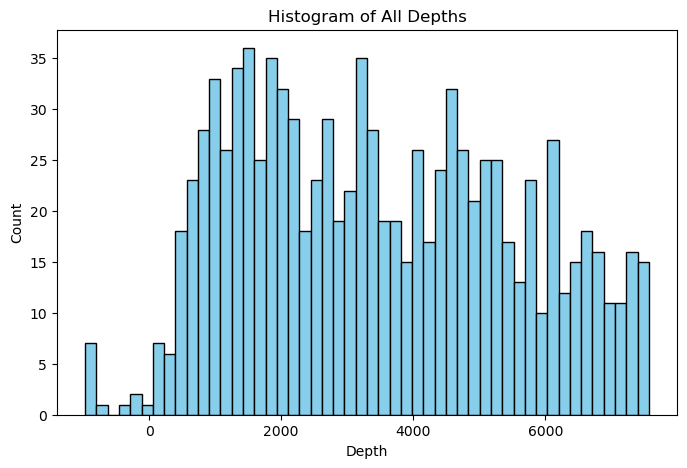

Insertion IDs with depth > 0: [8, 13, 20, 23]
Neuron (insertion_idx, neuron_idx) with depth > 0: [(8, 6), (13, 30), (20, 30), (20, 31), (20, 32), (20, 33), (20, 34), (20, 35), (20, 36), (23, 22), (23, 23), (23, 24)]


In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist([d for session_depths in depthAll for d in session_depths], bins=50, color='skyblue', edgecolor='k')
plt.xlabel('Depth')
plt.ylabel('Count')
plt.title('Histogram of All Depths')
plt.show()

# Find the insertion indices where any neuron has depth > 0
insertion_ids_with_depth_gt_0 = []
for i, session_depths in enumerate(depthAll):
    if any(d < 0 for d in session_depths):
        insertion_ids_with_depth_gt_0.append(i)
print("Insertion IDs with depth > 0:", insertion_ids_with_depth_gt_0)

# Find the indices (in terms of insertion index and neuron index) where neuron depth > 0
neuron_ids_with_depth_gt_0 = []
for insertion_idx, session_depths in enumerate(depthAll):
    for neuron_idx, d in enumerate(session_depths):
        if d < 0:
            neuron_ids_with_depth_gt_0.append((insertion_idx, neuron_idx))
print("Neuron (insertion_idx, neuron_idx) with depth > 0:", neuron_ids_with_depth_gt_0)



In [6]:
# PREPARE DATA FOR CLUSTERING
print("\n=== PREPARING DATA FOR CLUSTERING ===")

# Flatten all data into single arrays
waveforms_flat = []
firing_rates_flat = []
bursting_metrics_flat = []
autocorr_vectors_flat = []
spike_times_flat = []  # NEW: Flatten spike times
metadata_flat = []

for insertion_idx in range(len(waveformAll)):
    for neuron_idx in range(len(waveformAll[insertion_idx])):
        waveforms_flat.append(waveformAll[insertion_idx][neuron_idx])
        firing_rates_flat.append(firingRatesAll[insertion_idx][neuron_idx])
        bursting_metrics_flat.append(burstingMetricsAll[insertion_idx][neuron_idx])
        autocorr_vectors_flat.append(autocorrVectorsAll[insertion_idx][neuron_idx])
        spike_times_flat.append(spikeTimesAll[insertion_idx][neuron_idx])  # NEW
        
        metadata_flat.append({
            'insertion_idx': insertion_idx,
            'subj': subj_list[insertion_idx],
            'grade': grade_list[insertion_idx],
            'pathology': path_list[insertion_idx],
            'yield': yield_list[insertion_idx],
            'opercular': opercular_list[insertion_idx],
            'region': region_list[insertion_idx],
            'age': age_list[insertion_idx],
            'gender': gender_list[insertion_idx],
            'depth': depthAll[insertion_idx][neuron_idx]
        })

# Convert to numpy arrays
waveforms_array = np.array(waveforms_flat)
firing_rates_array = np.array(firing_rates_flat)
autocorr_vectors_array = np.array(autocorr_vectors_flat)

print(f"Total neurons: {len(waveforms_flat)}")
print(f"Waveform array shape: {waveforms_array.shape}")
print(f"Firing rates array shape: {firing_rates_array.shape}")
print(f"Autocorr vectors array shape: {autocorr_vectors_array.shape}")
print(f"Spike times data: {len(spike_times_flat)} neurons")  # NEW

# Extract individual bursting metrics
burst_indices = np.array([bm['burst_index'] for bm in bursting_metrics_flat])
refractory_violations = np.array([bm['refractory_violation'] for bm in bursting_metrics_flat])
burst_peak_heights = np.array([bm['burst_peak_height'] for bm in bursting_metrics_flat])
burst_peak_widths = np.array([bm['burst_peak_width'] for bm in bursting_metrics_flat])
autocorr_skewness = np.array([bm['autocorr_skewness'] for bm in bursting_metrics_flat])
short_isi_ratios = np.array([bm['short_isi_ratio'] for bm in bursting_metrics_flat])

print(f"\nBursting metrics extracted:")
print(f"Burst indices: mean={np.mean(burst_indices):.3f}, std={np.std(burst_indices):.3f}")
print(f"Refractory violations: mean={np.mean(refractory_violations):.3f}, std={np.std(refractory_violations):.3f}")
print(f"Burst peak heights: mean={np.mean(burst_peak_heights):.3f}, std={np.std(burst_peak_heights):.3f}")
print(f"Burst peak widths: mean={np.mean(burst_peak_widths):.3f}, std={np.std(burst_peak_widths):.3f}")
print(f"Autocorr skewness: mean={np.mean(autocorr_skewness):.3f}, std={np.std(autocorr_skewness):.3f}")
print(f"Short ISI ratios: mean={np.mean(short_isi_ratios):.3f}, std={np.std(short_isi_ratios):.3f}")

# Standardize waveforms
waveform_scaler = StandardScaler()
waveforms_scaled = waveform_scaler.fit_transform(waveforms_array)
print(f"\nWaveforms standardized: shape={waveforms_scaled.shape}")

# Prepare spiking data (firing rates + bursting metrics)
spiking_data = np.column_stack([
    firing_rates_array,
    burst_indices,
    refractory_violations,
    burst_peak_heights,
    burst_peak_widths,
    autocorr_skewness,
    short_isi_ratios
])

# Standardize spiking data
spiking_scaler = StandardScaler()
spiking_data_scaled = spiking_scaler.fit_transform(spiking_data)
print(f"Spiking data standardized: shape={spiking_data_scaled.shape}")

# Prepare combined data (waveforms + spiking metrics)
# First standardize each component separately, then combine
combined_data = np.column_stack([
    waveforms_scaled,
    spiking_data_scaled
])

print(f"Combined data prepared: shape={combined_data.shape}")
print("Data preparation complete!")



=== PREPARING DATA FOR CLUSTERING ===
Total neurons: 971
Waveform array shape: (971, 90)
Firing rates array shape: (971,)
Autocorr vectors array shape: (971, 200)
Spike times data: 971 neurons

Bursting metrics extracted:
Burst indices: mean=0.221, std=0.293
Refractory violations: mean=0.004, std=0.004
Burst peak heights: mean=0.019, std=0.021
Burst peak widths: mean=0.013, std=0.005
Autocorr skewness: mean=0.083, std=1.868
Short ISI ratios: mean=0.072, std=0.066

Waveforms standardized: shape=(971, 90)
Spiking data standardized: shape=(971, 7)
Combined data prepared: shape=(971, 97)
Data preparation complete!


In [7]:
# COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS
# Based on literature review for distinguishing interneurons vs pyramidal neurons

print("\n=== COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS ===")
print("Selected metrics based on literature review:")
print("Waveform: Spike Width, Amplitude, Asymmetry, Rise Time, Decay Time")
print("Firing Rate: Mean Firing Rate, Burst Index, ISI CV, ISI Violation Rate, Spike Frequency Adaptation")

# Import additional libraries for comprehensive analysis
from sklearn.mixture import GaussianMixture
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.patches as mpatches

def calculate_spike_width(waveform):
    """Calculate spike width (trough-to-peak duration)"""
    # Find peak and trough
    peak_idx = np.argmax(waveform)
    trough_idx = np.argmin(waveform)
    
    # Calculate width in samples (assuming 30kHz sampling rate)
    width_samples = abs(peak_idx - trough_idx)
    width_ms = width_samples / 30.0  # Convert to milliseconds
    
    return width_ms

def calculate_spike_amplitude(waveform):
    """Calculate spike amplitude (peak-to-trough amplitude).
    Returns positive if abs(peak) > abs(trough), negative if abs(trough) > abs(peak)."""
    peak_amp = np.max(waveform)
    trough_amp = np.min(waveform)
    amplitude = peak_amp - trough_amp
    if abs(trough_amp) > abs(peak_amp):
        amplitude = -abs(amplitude)
    return amplitude

def calculate_spike_asymmetry(waveform):
    """Calculate spike asymmetry (peak/trough ratio)"""
    peak_amp = np.max(waveform)
    trough_amp = np.min(waveform)
    
    # Avoid division by zero
    if abs(trough_amp) < 1e-10:
        return np.inf
    
    asymmetry = abs(peak_amp / trough_amp)
    return asymmetry

def calculate_spike_rise_time(waveform):
    """Calculate spike rise time (baseline to peak)"""
    # Find baseline (first 10% of waveform)
    baseline_end = len(waveform) // 10
    baseline = np.mean(waveform[:baseline_end])
    
    # Find peak
    peak_idx = np.argmax(waveform)
    
    # Find where waveform crosses baseline going up
    rising_phase = waveform[:peak_idx]
    baseline_crossings = np.where(np.diff(np.sign(rising_phase - baseline)) > 0)[0]
    
    if len(baseline_crossings) > 0:
        rise_start = baseline_crossings[-1]  # Last crossing before peak
        rise_time_samples = peak_idx - rise_start
        rise_time_ms = rise_time_samples / 30.0  # Convert to milliseconds
    else:
        rise_time_ms = peak_idx / 30.0  # Fallback
    
    return rise_time_ms

def calculate_spike_decay_time(waveform):
    """Calculate spike decay time (peak to baseline)"""
    # Find baseline (last 10% of waveform)
    baseline_start = int(len(waveform) * 0.9)
    baseline = np.mean(waveform[baseline_start:])
    
    # Find peak
    peak_idx = np.argmax(waveform)
    
    # Find where waveform crosses baseline going down after peak
    decay_phase = waveform[peak_idx:]
    baseline_crossings = np.where(np.diff(np.sign(decay_phase - baseline)) < 0)[0]
    
    if len(baseline_crossings) > 0:
        decay_end = baseline_crossings[0]  # First crossing after peak
        decay_time_samples = decay_end
        decay_time_ms = decay_time_samples / 30.0  # Convert to milliseconds
    else:
        decay_time_ms = (len(waveform) - peak_idx) / 30.0  # Fallback
    
    return decay_time_ms

def calculate_isi_cv(spike_times):
    """Calculate ISI coefficient of variation"""
    if len(spike_times) < 2:
        return 0
    
    isis = np.diff(spike_times)
    if len(isis) == 0:
        return 0
    
    mean_isi = np.mean(isis)
    if mean_isi == 0:
        return 0
    
    cv = np.std(isis) / mean_isi
    return cv

def calculate_isi_violation_rate(spike_times, refractory_period=0.002):
    """Calculate ISI violation rate (spikes within refractory period)"""
    if len(spike_times) < 2:
        return 0
    
    isis = np.diff(spike_times)
    violations = np.sum(isis < refractory_period)
    total_spikes = len(spike_times)
    
    violation_rate = violations / total_spikes if total_spikes > 0 else 0
    return violation_rate

def calculate_spike_frequency_adaptation(spike_times, window_size=1.0):
    """Calculate spike frequency adaptation"""
    if len(spike_times) < 10:
        return 0
    
    # Divide spike train into windows
    total_time = spike_times[-1] - spike_times[0]
    n_windows = int(total_time / window_size)
    
    if n_windows < 2:
        return 0
    
    window_firing_rates = []
    for i in range(n_windows):
        window_start = spike_times[0] + i * window_size
        window_end = window_start + window_size
        
        spikes_in_window = np.sum((spike_times >= window_start) & (spike_times < window_end))
        firing_rate = spikes_in_window / window_size
        window_firing_rates.append(firing_rate)
    
    if len(window_firing_rates) < 2:
        return 0
    
    # Calculate adaptation as decrease in firing rate over time
    early_rate = np.mean(window_firing_rates[:len(window_firing_rates)//2])
    late_rate = np.mean(window_firing_rates[len(window_firing_rates)//2:])
    
    if early_rate == 0:
        return 0
    
    adaptation = (early_rate - late_rate) / early_rate
    return adaptation

print("Spike characteristic calculation functions defined!")



=== COMPREHENSIVE SPIKE CHARACTERISTICS ANALYSIS ===
Selected metrics based on literature review:
Waveform: Spike Width, Amplitude, Asymmetry, Rise Time, Decay Time
Firing Rate: Mean Firing Rate, Burst Index, ISI CV, ISI Violation Rate, Spike Frequency Adaptation
Spike characteristic calculation functions defined!


In [8]:
# COLLECT COMPREHENSIVE SPIKE CHARACTERISTICS DATA (CORRECTED VERSION)
print("\n=== COLLECTING COMPREHENSIVE SPIKE CHARACTERISTICS ===")

# Initialize lists for comprehensive characteristics
comprehensive_waveform_metrics = []
comprehensive_firing_rate_metrics = []
comprehensive_metadata = []

print("Processing all neurons for comprehensive spike characteristics...")

# Process each neuron to extract comprehensive metrics
for neuron_idx in range(len(waveforms_flat)):
    if neuron_idx % 100 == 0:
        print(f"Processing neuron {neuron_idx+1}/{len(waveforms_flat)}")
    
    # Get waveform
    waveform = waveforms_flat[neuron_idx]
    
    # Calculate waveform characteristics
    spike_width = calculate_spike_width(waveform)
    spike_amplitude = calculate_spike_amplitude(waveform)
    spike_asymmetry = calculate_spike_asymmetry(waveform)
    spike_rise_time = calculate_spike_rise_time(waveform)
    spike_decay_time = calculate_spike_decay_time(waveform)
    
    waveform_metrics = [spike_width, spike_amplitude, spike_asymmetry, spike_rise_time, spike_decay_time]
    comprehensive_waveform_metrics.append(waveform_metrics)
    
    # Get firing rate characteristics
    firing_rate = firing_rates_flat[neuron_idx]
    burst_index = bursting_metrics_flat[neuron_idx]['burst_index']
    
    # Calculate additional firing rate characteristics using actual spike times
    spike_times_unit = spike_times_flat[neuron_idx]
    
    # Calculate ISI CV from actual spike times
    isi_cv = calculate_isi_cv(spike_times_unit)
    
    # Calculate ISI violation rate from actual spike times
    isi_violation_rate = calculate_isi_violation_rate(spike_times_unit)
    
    # Calculate spike frequency adaptation from actual spike times
    spike_frequency_adaptation = calculate_spike_frequency_adaptation(spike_times_unit)
    
    firing_rate_metrics = [firing_rate, burst_index, isi_cv, isi_violation_rate, spike_frequency_adaptation]
    comprehensive_firing_rate_metrics.append(firing_rate_metrics)
    
    # Store metadata
    comprehensive_metadata.append(metadata_flat[neuron_idx])

# Convert to numpy arrays
comprehensive_waveform_array = np.array(comprehensive_waveform_metrics)
comprehensive_firing_rate_array = np.array(comprehensive_firing_rate_metrics)

print(f"\nComprehensive metrics collected:")
print(f"Waveform metrics shape: {comprehensive_waveform_array.shape}")
print(f"Firing rate metrics shape: {comprehensive_firing_rate_array.shape}")

# Display summary statistics
waveform_metric_names = ['Spike Width (ms)', 'Spike Amplitude', 'Spike Asymmetry', 'Rise Time (ms)', 'Decay Time (ms)']
firing_rate_metric_names = ['Firing Rate (Hz)', 'Burst Index', 'ISI CV', 'ISI Violation Rate', 'Spike Frequency Adaptation']

print("\nWaveform Metrics Summary:")
for i, name in enumerate(waveform_metric_names):
    mean_val = np.mean(comprehensive_waveform_array[:, i])
    std_val = np.std(comprehensive_waveform_array[:, i])
    print(f"  {name}: {mean_val:.3f} ± {std_val:.3f}")

print("\nFiring Rate Metrics Summary:")
for i, name in enumerate(firing_rate_metric_names):
    mean_val = np.mean(comprehensive_firing_rate_array[:, i])
    std_val = np.std(comprehensive_firing_rate_array[:, i])
    print(f"  {name}: {mean_val:.3f} ± {std_val:.3f}")

print("\nComprehensive data collection complete!")



=== COLLECTING COMPREHENSIVE SPIKE CHARACTERISTICS ===
Processing all neurons for comprehensive spike characteristics...
Processing neuron 1/971
Processing neuron 101/971
Processing neuron 201/971
Processing neuron 301/971
Processing neuron 401/971
Processing neuron 501/971
Processing neuron 601/971
Processing neuron 701/971
Processing neuron 801/971
Processing neuron 901/971

Comprehensive metrics collected:
Waveform metrics shape: (971, 5)
Firing rate metrics shape: (971, 5)

Waveform Metrics Summary:
  Spike Width (ms): 0.470 ± 0.271
  Spike Amplitude: -28.071 ± 61.276
  Spike Asymmetry: 1.087 ± 1.426
  Rise Time (ms): 0.319 ± 0.166
  Decay Time (ms): 0.637 ± 0.466

Firing Rate Metrics Summary:
  Firing Rate (Hz): 4.640 ± 6.329
  Burst Index: 0.221 ± 0.293
  ISI CV: 2.743 ± 2.021
  ISI Violation Rate: 0.004 ± 0.004
  Spike Frequency Adaptation: -0.145 ± 0.759

Comprehensive data collection complete!


In [9]:
# STANDARDIZE COMPREHENSIVE METRICS AND PREPARE FOR CLUSTERING
print("\n=== STANDARDIZING COMPREHENSIVE METRICS ===")

# Standardize waveform metrics
waveform_scaler_comprehensive = StandardScaler()
comprehensive_waveform_scaled = waveform_scaler_comprehensive.fit_transform(comprehensive_waveform_array)

# Standardize firing rate metrics
firing_rate_scaler_comprehensive = StandardScaler()
comprehensive_firing_rate_scaled = firing_rate_scaler_comprehensive.fit_transform(comprehensive_firing_rate_array)

# Create combined dataset
comprehensive_combined_data = np.column_stack([
    comprehensive_waveform_scaled,
    comprehensive_firing_rate_scaled
])

print(f"Standardized waveform metrics shape: {comprehensive_waveform_scaled.shape}")
print(f"Standardized firing rate metrics shape: {comprehensive_firing_rate_scaled.shape}")
print(f"Combined comprehensive data shape: {comprehensive_combined_data.shape}")

# Apply UMAP dimensionality reduction to comprehensive metrics
print("\n=== APPLYING UMAP TO COMPREHENSIVE METRICS ===")

# UMAP parameters
n_neighbors = 15
min_dist = 0.1
n_components = 2
random_state = 42

# UMAP on comprehensive waveform metrics
print("Applying UMAP to comprehensive waveform metrics...")
umap_waveform_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
waveform_comprehensive_umap = umap_waveform_comprehensive.fit_transform(comprehensive_waveform_scaled)

# UMAP on comprehensive firing rate metrics
print("Applying UMAP to comprehensive firing rate metrics...")
umap_firing_rate_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
firing_rate_comprehensive_umap = umap_firing_rate_comprehensive.fit_transform(comprehensive_firing_rate_scaled)

# UMAP on combined comprehensive data
print("Applying UMAP to combined comprehensive data...")
umap_combined_comprehensive = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    metric='euclidean'
)
combined_comprehensive_umap = umap_combined_comprehensive.fit_transform(comprehensive_combined_data)

print(f"Comprehensive waveform UMAP shape: {waveform_comprehensive_umap.shape}")
print(f"Comprehensive firing rate UMAP shape: {firing_rate_comprehensive_umap.shape}")
print(f"Comprehensive combined UMAP shape: {combined_comprehensive_umap.shape}")

print("UMAP dimensionality reduction complete!")



=== STANDARDIZING COMPREHENSIVE METRICS ===
Standardized waveform metrics shape: (971, 5)
Standardized firing rate metrics shape: (971, 5)
Combined comprehensive data shape: (971, 10)

=== APPLYING UMAP TO COMPREHENSIVE METRICS ===
Applying UMAP to comprehensive waveform metrics...
Applying UMAP to comprehensive firing rate metrics...
Applying UMAP to combined comprehensive data...
Comprehensive waveform UMAP shape: (971, 2)
Comprehensive firing rate UMAP shape: (971, 2)
Comprehensive combined UMAP shape: (971, 2)
UMAP dimensionality reduction complete!


In [10]:
# COMPREHENSIVE CLUSTERING ANALYSIS
print("\n=== COMPREHENSIVE CLUSTERING ANALYSIS ===")

# Method 1: UMAP + K-means Clustering
print("\n--- METHOD 1: UMAP + K-means Clustering ---")

def find_optimal_k_comprehensive(data, k_range, method_name):
    """Find optimal number of clusters using silhouette score"""
    silhouette_scores = []
    inertias = []
    
    print(f"Testing optimal k for {method_name}:")
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(data)
        
        silhouette_avg = silhouette_score(data, labels)
        inertia = kmeans.inertia_
        
        silhouette_scores.append(silhouette_avg)
        inertias.append(inertia)
        
        print(f"k={k}: Silhouette Score = {silhouette_avg:.3f}, Inertia = {inertia:.1f}")
    
    optimal_k = k_range[np.argmax(silhouette_scores)]
    print(f"Optimal number of clusters: {optimal_k}")
    
    return optimal_k, silhouette_scores, inertias

# Test different k values
k_range = range(2, 8)

# Find optimal k for each UMAP embedding
optimal_k_waveform_comp, silhouette_scores_waveform_comp, inertias_waveform_comp = find_optimal_k_comprehensive(
    waveform_comprehensive_umap, k_range, "comprehensive waveform UMAP"
)

optimal_k_firing_rate_comp, silhouette_scores_firing_rate_comp, inertias_firing_rate_comp = find_optimal_k_comprehensive(
    firing_rate_comprehensive_umap, k_range, "comprehensive firing rate UMAP"
)

optimal_k_combined_comp, silhouette_scores_combined_comp, inertias_combined_comp = find_optimal_k_comprehensive(
    combined_comprehensive_umap, k_range, "comprehensive combined UMAP"
)

# Perform final clustering with optimal k values
print("\nPerforming final UMAP + K-means clustering...")

# Waveform clustering
kmeans_waveform_comp_final = KMeans(n_clusters=optimal_k_waveform_comp, random_state=42, n_init=10)
waveform_comp_labels = kmeans_waveform_comp_final.fit_predict(waveform_comprehensive_umap)
print(f"Comprehensive waveform clustering completed with {optimal_k_waveform_comp} clusters")

# Firing rate clustering
kmeans_firing_rate_comp_final = KMeans(n_clusters=optimal_k_firing_rate_comp, random_state=42, n_init=10)
firing_rate_comp_labels = kmeans_firing_rate_comp_final.fit_predict(firing_rate_comprehensive_umap)
print(f"Comprehensive firing rate clustering completed with {optimal_k_firing_rate_comp} clusters")

# Combined clustering
kmeans_combined_comp_final = KMeans(n_clusters=optimal_k_combined_comp, random_state=42, n_init=10)
combined_comp_labels = kmeans_combined_comp_final.fit_predict(combined_comprehensive_umap)
print(f"Comprehensive combined clustering completed with {optimal_k_combined_comp} clusters")

print("UMAP + K-means clustering complete!")



=== COMPREHENSIVE CLUSTERING ANALYSIS ===

--- METHOD 1: UMAP + K-means Clustering ---
Testing optimal k for comprehensive waveform UMAP:
k=2: Silhouette Score = 0.515, Inertia = 22473.6
k=3: Silhouette Score = 0.629, Inertia = 8572.4
k=4: Silhouette Score = 0.622, Inertia = 4158.4
k=5: Silhouette Score = 0.622, Inertia = 2562.0
k=6: Silhouette Score = 0.611, Inertia = 1834.6
k=7: Silhouette Score = 0.600, Inertia = 1486.7
Optimal number of clusters: 3
Testing optimal k for comprehensive firing rate UMAP:
k=2: Silhouette Score = 0.438, Inertia = 7342.4
k=3: Silhouette Score = 0.487, Inertia = 3959.2
k=4: Silhouette Score = 0.459, Inertia = 2800.0
k=5: Silhouette Score = 0.434, Inertia = 2152.7
k=6: Silhouette Score = 0.409, Inertia = 1808.9
k=7: Silhouette Score = 0.428, Inertia = 1499.1
Optimal number of clusters: 3
Testing optimal k for comprehensive combined UMAP:
k=2: Silhouette Score = 0.548, Inertia = 7044.5
k=3: Silhouette Score = 0.623, Inertia = 3037.7
k=4: Silhouette Score =


=== UMAP CLUSTER VISUALIZATIONS ===


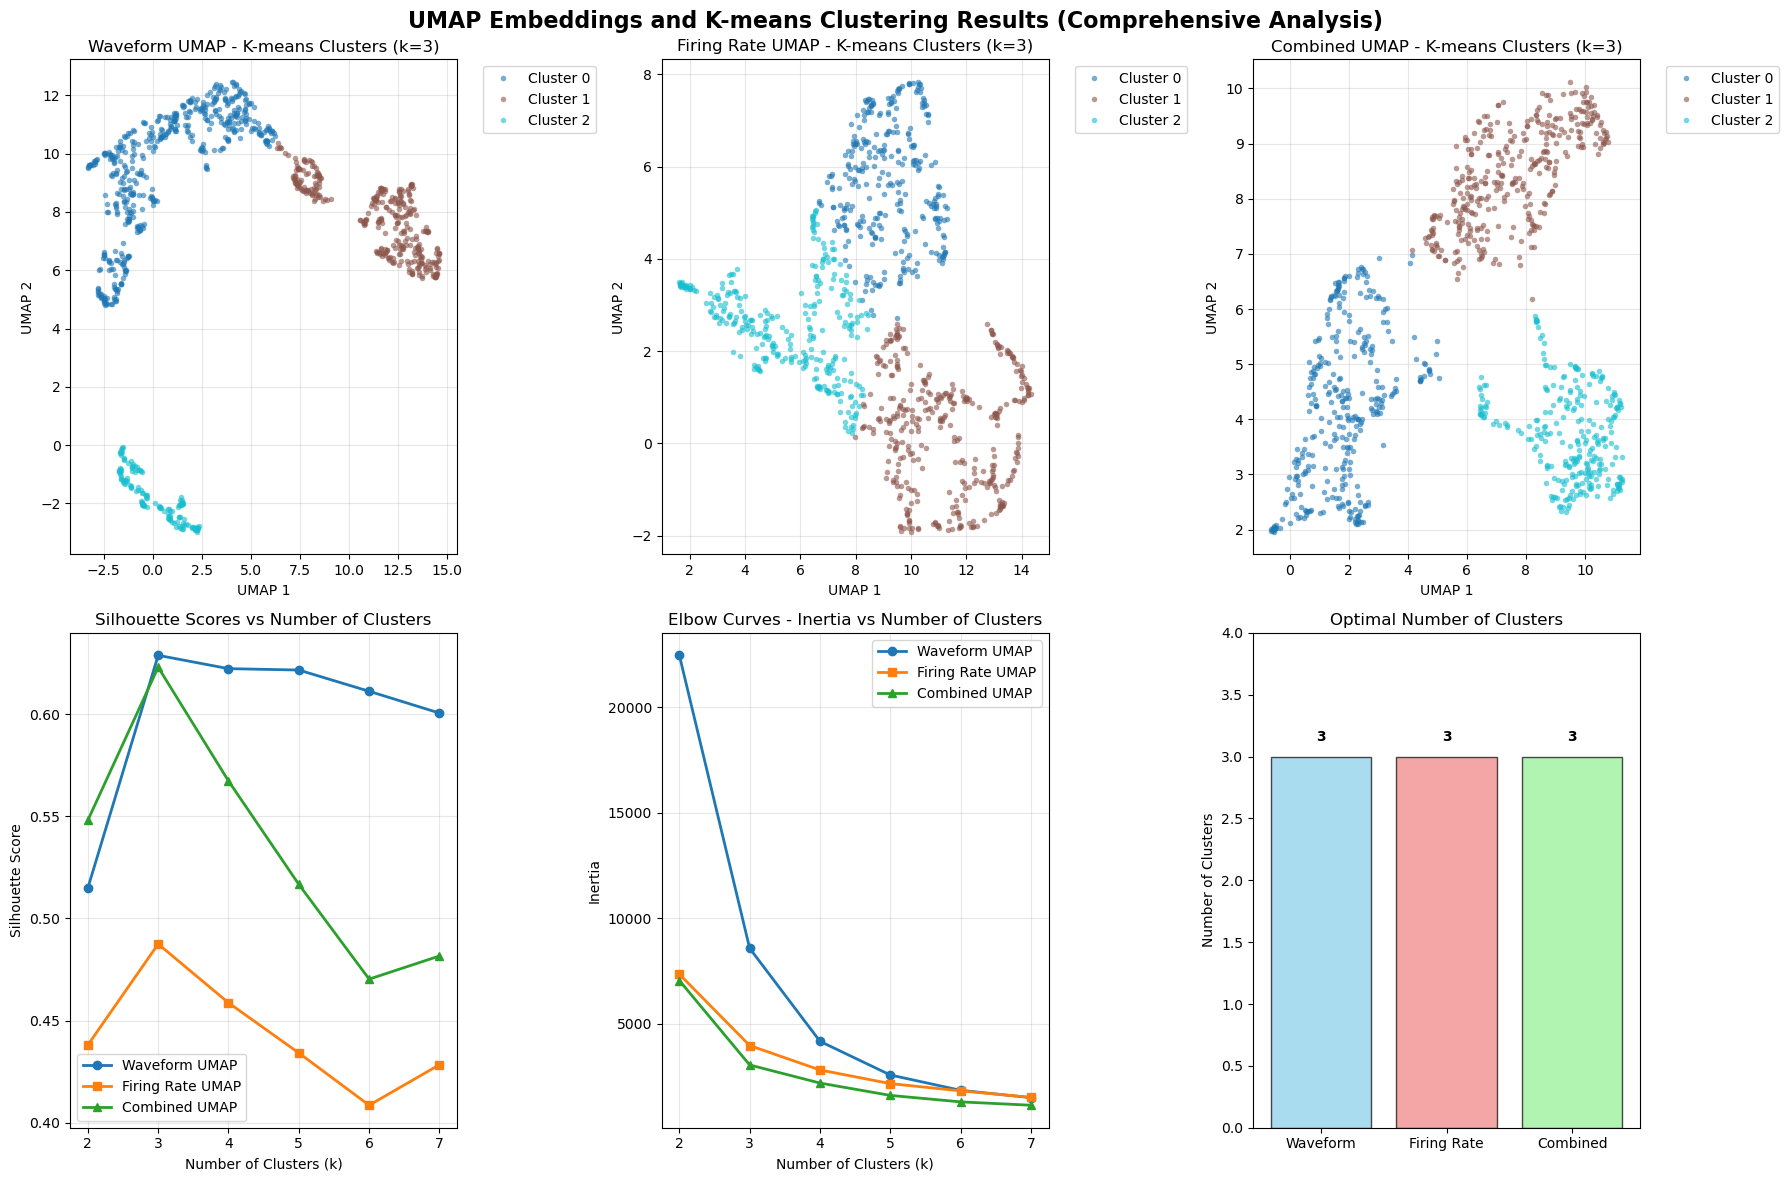


=== DETAILED CLUSTER ANALYSIS ===

Waveform UMAP Cluster Analysis:
  Cluster 0 (n=494):
    Waveform Metrics:
      Spike Width: 0.490 ± 0.213 ms
      Spike Amplitude: -57.506 ± 36.153
      Spike Asymmetry: 0.339 ± 0.153
      Rise Time: 0.265 ± 0.121 ms
      Decay Time: 0.993 ± 0.302 ms
    Firing Rate Metrics:
      Firing Rate: 4.04 ± 5.57 Hz
      Burst Index: 0.240 ± 0.295
      ISI CV: 2.547 ± 1.729
      ISI Violation Rate: 0.004 ± 0.004
      Spike Frequency Adaptation: -0.121 ± 0.794
  Cluster 1 (n=338):
    Waveform Metrics:
      Spike Width: 0.569 ± 0.300 ms
      Spike Amplitude: 29.144 ± 59.638
      Spike Asymmetry: 2.470 ± 1.691
      Rise Time: 0.373 ± 0.185 ms
      Decay Time: 0.359 ± 0.285 ms
    Firing Rate Metrics:
      Firing Rate: 5.58 ± 6.84 Hz
      Burst Index: 0.220 ± 0.325
      ISI CV: 2.877 ± 2.312
      ISI Violation Rate: 0.004 ± 0.004
      Spike Frequency Adaptation: -0.168 ± 0.732
  Cluster 2 (n=139):
    Waveform Metrics:
      Spike Width: 0.1

In [11]:
# VISUALIZE UMAP CLUSTERS FOR ALL METHODS WITH COLOR KEYS
print("\n=== UMAP CLUSTER VISUALIZATIONS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

# Create figure with subplots for all UMAP embeddings and clustering results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('UMAP Embeddings and K-means Clustering Results (Comprehensive Analysis)', fontsize=16, fontweight='bold')

# Plot 1: Waveform UMAP with clustering
ax1 = axes[0, 0]
# Use plot instead of scatter for cleaner dots without outlines
for cluster_id in range(optimal_k_waveform_comp):
    mask = waveform_comp_labels == cluster_id
    ax1.plot(waveform_comprehensive_umap[mask, 0], waveform_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_waveform_comp - 1)),
             label=f'Cluster {cluster_id}')
ax1.set_title(f'Waveform UMAP - K-means Clusters (k={optimal_k_waveform_comp})')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Firing Rate UMAP with clustering
ax2 = axes[0, 1]
for cluster_id in range(optimal_k_firing_rate_comp):
    mask = firing_rate_comp_labels == cluster_id
    ax2.plot(firing_rate_comprehensive_umap[mask, 0], firing_rate_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_firing_rate_comp - 1)),
             label=f'Cluster {cluster_id}')
ax2.set_title(f'Firing Rate UMAP - K-means Clusters (k={optimal_k_firing_rate_comp})')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.grid(True, alpha=0.3)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: Combined UMAP with clustering
ax3 = axes[0, 2]
for cluster_id in range(optimal_k_combined_comp):
    mask = combined_comp_labels == cluster_id
    ax3.plot(combined_comprehensive_umap[mask, 0], combined_comprehensive_umap[mask, 1], 
             'o', alpha=0.6, markersize=4, markeredgewidth=0, markeredgecolor='none',
             color=plt.cm.tab10(cluster_id / max(1, optimal_k_combined_comp - 1)),
             label=f'Cluster {cluster_id}')
ax3.set_title(f'Combined UMAP - K-means Clusters (k={optimal_k_combined_comp})')
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')
ax3.grid(True, alpha=0.3)
ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 4: Silhouette scores comparison
ax4 = axes[1, 0]
ax4.plot(k_range, silhouette_scores_waveform_comp, 'o-', label='Waveform UMAP', linewidth=2, markersize=6)
ax4.plot(k_range, silhouette_scores_firing_rate_comp, 's-', label='Firing Rate UMAP', linewidth=2, markersize=6)
ax4.plot(k_range, silhouette_scores_combined_comp, '^-', label='Combined UMAP', linewidth=2, markersize=6)
ax4.set_title('Silhouette Scores vs Number of Clusters')
ax4.set_xlabel('Number of Clusters (k)')
ax4.set_ylabel('Silhouette Score')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Plot 5: Elbow curves comparison
ax5 = axes[1, 1]
ax5.plot(k_range, inertias_waveform_comp, 'o-', label='Waveform UMAP', linewidth=2, markersize=6)
ax5.plot(k_range, inertias_firing_rate_comp, 's-', label='Firing Rate UMAP', linewidth=2, markersize=6)
ax5.plot(k_range, inertias_combined_comp, '^-', label='Combined UMAP', linewidth=2, markersize=6)
ax5.set_title('Elbow Curves - Inertia vs Number of Clusters')
ax5.set_xlabel('Number of Clusters (k)')
ax5.set_ylabel('Inertia')
ax5.legend()
ax5.grid(True, alpha=0.3)

# Plot 6: Cluster size comparison
ax6 = axes[1, 2]
cluster_counts = [optimal_k_waveform_comp, optimal_k_firing_rate_comp, optimal_k_combined_comp]
methods = ['Waveform', 'Firing Rate', 'Combined']
colors = ['skyblue', 'lightcoral', 'lightgreen']

bars = ax6.bar(methods, cluster_counts, color=colors, alpha=0.7, edgecolor='black')
ax6.set_title('Optimal Number of Clusters')
ax6.set_ylabel('Number of Clusters')
ax6.set_ylim(0, max(cluster_counts) + 1)

# Add value labels on bars
for bar, count in zip(bars, cluster_counts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("cluster_results.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Additional detailed cluster analysis
print("\n=== DETAILED CLUSTER ANALYSIS ===")

def analyze_cluster_characteristics_comprehensive(labels, data_name, n_clusters, waveform_data, firing_rate_data):
    """Analyze characteristics of each cluster"""
    print(f"\n{data_name} Cluster Analysis:")
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_size = np.sum(cluster_mask)
        
        if cluster_size > 0:
            # Analyze waveform characteristics for this cluster
            cluster_waveform_metrics = comprehensive_waveform_array[cluster_mask]
            cluster_firing_rate_metrics = comprehensive_firing_rate_array[cluster_mask]
            
            print(f"  Cluster {cluster_id} (n={cluster_size}):")
            
            # Waveform characteristics
            print(f"    Waveform Metrics:")
            print(f"      Spike Width: {np.mean(cluster_waveform_metrics[:, 0]):.3f} ± {np.std(cluster_waveform_metrics[:, 0]):.3f} ms")
            print(f"      Spike Amplitude: {np.mean(cluster_waveform_metrics[:, 1]):.3f} ± {np.std(cluster_waveform_metrics[:, 1]):.3f}")
            print(f"      Spike Asymmetry: {np.mean(cluster_waveform_metrics[:, 2]):.3f} ± {np.std(cluster_waveform_metrics[:, 2]):.3f}")
            print(f"      Rise Time: {np.mean(cluster_waveform_metrics[:, 3]):.3f} ± {np.std(cluster_waveform_metrics[:, 3]):.3f} ms")
            print(f"      Decay Time: {np.mean(cluster_waveform_metrics[:, 4]):.3f} ± {np.std(cluster_waveform_metrics[:, 4]):.3f} ms")
            
            # Firing rate characteristics
            print(f"    Firing Rate Metrics:")
            print(f"      Firing Rate: {np.mean(cluster_firing_rate_metrics[:, 0]):.2f} ± {np.std(cluster_firing_rate_metrics[:, 0]):.2f} Hz")
            print(f"      Burst Index: {np.mean(cluster_firing_rate_metrics[:, 1]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 1]):.3f}")
            print(f"      ISI CV: {np.mean(cluster_firing_rate_metrics[:, 2]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 2]):.3f}")
            print(f"      ISI Violation Rate: {np.mean(cluster_firing_rate_metrics[:, 3]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 3]):.3f}")
            print(f"      Spike Frequency Adaptation: {np.mean(cluster_firing_rate_metrics[:, 4]):.3f} ± {np.std(cluster_firing_rate_metrics[:, 4]):.3f}")

# Analyze each clustering method
analyze_cluster_characteristics_comprehensive(waveform_comp_labels, "Waveform UMAP", optimal_k_waveform_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)
analyze_cluster_characteristics_comprehensive(firing_rate_comp_labels, "Firing Rate UMAP", optimal_k_firing_rate_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)
analyze_cluster_characteristics_comprehensive(combined_comp_labels, "Combined UMAP", optimal_k_combined_comp, 
                                            comprehensive_waveform_array, comprehensive_firing_rate_array)

print("\nUMAP cluster visualizations complete!")


=== VARIABLE ANALYSIS BY CLUSTER ===

Spike Width (ms):
  Cluster 0: mean = 0.749 ± 0.192 (n=340)
  Cluster 1: mean = 0.246 ± 0.114 (n=356)
  Cluster 2: mean = 0.416 ± 0.182 (n=275)
  Cluster 0 vs 1: T-test p = 0.0000, Mann-Whitney p = 0.0000

Spike Amplitude:
  Cluster 0: mean = -46.684 ± 22.232 (n=340)
  Cluster 1: mean = -64.005 ± 29.746 (n=356)
  Cluster 2: mean = 41.458 ± 67.581 (n=275)
  Cluster 0 vs 1: T-test p = 0.0000, Mann-Whitney p = 0.0000

Spike Asymmetry:
  Cluster 0: mean = 0.359 ± 0.227 (n=340)
  Cluster 1: mean = 0.339 ± 0.157 (n=356)
  Cluster 2: mean = 2.955 ± 1.488 (n=275)
  Cluster 0 vs 1: T-test p = 0.1856, Mann-Whitney p = 0.0219

Rise Time (ms):
  Cluster 0: mean = 0.419 ± 0.132 (n=340)
  Cluster 1: mean = 0.242 ± 0.162 (n=356)
  Cluster 2: mean = 0.296 ± 0.147 (n=275)
  Cluster 0 vs 1: T-test p = 0.0000, Mann-Whitney p = 0.0000

Decay Time (ms):
  Cluster 0: mean = 0.982 ± 0.212 (n=340)
  Cluster 1: mean = 0.607 ± 0.525 (n=356)
  Cluster 2: mean = 0.247 ± 0.23

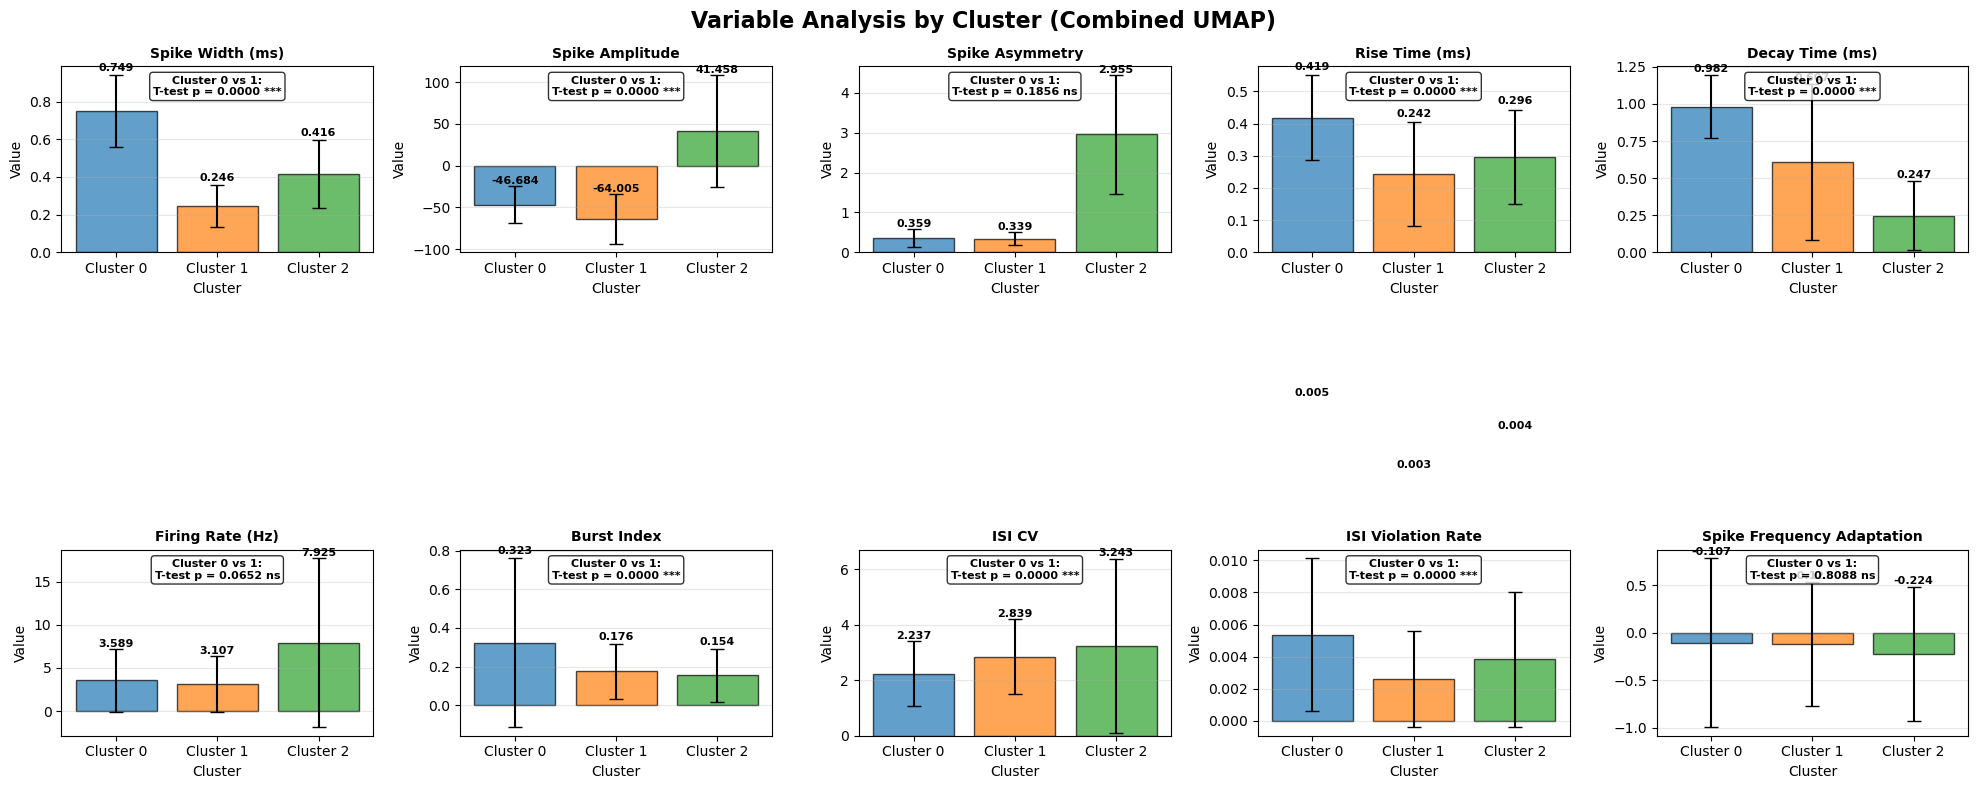


=== SUMMARY STATISTICS TABLE ===
Variable			Cluster 0		Cluster 1		Cluster 2
--------------------------------------------------------------------------------
Spike Width (ms)         	0.749 ± 0.192		0.246 ± 0.114		0.416 ± 0.182
Spike Amplitude          	-46.684 ± 22.232		-64.005 ± 29.746		41.458 ± 67.581
Spike Asymmetry          	0.359 ± 0.227		0.339 ± 0.157		2.955 ± 1.488
Rise Time (ms)           	0.419 ± 0.132		0.242 ± 0.162		0.296 ± 0.147
Decay Time (ms)          	0.982 ± 0.212		0.607 ± 0.525		0.247 ± 0.231
Firing Rate (Hz)         	3.589 ± 3.648		3.107 ± 3.226		7.925 ± 9.813
Burst Index              	0.323 ± 0.438		0.176 ± 0.143		0.154 ± 0.138
ISI CV                   	2.237 ± 1.159		2.839 ± 1.350		3.243 ± 3.134
ISI Violation Rate       	0.005 ± 0.005		0.003 ± 0.003		0.004 ± 0.004
Spike Frequency Adaptation	-0.107 ± 0.888		-0.121 ± 0.655		-0.224 ± 0.705

=== STATISTICAL SIGNIFICANCE SUMMARY (Cluster 0 vs 1) ===
Variable			T-test p-value		Mann-Whitney p-value
-----------------------

In [12]:
# BAR PLOTS FOR ALL VARIABLES BY CLUSTER WITH STATISTICAL TESTS
print("\n=== VARIABLE ANALYSIS BY CLUSTER ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu

# Define variable names
waveform_vars = ['Spike Width (ms)', 'Spike Amplitude', 'Spike Asymmetry', 'Rise Time (ms)', 'Decay Time (ms)']
firing_rate_vars = ['Firing Rate (Hz)', 'Burst Index', 'ISI CV', 'ISI Violation Rate', 'Spike Frequency Adaptation']
all_vars = waveform_vars + firing_rate_vars

# Get the data arrays
waveform_data = comprehensive_waveform_array  # Shape: (n_neurons, 5)
firing_rate_data = comprehensive_firing_rate_array  # Shape: (n_neurons, 5)
combined_data = np.hstack([waveform_data, firing_rate_data])  # Shape: (n_neurons, 10)

# Get cluster labels
cluster_labels = combined_comp_labels

# Create figure with subplots for all variables
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Variable Analysis by Cluster (Combined UMAP)', fontsize=16, fontweight='bold')

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Function to perform statistical tests
def perform_statistical_tests(data_cluster0, data_cluster1, test_name):
    """Perform t-test and Mann-Whitney U test"""
    if len(data_cluster0) == 0 or len(data_cluster1) == 0:
        return None, None
    
    # T-test
    t_stat, t_p = ttest_ind(data_cluster0, data_cluster1)
    
    # Mann-Whitney U test
    u_stat, u_p = mannwhitneyu(data_cluster0, data_cluster1, alternative='two-sided')
    
    return {'t_test': (t_stat, t_p), 'mannwhitney': (u_stat, u_p)}

# Plot each variable
for var_idx in range(10):
    ax = axes_flat[var_idx]
    
    # Get data for this variable
    var_data = combined_data[:, var_idx]
    
    # Calculate means and standard errors for each cluster
    cluster_means = []
    cluster_stds = []
    cluster_sizes = []
    cluster_data = []
    
    for cluster_id in range(3):  # Assuming 3 clusters
        cluster_mask = cluster_labels == cluster_id
        cluster_var_data = var_data[cluster_mask]
        
        if len(cluster_var_data) > 0:
            cluster_means.append(np.mean(cluster_var_data))
            cluster_stds.append(np.std(cluster_var_data))
            cluster_sizes.append(len(cluster_var_data))
            cluster_data.append(cluster_var_data)
        else:
            cluster_means.append(0)
            cluster_stds.append(0)
            cluster_sizes.append(0)
            cluster_data.append(np.array([]))
    
    # Create bar plot
    x_pos = np.arange(3)
    bars = ax.bar(x_pos, cluster_means, yerr=cluster_stds, capsize=5, 
                  color=['#1f77b4', '#ff7f0e', '#2ca02c'], alpha=0.7, edgecolor='black')
    
    # Add value labels on bars
    for i, (bar, mean, std, size) in enumerate(zip(bars, cluster_means, cluster_stds, cluster_sizes)):
        if size > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01, 
                   f'{mean:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=8)
    
    # Perform statistical tests between cluster 0 and cluster 1
    if len(cluster_data[0]) > 0 and len(cluster_data[1]) > 0:
        stats_results = perform_statistical_tests(cluster_data[0], cluster_data[1], all_vars[var_idx])
        
        if stats_results:
            t_stat, t_p = stats_results['t_test']
            u_stat, u_p = stats_results['mannwhitney']
            
            # Add significance annotation
            significance = "***" if t_p < 0.001 else "**" if t_p < 0.01 else "*" if t_p < 0.05 else "ns"
            ax.text(0.5, 0.95, f"Cluster 0 vs 1:\nT-test p = {t_p:.4f} {significance}", 
                   transform=ax.transAxes, ha='center', va='top', fontweight='bold', fontsize=8,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    # Set plot properties
    ax.set_title(all_vars[var_idx], fontsize=10, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Value')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['Cluster 0', 'Cluster 1', 'Cluster 2'])
    ax.grid(axis='y', alpha=0.3)
    
    # Print detailed statistics
    print(f"\n{all_vars[var_idx]}:")
    for cluster_id in range(3):
        if cluster_sizes[cluster_id] > 0:
            print(f"  Cluster {cluster_id}: mean = {cluster_means[cluster_id]:.3f} ± {cluster_stds[cluster_id]:.3f} (n={cluster_sizes[cluster_id]})")
    
    # Print statistical test results
    if len(cluster_data[0]) > 0 and len(cluster_data[1]) > 0:
        print(f"  Cluster 0 vs 1: T-test p = {t_p:.4f}, Mann-Whitney p = {u_p:.4f}")

plt.tight_layout()
plt.savefig("summary_stats_clusters.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics table
print("\n=== SUMMARY STATISTICS TABLE ===")
print("Variable\t\t\tCluster 0\t\tCluster 1\t\tCluster 2")
print("-" * 80)

for var_idx in range(10):
    var_name = all_vars[var_idx]
    # Pad variable name to align columns
    padded_name = var_name.ljust(25)
    
    # Get cluster data
    cluster_data = []
    for cluster_id in range(3):
        cluster_mask = cluster_labels == cluster_id
        cluster_var_data = combined_data[cluster_mask, var_idx]
        cluster_data.append(cluster_var_data)
    
    # Format means and standard deviations
    cluster_stats = []
    for cluster_id in range(3):
        if len(cluster_data[cluster_id]) > 0:
            mean_val = np.mean(cluster_data[cluster_id])
            std_val = np.std(cluster_data[cluster_id])
            cluster_stats.append(f"{mean_val:.3f} ± {std_val:.3f}")
        else:
            cluster_stats.append("N/A")
    
    print(f"{padded_name}\t{cluster_stats[0]}\t\t{cluster_stats[1]}\t\t{cluster_stats[2]}")

# Statistical significance summary
print("\n=== STATISTICAL SIGNIFICANCE SUMMARY (Cluster 0 vs 1) ===")
print("Variable\t\t\tT-test p-value\t\tMann-Whitney p-value")
print("-" * 70)

for var_idx in range(10):
    var_name = all_vars[var_idx]
    padded_name = var_name.ljust(25)
    
    # Get cluster data
    cluster_mask_0 = cluster_labels == 0
    cluster_mask_1 = cluster_labels == 1
    cluster_data_0 = combined_data[cluster_mask_0, var_idx]
    cluster_data_1 = combined_data[cluster_mask_1, var_idx]
    
    if len(cluster_data_0) > 0 and len(cluster_data_1) > 0:
        # T-test
        t_stat, t_p = ttest_ind(cluster_data_0, cluster_data_1)
        
        # Mann-Whitney U test
        u_stat, u_p = mannwhitneyu(cluster_data_0, cluster_data_1, alternative='two-sided')
        
        print(f"{padded_name}\t{t_p:.4f}\t\t\t{u_p:.4f}")
    else:
        print(f"{padded_name}\tN/A\t\t\tN/A")

print("\nVariable analysis complete!")

In [14]:
# COMPREHENSIVE VISUALIZATION FUNCTIONS
print("\n=== COMPREHENSIVE VISUALIZATION FUNCTIONS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

def plot_cluster_waveforms_comprehensive(labels, waveforms_array, title_prefix, n_clusters, method_name):
    """Plot average waveforms for each cluster"""
    fig, axes = plt.subplots(1, n_clusters, figsize=(4*n_clusters, 4))
    if n_clusters == 1:
        axes = [axes]
    
    fig.suptitle(f'{title_prefix} - Average Waveforms ({method_name})', fontsize=14, fontweight='bold')
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_waveforms = waveforms_array[cluster_mask]
        
        if len(cluster_waveforms) > 0:
            # Calculate average waveform
            avg_waveform = np.mean(cluster_waveforms, axis=0)
            std_waveform = np.std(cluster_waveforms, axis=0)
            
            # Plot average waveform with error bars
            x_vals = np.arange(len(avg_waveform)) / 30.0  # Convert to ms
            axes[cluster_id].plot(x_vals, avg_waveform, 'b-', linewidth=2, label=f'Cluster {cluster_id}')
            axes[cluster_id].fill_between(x_vals, 
                                        avg_waveform - std_waveform, 
                                        avg_waveform + std_waveform, 
                                        alpha=0.3, color='blue')
            
            axes[cluster_id].set_title(f'Cluster {cluster_id} (n={len(cluster_waveforms)})')
            axes[cluster_id].set_xlabel('Time (ms)')
            axes[cluster_id].set_ylabel('Amplitude')
            axes[cluster_id].grid(True, alpha=0.3)
            axes[cluster_id].legend()
    
    plt.tight_layout()
    plt.savefig("cluster_waveforms.svg", format="svg", dpi=300, bbox_inches='tight')
    plt.show()

def plot_region_pie_charts(labels, metadata, title_prefix, n_clusters, method_name):
    """Plot pie charts showing regional distribution for each cluster"""
    fig, axes = plt.subplots(1, n_clusters, figsize=(5*n_clusters, 4))
    if n_clusters == 1:
        axes = [axes]
    
    fig.suptitle(f'{title_prefix} - Regional Distribution ({method_name})', fontsize=14, fontweight='bold')
    
    # Get unique regions
    all_regions = [meta['region'] for meta in metadata]
    unique_regions = list(set(all_regions))
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_metadata = [metadata[i] for i in range(len(metadata)) if cluster_mask[i]]
        
        if len(cluster_metadata) > 0:
            # Count regions in this cluster
            cluster_regions = [meta['region'] for meta in cluster_metadata]
            region_counts = {region: cluster_regions.count(region) for region in unique_regions}
            
            # Create pie chart
            labels_pie = list(region_counts.keys())
            sizes = list(region_counts.values())
            colors = plt.cm.Set3(np.linspace(0, 1, len(labels_pie)))
            
            axes[cluster_id].pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors)
            axes[cluster_id].set_title(f'Cluster {cluster_id} (n={len(cluster_metadata)})')
    
    plt.tight_layout()
    plt.savefig("cluster_region.svg", format="svg", dpi=300, bbox_inches='tight')
    plt.show()

def plot_depth_histograms(labels, metadata, title_prefix, n_clusters, method_name):
    """Plot depth histograms for each cluster"""
    fig, axes = plt.subplots(1, n_clusters, figsize=(5*n_clusters, 4))
    if n_clusters == 1:
        axes = [axes]
    
    fig.suptitle(f'{title_prefix} - Depth Distribution ({method_name})', fontsize=14, fontweight='bold')
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_depths = [metadata[i]['depth'] for i in range(len(metadata)) if cluster_mask[i]]
        
        if len(cluster_depths) > 0:
            axes[cluster_id].hist(cluster_depths, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
            axes[cluster_id].set_title(f'Cluster {cluster_id} (n={len(cluster_depths)})')
            axes[cluster_id].set_xlabel('Depth')
            axes[cluster_id].set_ylabel('Count')
            axes[cluster_id].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_subgroup_bar_charts(labels, metadata, title_prefix, n_clusters, method_name):
    """Plot bar charts showing subgroup proportions for each cluster"""
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(f'{title_prefix} - Subgroup Proportions ({method_name})', fontsize=14, fontweight='bold')
    
    # Subplot 1: Pathology (oli+ast vs gbm)
    ax1 = axes[0]
    pathology_data = []
    cluster_labels = []
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_metadata = [metadata[i] for i in range(len(metadata)) if cluster_mask[i]]
        
        if len(cluster_metadata) > 0:
            # Count pathology types
            oli_ast_count = sum(1 for meta in cluster_metadata if meta['pathology'] in ['oli', 'ast'])
            gbm_count = sum(1 for meta in cluster_metadata if meta['pathology'] == 'gbm')
            total = len(cluster_metadata)
            
            # Calculate proportions
            oli_ast_prop = oli_ast_count / total if total > 0 else 0
            gbm_prop = gbm_count / total if total > 0 else 0
            
            pathology_data.append([oli_ast_prop, gbm_prop])
            cluster_labels.append(f'Cluster {cluster_id}')
    
    pathology_data = np.array(pathology_data)
    x = np.arange(len(cluster_labels))
    width = 0.35
    
    ax1.bar(x - width/2, pathology_data[:, 0], width, label='Oli + Ast', color='lightblue', alpha=0.8)
    ax1.bar(x + width/2, pathology_data[:, 1], width, label='GBM', color='lightcoral', alpha=0.8)
    
    ax1.set_xlabel('Cluster')
    ax1.set_ylabel('Proportion')
    ax1.set_title('Pathology Distribution (Oli+Ast vs GBM)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(cluster_labels)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Subplot 2: Grade (2+3 vs 4)
    ax2 = axes[1]
    grade_data = []
    
    for cluster_id in range(n_clusters):
        cluster_mask = labels == cluster_id
        cluster_metadata = [metadata[i] for i in range(len(metadata)) if cluster_mask[i]]
        
        if len(cluster_metadata) > 0:
            # Count grades
            grade_2_3_count = sum(1 for meta in cluster_metadata if meta['grade'] in [2, 3])
            grade_4_count = sum(1 for meta in cluster_metadata if meta['grade'] == 4)
            total = len(cluster_metadata)
            
            # Calculate proportions
            grade_2_3_prop = grade_2_3_count / total if total > 0 else 0
            grade_4_prop = grade_4_count / total if total > 0 else 0
            
            grade_data.append([grade_2_3_prop, grade_4_prop])
    
    grade_data = np.array(grade_data)
    
    ax2.bar(x - width/2, grade_data[:, 0], width, label='Grade 2+3', color='lightgreen', alpha=0.8)
    ax2.bar(x + width/2, grade_data[:, 1], width, label='Grade 4', color='orange', alpha=0.8)
    
    ax2.set_xlabel('Cluster')
    ax2.set_ylabel('Proportion')
    ax2.set_title('Grade Distribution (Grade 2+3 vs Grade 4)')
    ax2.set_xticks(x)
    ax2.set_xticklabels(cluster_labels)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Comprehensive visualization functions defined!")



=== COMPREHENSIVE VISUALIZATION FUNCTIONS ===
Comprehensive visualization functions defined!



=== COMPREHENSIVE VISUALIZATIONS: UMAP + K-MEANS ===

--- Combined UMAP + K-means Clustering ---


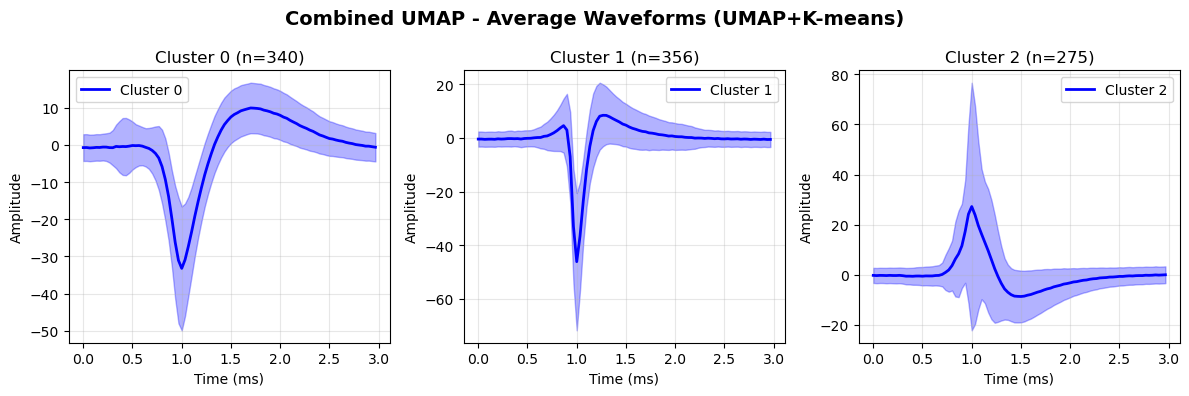

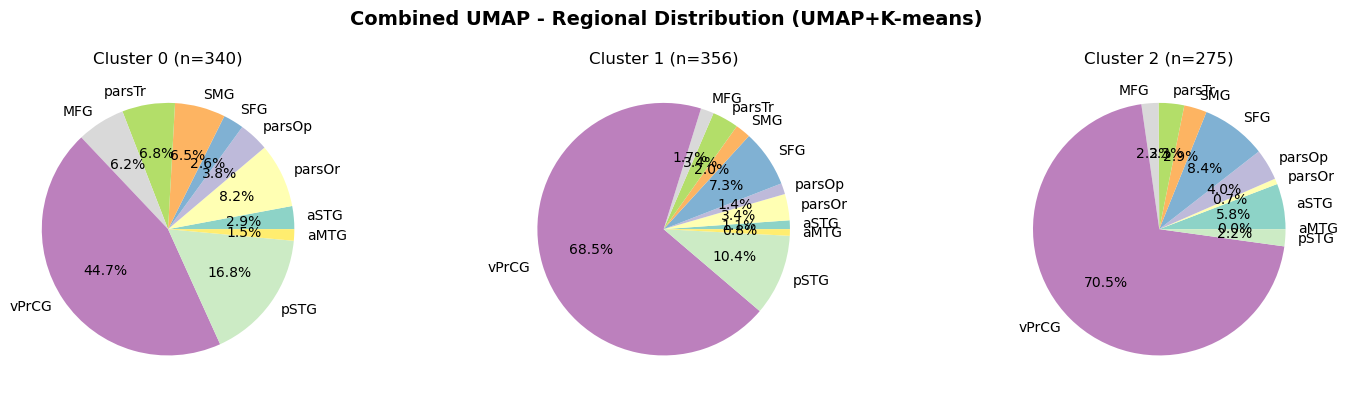

UMAP + K-means visualizations complete!


In [15]:
# COMPREHENSIVE VISUALIZATIONS FOR UMAP + K-MEANS CLUSTERING
print("\n=== COMPREHENSIVE VISUALIZATIONS: UMAP + K-MEANS ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator

# Convert waveforms_flat to numpy array for visualization
waveforms_array_for_viz = np.array(waveforms_flat)

# # 1. Waveform UMAP + K-means visualizations
# print("\n--- Waveform UMAP + K-means Clustering ---")
# plot_cluster_waveforms_comprehensive(waveform_comp_labels, waveforms_array_for_viz, 
#                                     "Waveform UMAP", optimal_k_waveform_comp, "UMAP+K-means")
# plot_region_pie_charts(waveform_comp_labels, comprehensive_metadata, 
#                       "Waveform UMAP", optimal_k_waveform_comp, "UMAP+K-means")
# plot_depth_histograms(waveform_comp_labels, comprehensive_metadata, 
#                      "Waveform UMAP", optimal_k_waveform_comp, "UMAP+K-means")
# plot_subgroup_bar_charts(waveform_comp_labels, comprehensive_metadata, 
#                         "Waveform UMAP", optimal_k_waveform_comp, "UMAP+K-means")

# # 2. Firing Rate UMAP + K-means visualizations
# print("\n--- Firing Rate UMAP + K-means Clustering ---")
# plot_cluster_waveforms_comprehensive(firing_rate_comp_labels, waveforms_array_for_viz, 
#                                     "Firing Rate UMAP", optimal_k_firing_rate_comp, "UMAP+K-means")
# plot_region_pie_charts(firing_rate_comp_labels, comprehensive_metadata, 
#                       "Firing Rate UMAP", optimal_k_firing_rate_comp, "UMAP+K-means")
# plot_depth_histograms(firing_rate_comp_labels, comprehensive_metadata, 
#                      "Firing Rate UMAP", optimal_k_firing_rate_comp, "UMAP+K-means")
# plot_subgroup_bar_charts(firing_rate_comp_labels, comprehensive_metadata, 
#                         "Firing Rate UMAP", optimal_k_firing_rate_comp, "UMAP+K-means")

# 3. Combined UMAP + K-means visualizations
print("\n--- Combined UMAP + K-means Clustering ---")
plot_cluster_waveforms_comprehensive(combined_comp_labels, waveforms_array_for_viz, 
                                    "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
plot_region_pie_charts(combined_comp_labels, comprehensive_metadata, 
                      "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
#plot_depth_histograms(combined_comp_labels, comprehensive_metadata, 
#                     "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")
#plot_subgroup_bar_charts(combined_comp_labels, comprehensive_metadata, 
#                        "Combined UMAP", optimal_k_combined_comp, "UMAP+K-means")

print("UMAP + K-means visualizations complete!")


In [16]:
# ET-DENSE vs ET-SPARSE REGIONAL ANALYSIS
print("\n=== ET-DENSE vs ET-SPARSE REGIONAL ANALYSIS ===")

# Define ET-dense and ET-sparse regions
et_dense_regions = ['vPrCG', 'PoCG']  # Motor and somatosensory cortex
et_sparse_regions = ['pSTG', 'SFG', 'aSTG', 'aMTG', 'MFG', 'parsOp', 'parsTr', 'parsOr', 'SMG']

print(f"ET-dense regions: {et_dense_regions}")
print(f"ET-sparse regions: {et_sparse_regions}")

# Create masks for ET-dense and ET-sparse regions
et_dense_mask = np.array([neuron['region'] in et_dense_regions for neuron in comprehensive_metadata])
et_sparse_mask = np.array([neuron['region'] in et_sparse_regions for neuron in comprehensive_metadata])

print(f"ET-dense neurons: {np.sum(et_dense_mask)}")
print(f"ET-sparse neurons: {np.sum(et_sparse_mask)}")

# Separate the combined clustering data
et_dense_labels = combined_comp_labels[et_dense_mask]
et_sparse_labels = combined_comp_labels[et_sparse_mask]

et_dense_metadata = [comprehensive_metadata[i] for i in range(len(comprehensive_metadata)) if et_dense_mask[i]]
et_sparse_metadata = [comprehensive_metadata[i] for i in range(len(comprehensive_metadata)) if et_sparse_mask[i]]

et_dense_waveforms = waveforms_array_for_viz[et_dense_mask]
et_sparse_waveforms = waveforms_array_for_viz[et_sparse_mask]

print(f"ET-dense data shapes:")
print(f"  Labels: {et_dense_labels.shape}")
print(f"  Metadata: {len(et_dense_metadata)}")
print(f"  Waveforms: {et_dense_waveforms.shape}")

print(f"ET-sparse data shapes:")
print(f"  Labels: {et_sparse_labels.shape}")
print(f"  Metadata: {len(et_sparse_metadata)}")
print(f"  Waveforms: {et_sparse_waveforms.shape}")

print("Data separation complete!")



=== ET-DENSE vs ET-SPARSE REGIONAL ANALYSIS ===
ET-dense regions: ['vPrCG', 'PoCG']
ET-sparse regions: ['pSTG', 'SFG', 'aSTG', 'aMTG', 'MFG', 'parsOp', 'parsTr', 'parsOr', 'SMG']
ET-dense neurons: 590
ET-sparse neurons: 381
ET-dense data shapes:
  Labels: (590,)
  Metadata: 590
  Waveforms: (590, 90)
ET-sparse data shapes:
  Labels: (381,)
  Metadata: 381
  Waveforms: (381, 90)
Data separation complete!



=== ET-DENSE REGIONS VISUALIZATION ===
Analyzing 590 neurons from ET-dense regions (vPrCG, PoCG)

--- ET-Dense: Waveform Analysis ---


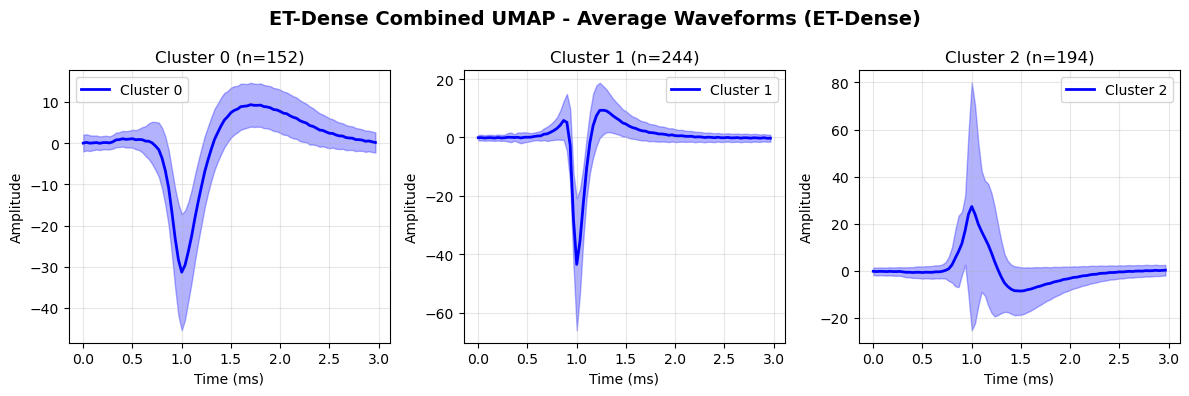


--- ET-Dense: Region Distribution ---


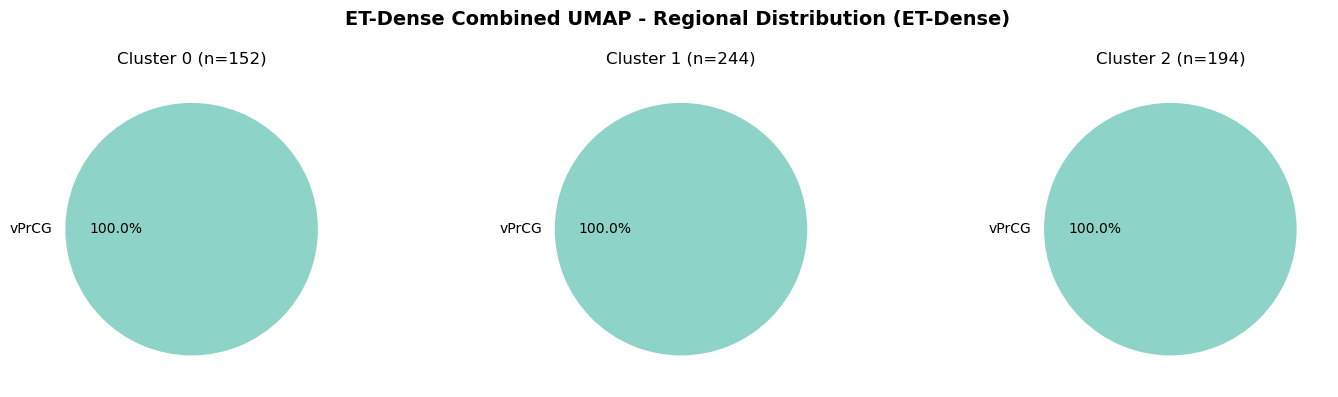

ET-Dense regions visualization complete!


In [17]:
# ET-DENSE REGIONS VISUALIZATION
print("\n=== ET-DENSE REGIONS VISUALIZATION ===")
print(f"Analyzing {len(et_dense_labels)} neurons from ET-dense regions (vPrCG, PoCG)")

# 1. Waveform visualizations for ET-dense
print("\n--- ET-Dense: Waveform Analysis ---")
plot_cluster_waveforms_comprehensive(et_dense_labels, et_dense_waveforms, 
                                    "ET-Dense Combined UMAP", optimal_k_combined_comp, "ET-Dense")

# 2. Region pie charts for ET-dense
print("\n--- ET-Dense: Region Distribution ---")
plot_region_pie_charts(et_dense_labels, et_dense_metadata, 
                      "ET-Dense Combined UMAP", optimal_k_combined_comp, "ET-Dense")

# 3. Depth histograms for ET-dense
# print("\n--- ET-Dense: Depth Analysis ---")
# plot_depth_histograms(et_dense_labels, et_dense_metadata, 
#                      "ET-Dense Combined UMAP", optimal_k_combined_comp, "ET-Dense")

# 4. Subgroup bar charts for ET-dense
# print("\n--- ET-Dense: Subgroup Analysis ---")
# plot_subgroup_bar_charts(et_dense_labels, et_dense_metadata, 
#                        "ET-Dense Combined UMAP", optimal_k_combined_comp, "ET-Dense")

print("ET-Dense regions visualization complete!")



=== ET-SPARSE REGIONS VISUALIZATION ===
Analyzing 381 neurons from ET-sparse regions (all others)

--- ET-Sparse: Waveform Analysis ---


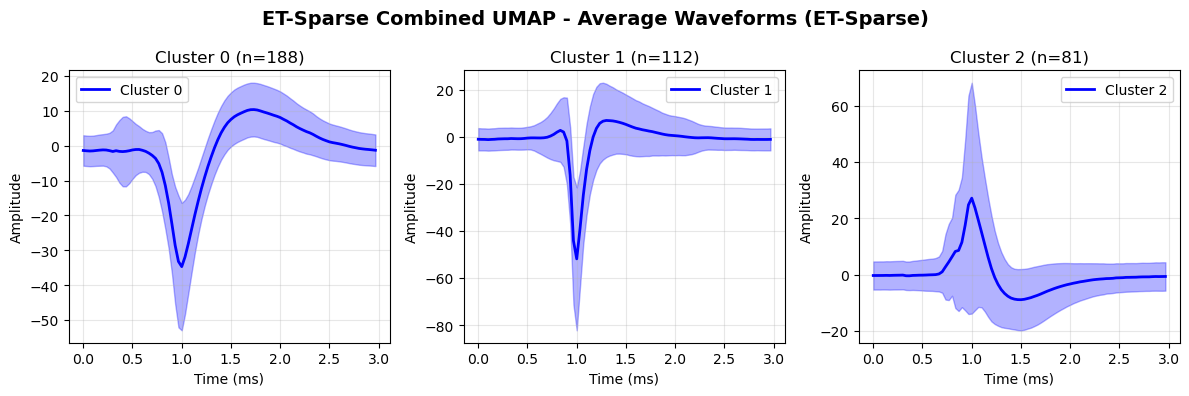


--- ET-Sparse: Region Distribution ---


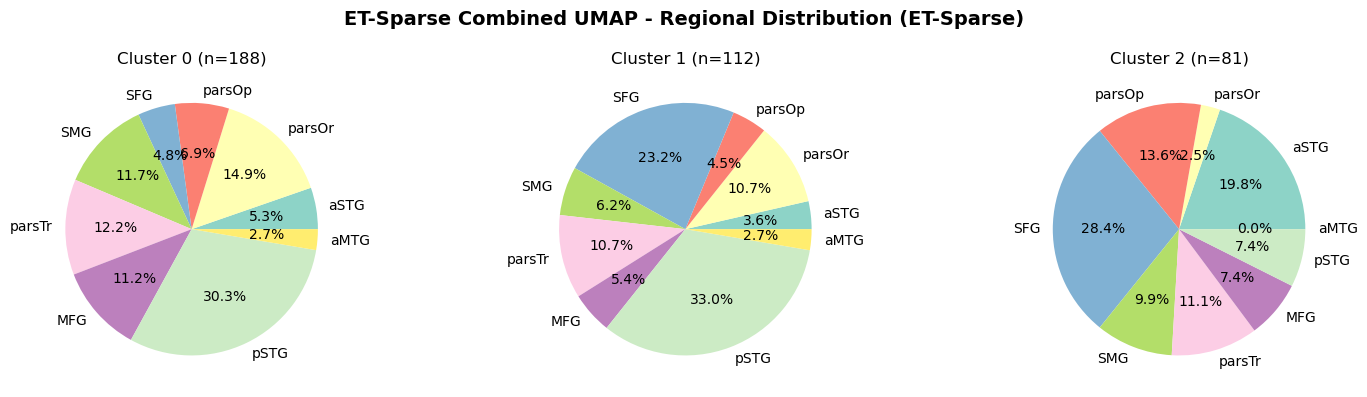

ET-Sparse regions visualization complete!


In [18]:
# ET-SPARSE REGIONS VISUALIZATION
print("\n=== ET-SPARSE REGIONS VISUALIZATION ===")
print(f"Analyzing {len(et_sparse_labels)} neurons from ET-sparse regions (all others)")

# 1. Waveform visualizations for ET-sparse
print("\n--- ET-Sparse: Waveform Analysis ---")
plot_cluster_waveforms_comprehensive(et_sparse_labels, et_sparse_waveforms, 
                                    "ET-Sparse Combined UMAP", optimal_k_combined_comp, "ET-Sparse")

# 2. Region pie charts for ET-sparse
print("\n--- ET-Sparse: Region Distribution ---")
plot_region_pie_charts(et_sparse_labels, et_sparse_metadata, 
                      "ET-Sparse Combined UMAP", optimal_k_combined_comp, "ET-Sparse")

# 3. Depth histograms for ET-sparse
# print("\n--- ET-Sparse: Depth Analysis ---")
# plot_depth_histograms(et_sparse_labels, et_sparse_metadata, 
#                      "ET-Sparse Combined UMAP", optimal_k_combined_comp, "ET-Sparse")

# 4. Subgroup bar charts for ET-sparse
# print("\n--- ET-Sparse: Subgroup Analysis ---")
# plot_subgroup_bar_charts(et_sparse_labels, et_sparse_metadata, 
#                        "ET-Sparse Combined UMAP", optimal_k_combined_comp, "ET-Sparse")

print("ET-Sparse regions visualization complete!")



=== PROPORTIONAL CLUSTER ANALYSIS: ET-DENSE vs ET-SPARSE (FIXED + PIE CHARTS) ===
ET-Dense regions analysis:
ET-Dense oli+ast proportions: [0.61971831 0.12676056 0.25352113]
ET-Dense gbm proportions: [0.20809249 0.45279383 0.33911368]
ET-Dense grade 2+3 proportions: [0.61971831 0.12676056 0.25352113]
ET-Dense grade 4 proportions: [0.20809249 0.45279383 0.33911368]

ET-Sparse regions analysis:
ET-Sparse oli+ast proportions: [0.46610169 0.30084746 0.23305085]
ET-Sparse gbm proportions: [0.53793103 0.28275862 0.17931034]
ET-Sparse grade 2+3 proportions: [0.57142857 0.24       0.18857143]
ET-Sparse grade 4 proportions: [0.42718447 0.33980583 0.23300971]


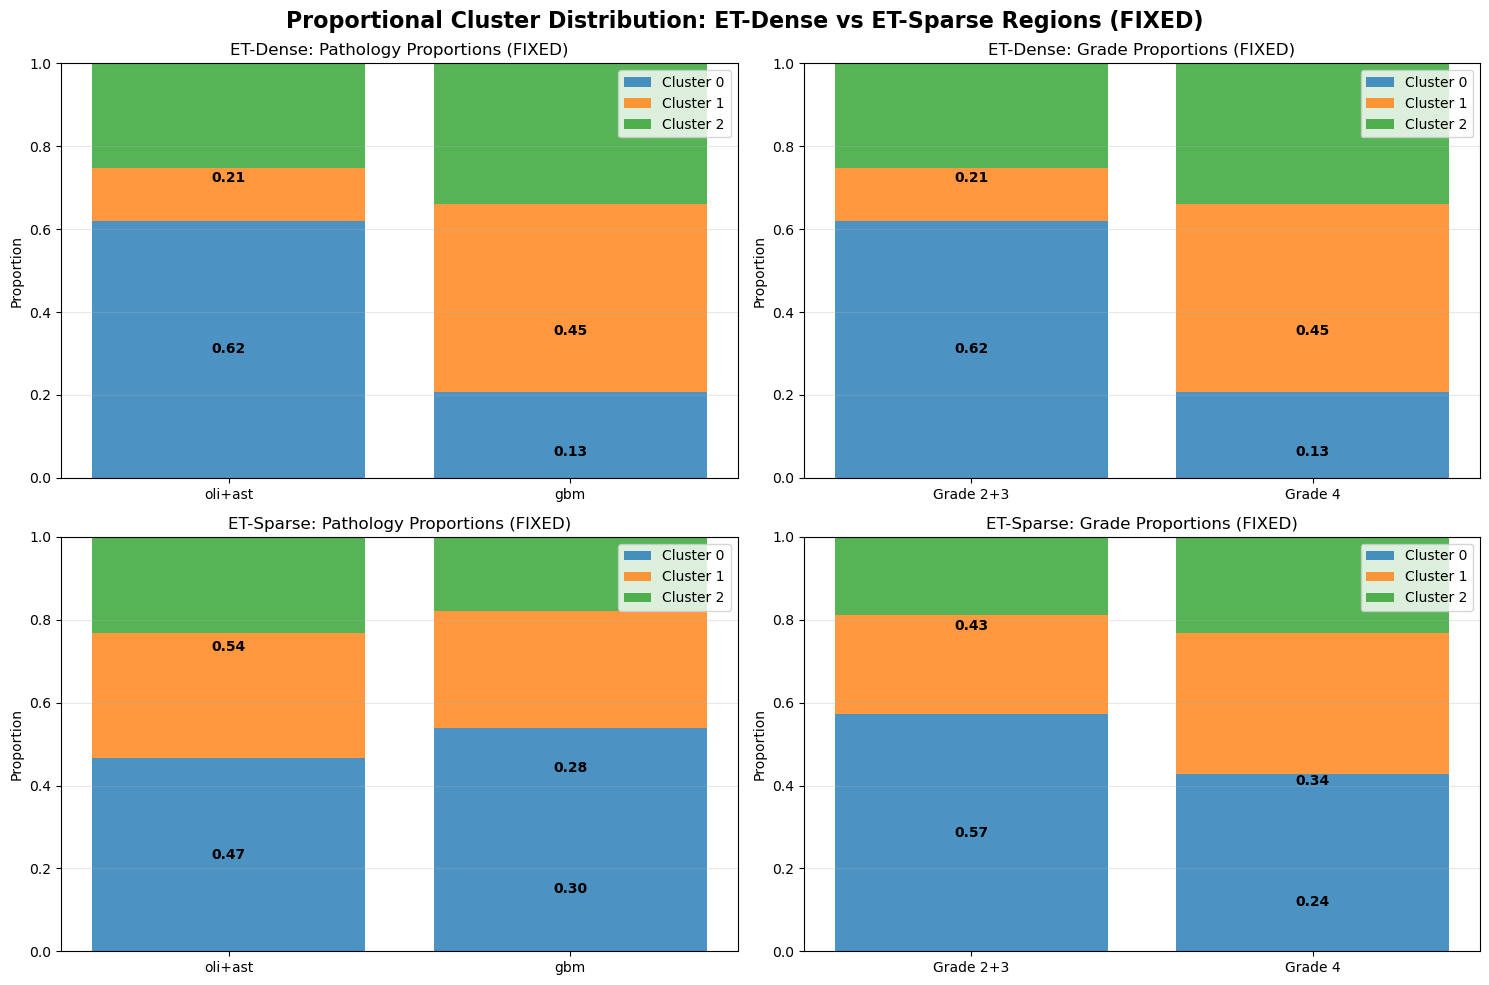


=== PIE CHARTS FOR EACH CLUSTER ===

--- ET-Dense Regions Cluster Distributions ---


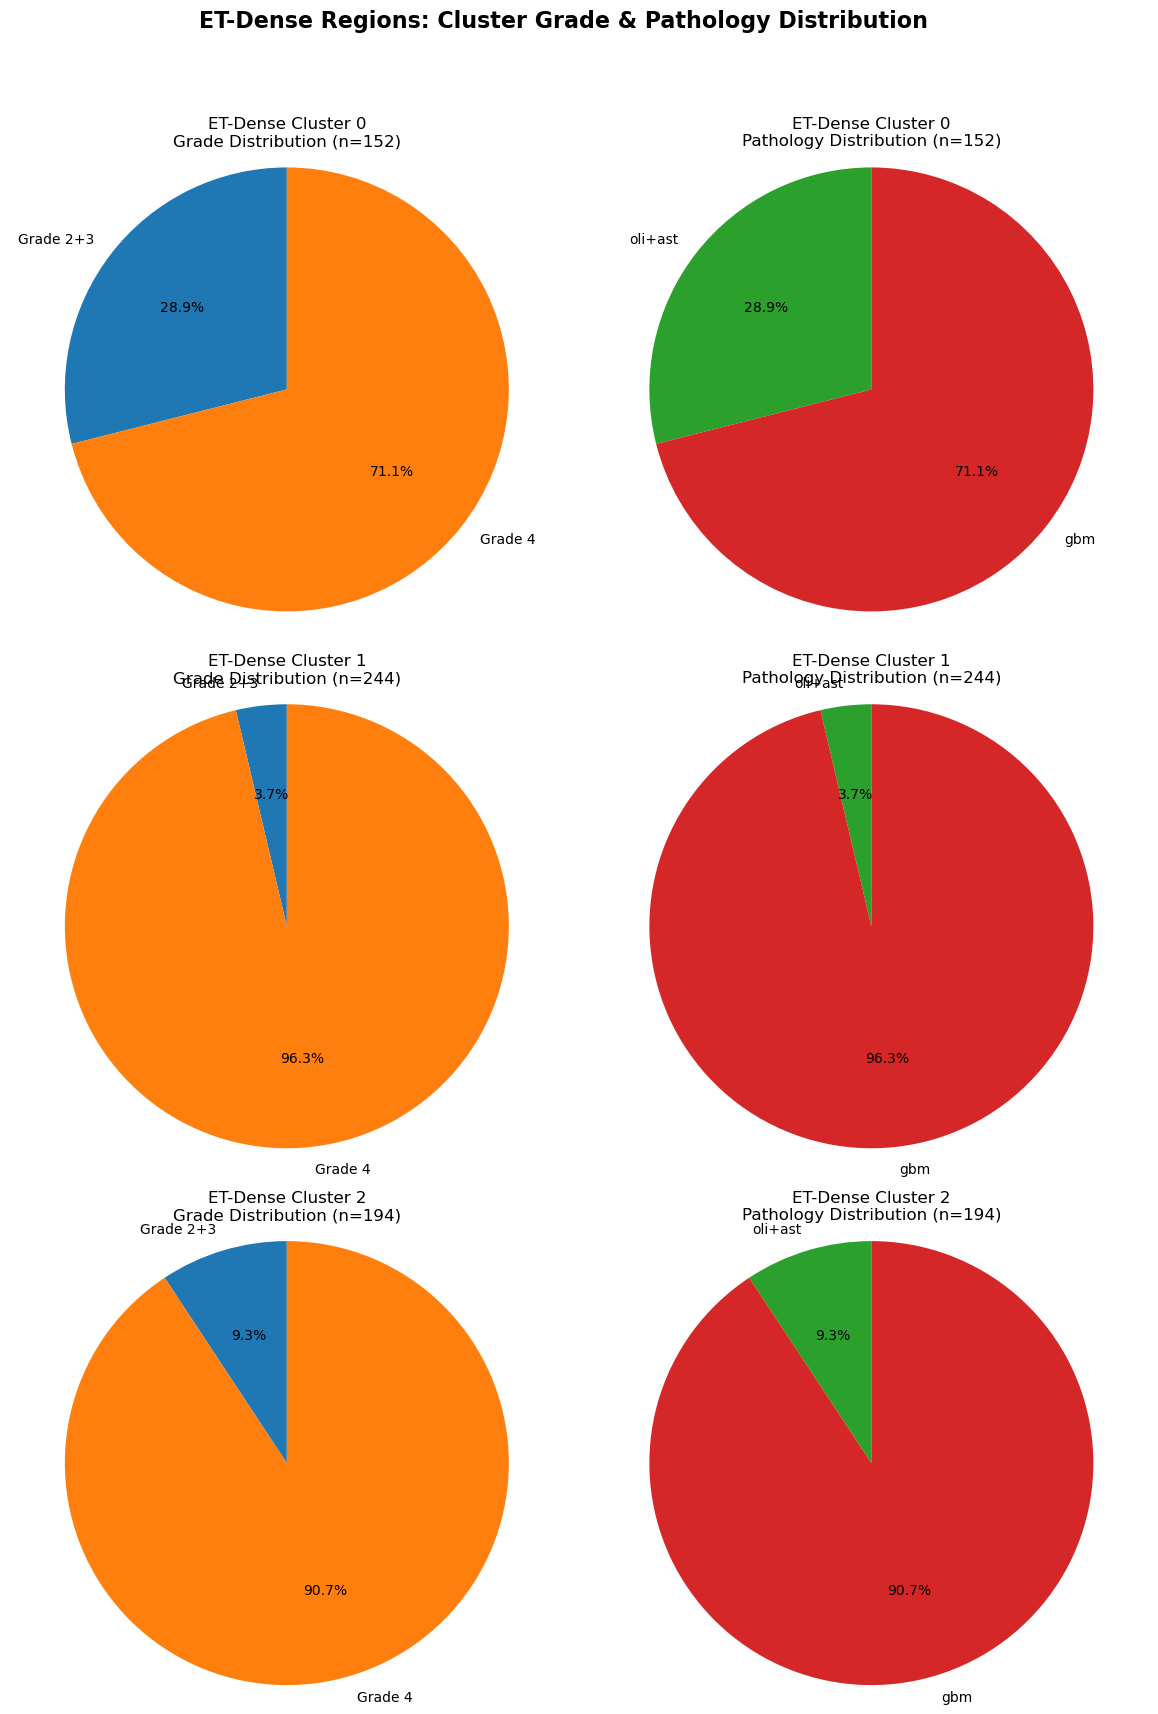


--- ET-Sparse Regions Cluster Distributions ---


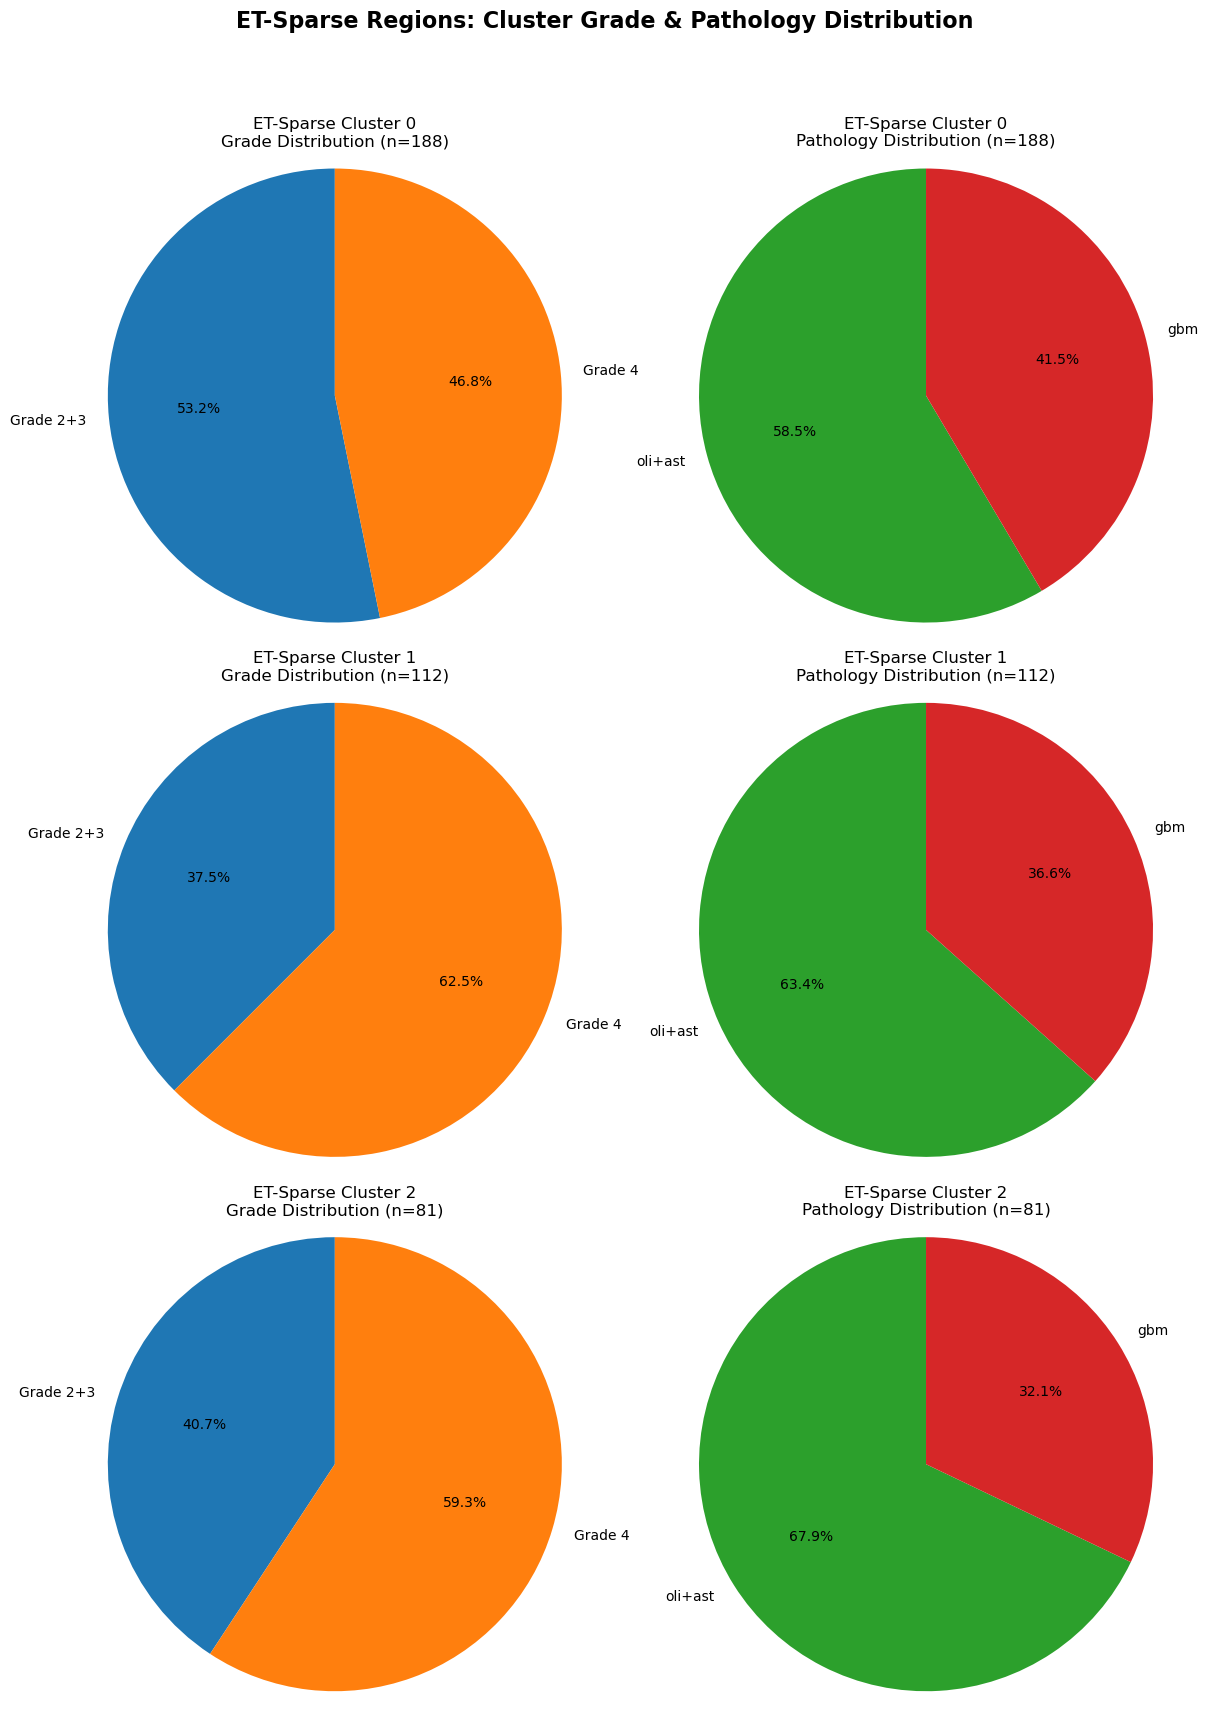


=== SUMMARY STATISTICS ===
ET-Dense regions:
  Total neurons: 590
  oli+ast neurons: 71
  gbm neurons: 519
  grade 2+3 neurons: 71
  grade 4 neurons: 519

ET-Sparse regions:
  Total neurons: 381
  oli+ast neurons: 236
  gbm neurons: 145
  grade 2+3 neurons: 175
  grade 4 neurons: 206

Fixed proportional cluster analysis complete!


In [19]:
# PROPORTIONAL CLUSTER ANALYSIS: ET-DENSE vs ET-SPARSE (FIXED + PIE CHARTS)
print("\n=== PROPORTIONAL CLUSTER ANALYSIS: ET-DENSE vs ET-SPARSE (FIXED + PIE CHARTS) ===")
plt.rcParams['svg.fonttype'] = 'none'  # Ensures text is editable in Illustrator
import pandas as pd

# Define colors for clusters
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
grade_colors = ['#1f77b4', '#ff7f0e'] # Blue for 2+3, Orange for 4
path_colors = ['#2ca02c', '#d62728'] # Green for oli+ast, Red for gbm

# Function to calculate proportions correctly
def calculate_proportions_fixed(labels, metadata, group_variable, group_values):
    """Calculate proportion of each cluster within a specific group (can be multiple values)"""
    if isinstance(group_values, str):
        group_values = [group_values]
    
    group_mask = np.array([neuron[group_variable] in group_values for neuron in metadata])
    group_labels = labels[group_mask]
    
    if len(group_labels) == 0:
        return np.zeros(3)  # Return zeros if no data
    
    cluster_counts = np.bincount(group_labels, minlength=3)
    proportions = cluster_counts / np.sum(cluster_counts)
    return proportions

# ET-DENSE REGIONS ANALYSIS (FIXED)
print("ET-Dense regions analysis:")

# ET-Dense: Pathology proportions (oli+ast vs gbm) - FIXED
et_dense_oli_ast_props = calculate_proportions_fixed(et_dense_labels, et_dense_metadata, 'pathology', ['oli', 'ast'])
et_dense_gbm_props = calculate_proportions_fixed(et_dense_labels, et_dense_metadata, 'pathology', ['gbm'])

print(f"ET-Dense oli+ast proportions: {et_dense_oli_ast_props}")
print(f"ET-Dense gbm proportions: {et_dense_gbm_props}")

# ET-Dense: Grade proportions (2+3 vs 4) - FIXED
et_dense_grade2_3_props = calculate_proportions_fixed(et_dense_labels, et_dense_metadata, 'grade', [2, 3])
et_dense_grade4_props = calculate_proportions_fixed(et_dense_labels, et_dense_metadata, 'grade', [4])

print(f"ET-Dense grade 2+3 proportions: {et_dense_grade2_3_props}")
print(f"ET-Dense grade 4 proportions: {et_dense_grade4_props}")

# ET-SPARSE REGIONS ANALYSIS (FIXED)
print("\nET-Sparse regions analysis:")

# ET-Sparse: Pathology proportions (oli+ast vs gbm) - FIXED
et_sparse_oli_ast_props = calculate_proportions_fixed(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'])
et_sparse_gbm_props = calculate_proportions_fixed(et_sparse_labels, et_sparse_metadata, 'pathology', ['gbm'])

print(f"ET-Sparse oli+ast proportions: {et_sparse_oli_ast_props}")
print(f"ET-Sparse gbm proportions: {et_sparse_gbm_props}")

# ET-Sparse: Grade proportions (2+3 vs 4) - FIXED
et_sparse_grade2_3_props = calculate_proportions_fixed(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3])
et_sparse_grade4_props = calculate_proportions_fixed(et_sparse_labels, et_sparse_metadata, 'grade', [4])

print(f"ET-Sparse grade 2+3 proportions: {et_sparse_grade2_3_props}")
print(f"ET-Sparse grade 4 proportions: {et_sparse_grade4_props}")

# Create corrected stacked bar charts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Proportional Cluster Distribution: ET-Dense vs ET-Sparse Regions (FIXED)', fontsize=16, fontweight='bold')

# PLOT 1: ET-Dense Pathology Proportions (FIXED)
ax1 = axes[0, 0]
groups = ['oli+ast', 'gbm']
et_dense_path_data = [et_dense_oli_ast_props, et_dense_gbm_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_dense_path_data).T, cluster_colors)):
    ax1.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax1.set_title('ET-Dense: Pathology Proportions (FIXED)')
ax1.set_ylabel('Proportion')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_dense_path_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax1.text(i, np.sum(et_dense_path_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

# PLOT 2: ET-Dense Grade Proportions (FIXED)
ax2 = axes[0, 1]
groups = ['Grade 2+3', 'Grade 4']
et_dense_grade_data = [et_dense_grade2_3_props, et_dense_grade4_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_dense_grade_data).T, cluster_colors)):
    ax2.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax2.set_title('ET-Dense: Grade Proportions (FIXED)')
ax2.set_ylabel('Proportion')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_dense_grade_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax2.text(i, np.sum(et_dense_grade_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

# PLOT 3: ET-Sparse Pathology Proportions (FIXED)
ax3 = axes[1, 0]
groups = ['oli+ast', 'gbm']
et_sparse_path_data = [et_sparse_oli_ast_props, et_sparse_gbm_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_path_data).T, cluster_colors)):
    ax3.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax3.set_title('ET-Sparse: Pathology Proportions (FIXED)')
ax3.set_ylabel('Proportion')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_sparse_path_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax3.text(i, np.sum(et_sparse_path_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

# PLOT 4: ET-Sparse Grade Proportions (FIXED)
ax4 = axes[1, 1]
groups = ['Grade 2+3', 'Grade 4']
et_sparse_grade_data = [et_sparse_grade2_3_props, et_sparse_grade4_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_grade_data).T, cluster_colors)):
    ax4.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax4.set_title('ET-Sparse: Grade Proportions (FIXED)')
ax4.set_ylabel('Proportion')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_sparse_grade_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax4.text(i, np.sum(et_sparse_grade_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# PIE CHARTS FOR EACH CLUSTER
print("\n=== PIE CHARTS FOR EACH CLUSTER ===")

# Function to plot pie charts for a given cluster
def plot_cluster_pie_charts(cluster_id, labels, metadata, region_type, ax_grade, ax_path):
    cluster_mask = (labels == cluster_id)
    cluster_metadata = [metadata[i] for i, mask_val in enumerate(cluster_mask) if mask_val]

    if not cluster_metadata:
        ax_grade.set_title(f'{region_type} Cluster {cluster_id} (No Data)')
        ax_grade.axis('off')
        ax_path.set_title(f'{region_type} Cluster {cluster_id} (No Data)')
        ax_path.axis('off')
        return

    # Grade distribution
    grades = [neuron['grade'] for neuron in cluster_metadata]
    grade_counts = pd.Series(grades).value_counts()
    
    # Combine grades 2 and 3
    grade2_3_count = grade_counts.get(2, 0) + grade_counts.get(3, 0)
    grade4_count = grade_counts.get(4, 0)
    
    grade_proportions = {
        'Grade 2+3': grade2_3_count,
        'Grade 4': grade4_count
    }
    
    # Remove zero values
    grade_proportions = {k: v for k, v in grade_proportions.items() if v > 0}
    
    if sum(grade_proportions.values()) > 0:
        ax_grade.pie(grade_proportions.values(), labels=grade_proportions.keys(), 
                    autopct='%1.1f%%', startangle=90, colors=grade_colors)
    ax_grade.set_title(f'{region_type} Cluster {cluster_id}\nGrade Distribution (n={len(cluster_metadata)})')
    ax_grade.axis('equal')

    # Pathology distribution
    pathologies = [neuron['pathology'] for neuron in cluster_metadata]
    path_counts = pd.Series(pathologies).value_counts()
    
    # Combine oli and ast
    oli_ast_count = path_counts.get('oli', 0) + path_counts.get('ast', 0)
    gbm_count = path_counts.get('gbm', 0)
    
    path_proportions = {
        'oli+ast': oli_ast_count,
        'gbm': gbm_count
    }
    
    # Remove zero values
    path_proportions = {k: v for k, v in path_proportions.items() if v > 0}
    
    if sum(path_proportions.values()) > 0:
        ax_path.pie(path_proportions.values(), labels=path_proportions.keys(), 
                   autopct='%1.1f%%', startangle=90, colors=path_colors)
    ax_path.set_title(f'{region_type} Cluster {cluster_id}\nPathology Distribution (n={len(cluster_metadata)})')
    ax_path.axis('equal')

# --- ET-Dense Regions Pie Charts ---
print("\n--- ET-Dense Regions Cluster Distributions ---")
fig_dense, axes_dense = plt.subplots(3, 2, figsize=(12, 18))
fig_dense.suptitle('ET-Dense Regions: Cluster Grade & Pathology Distribution', fontsize=16, fontweight='bold')

for i in range(3): # For each cluster 0, 1, 2
    plot_cluster_pie_charts(i, et_dense_labels, et_dense_metadata, "ET-Dense", axes_dense[i, 0], axes_dense[i, 1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- ET-Sparse Regions Pie Charts ---
print("\n--- ET-Sparse Regions Cluster Distributions ---")
fig_sparse, axes_sparse = plt.subplots(3, 2, figsize=(12, 18))
fig_sparse.suptitle('ET-Sparse Regions: Cluster Grade & Pathology Distribution', fontsize=16, fontweight='bold')

for i in range(3): # For each cluster 0, 1, 2
    plot_cluster_pie_charts(i, et_sparse_labels, et_sparse_metadata, "ET-Sparse", axes_sparse[i, 0], axes_sparse[i, 1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("grouppies_sprase.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n=== SUMMARY STATISTICS ===")
print("ET-Dense regions:")
print(f"  Total neurons: {len(et_dense_labels)}")
print(f"  oli+ast neurons: {np.sum([neuron['pathology'] in ['oli', 'ast'] for neuron in et_dense_metadata])}")
print(f"  gbm neurons: {np.sum([neuron['pathology'] == 'gbm' for neuron in et_dense_metadata])}")
print(f"  grade 2+3 neurons: {np.sum([neuron['grade'] in [2, 3] for neuron in et_dense_metadata])}")
print(f"  grade 4 neurons: {np.sum([neuron['grade'] == 4 for neuron in et_dense_metadata])}")

print("\nET-Sparse regions:")
print(f"  Total neurons: {len(et_sparse_labels)}")
print(f"  oli+ast neurons: {np.sum([neuron['pathology'] in ['oli', 'ast'] for neuron in et_sparse_metadata])}")
print(f"  gbm neurons: {np.sum([neuron['pathology'] == 'gbm' for neuron in et_sparse_metadata])}")
print(f"  grade 2+3 neurons: {np.sum([neuron['grade'] in [2, 3] for neuron in et_sparse_metadata])}")
print(f"  grade 4 neurons: {np.sum([neuron['grade'] == 4 for neuron in et_sparse_metadata])}")

print("\nFixed proportional cluster analysis complete!")


=== SEPARATE ANALYSIS BY OPERCULAR STATUS: ET-DENSE vs ET-SPARSE ===
ET-Dense regions analysis by opercular status:
ET-Dense oli+ast opercular=0 proportions: [0. 0. 0.]
ET-Dense gbm opercular=0 proportions: [0.20809249 0.45279383 0.33911368]
ET-Dense oli+ast opercular=1 proportions: [0.61971831 0.12676056 0.25352113]
ET-Dense gbm opercular=1 proportions: [0. 0. 0.]

ET-Sparse regions analysis by opercular status:
ET-Sparse oli+ast opercular=0 proportions: [0.24242424 0.42424242 0.33333333]
ET-Sparse gbm opercular=0 proportions: [0.53284672 0.27737226 0.18978102]
ET-Sparse oli+ast opercular=1 proportions: [0.55294118 0.25294118 0.19411765]
ET-Sparse gbm opercular=1 proportions: [0.625 0.375 0.   ]


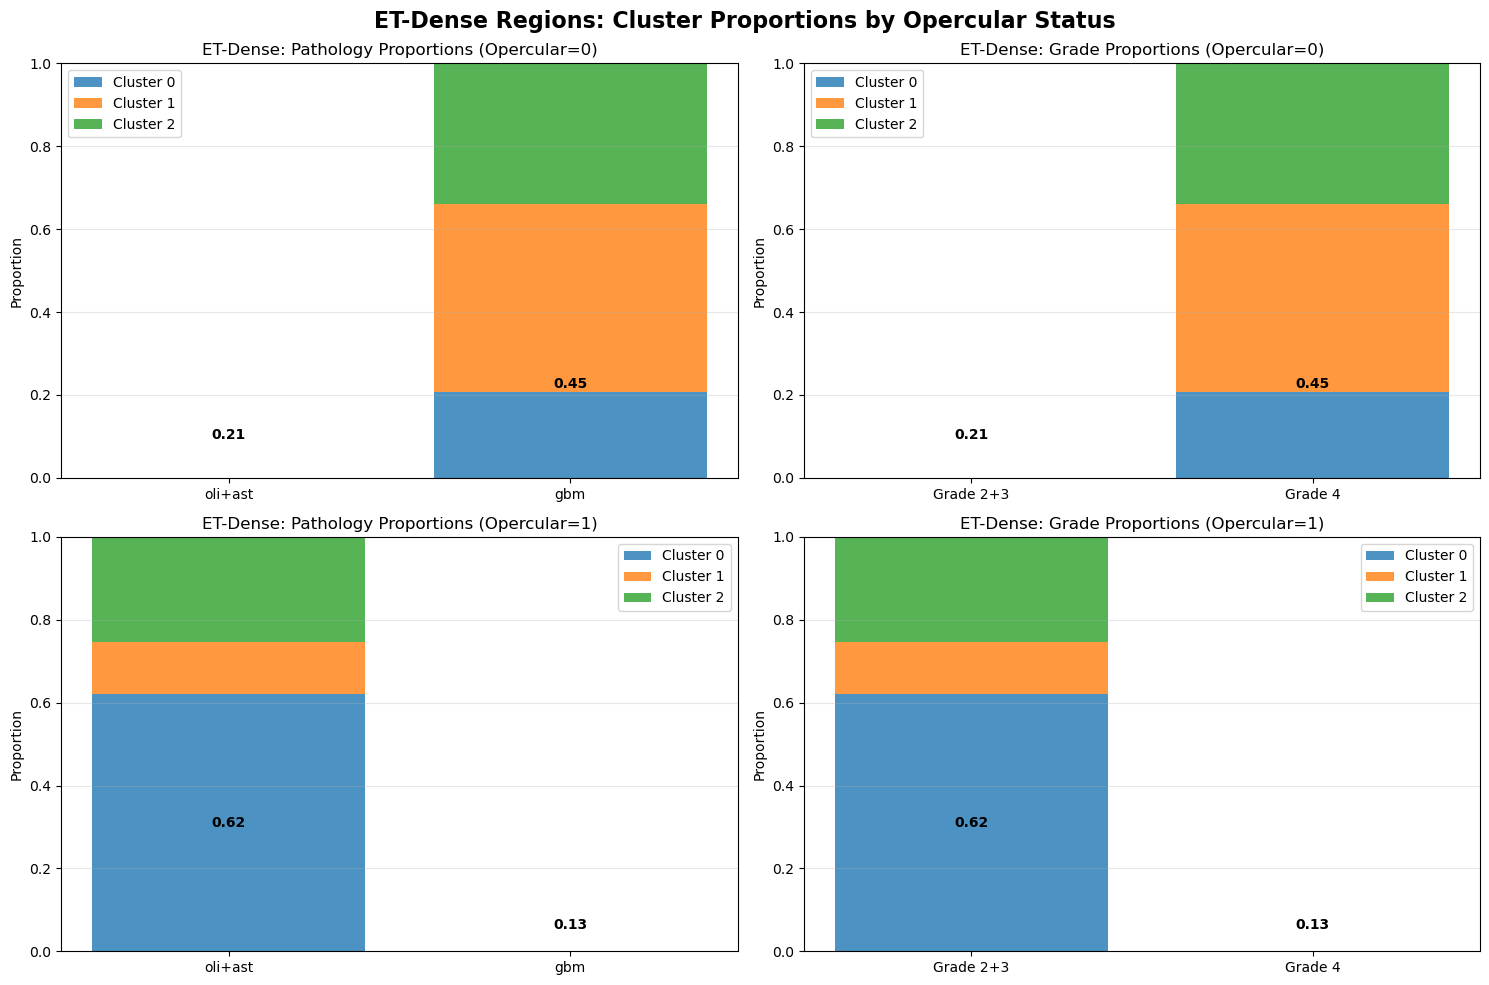

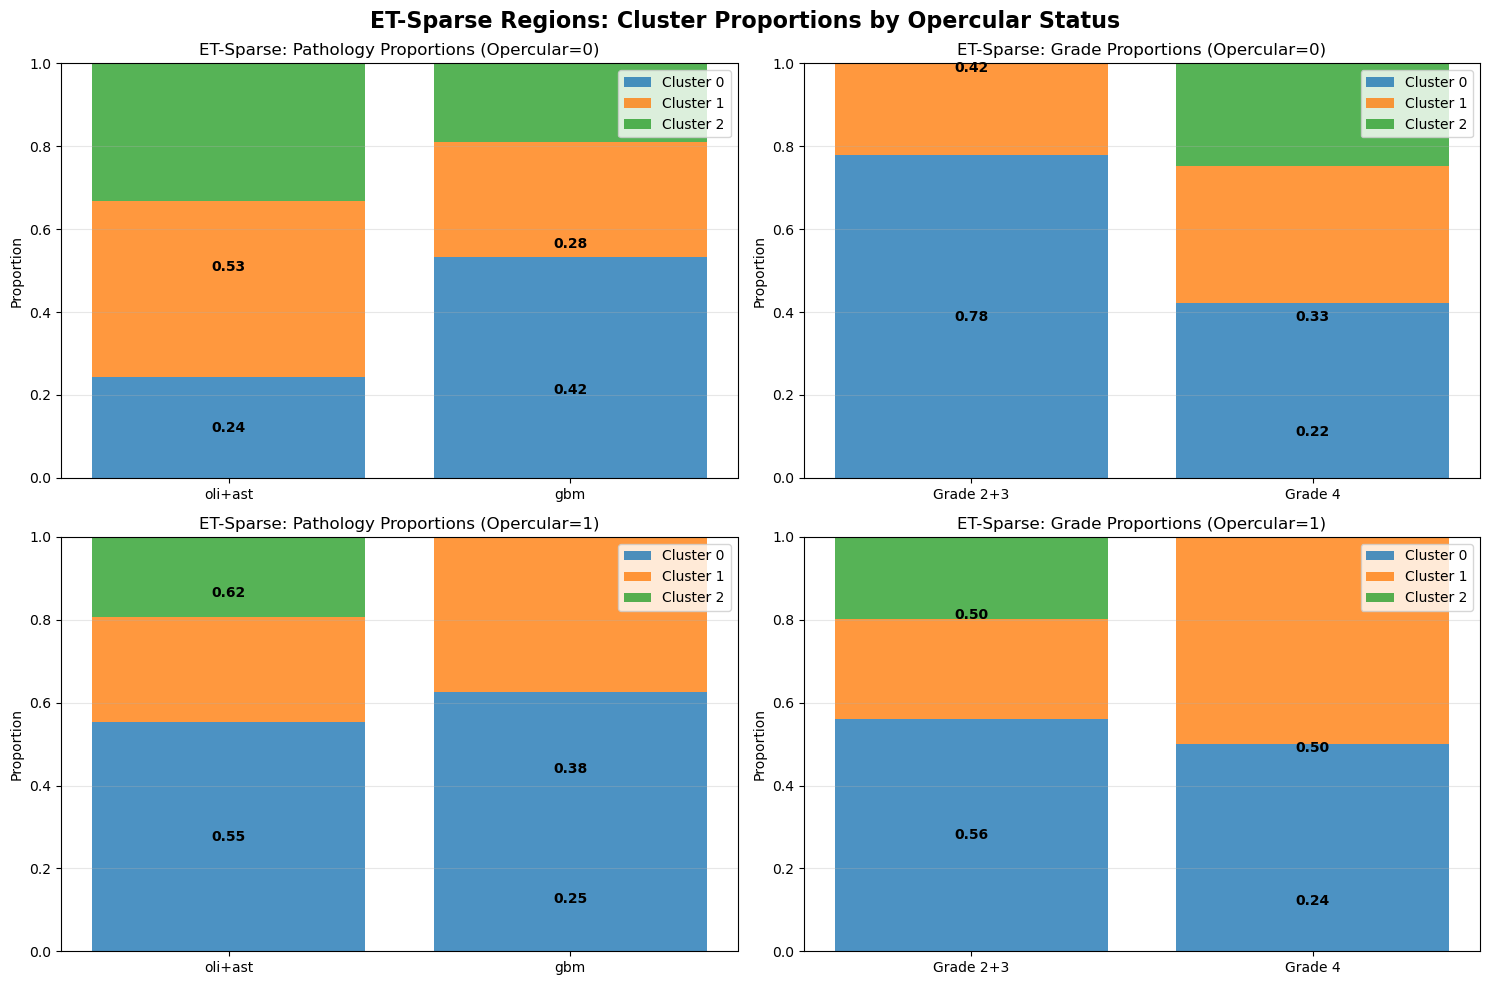


=== SUMMARY STATISTICS BY OPERCULAR STATUS ===
ET-Dense regions:
  Opercular=0 neurons: 519
  Opercular=1 neurons: 71

ET-Sparse regions:
  Opercular=0 neurons: 203
  Opercular=1 neurons: 178

Opercular status analysis complete!


In [20]:
# SEPARATE ANALYSIS BY OPERCULAR STATUS: ET-DENSE vs ET-SPARSE
print("\n=== SEPARATE ANALYSIS BY OPERCULAR STATUS: ET-DENSE vs ET-SPARSE ===")

# Function to calculate proportions for opercular subgroups
def calculate_proportions_opercular(labels, metadata, group_variable, group_values, opercular_value):
    """Calculate proportion of each cluster within a specific group and opercular status"""
    if isinstance(group_values, str):
        group_values = [group_values]
    
    group_mask = np.array([neuron[group_variable] in group_values for neuron in metadata])
    opercular_mask = np.array([neuron['opercular'] == opercular_value for neuron in metadata])
    combined_mask = group_mask & opercular_mask
    
    group_labels = labels[combined_mask]
    
    if len(group_labels) == 0:
        return np.zeros(3)  # Return zeros if no data
    
    cluster_counts = np.bincount(group_labels, minlength=3)
    proportions = cluster_counts / np.sum(cluster_counts)
    return proportions

# Define colors for clusters
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
grade_colors = ['#1f77b4', '#ff7f0e'] # Blue for 2+3, Orange for 4
path_colors = ['#2ca02c', '#d62728'] # Green for oli+ast, Red for gbm

# ET-DENSE REGIONS ANALYSIS BY OPERCULAR STATUS
print("ET-Dense regions analysis by opercular status:")

# ET-Dense: Pathology proportions by opercular status
et_dense_oli_ast_op0_props = calculate_proportions_opercular(et_dense_labels, et_dense_metadata, 'pathology', ['oli', 'ast'], 0)
et_dense_gbm_op0_props = calculate_proportions_opercular(et_dense_labels, et_dense_metadata, 'pathology', ['gbm'], 0)
et_dense_oli_ast_op1_props = calculate_proportions_opercular(et_dense_labels, et_dense_metadata, 'pathology', ['oli', 'ast'], 1)
et_dense_gbm_op1_props = calculate_proportions_opercular(et_dense_labels, et_dense_metadata, 'pathology', ['gbm'], 1)

# ET-Dense: Grade proportions by opercular status
et_dense_grade2_3_op0_props = calculate_proportions_opercular(et_dense_labels, et_dense_metadata, 'grade', [2, 3], 0)
et_dense_grade4_op0_props = calculate_proportions_opercular(et_dense_labels, et_dense_metadata, 'grade', [4], 0)
et_dense_grade2_3_op1_props = calculate_proportions_opercular(et_dense_labels, et_dense_metadata, 'grade', [2, 3], 1)
et_dense_grade4_op1_props = calculate_proportions_opercular(et_dense_labels, et_dense_metadata, 'grade', [4], 1)

print(f"ET-Dense oli+ast opercular=0 proportions: {et_dense_oli_ast_op0_props}")
print(f"ET-Dense gbm opercular=0 proportions: {et_dense_gbm_op0_props}")
print(f"ET-Dense oli+ast opercular=1 proportions: {et_dense_oli_ast_op1_props}")
print(f"ET-Dense gbm opercular=1 proportions: {et_dense_gbm_op1_props}")

# ET-SPARSE REGIONS ANALYSIS BY OPERCULAR STATUS
print("\nET-Sparse regions analysis by opercular status:")

# ET-Sparse: Pathology proportions by opercular status
et_sparse_oli_ast_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'], 0)
et_sparse_gbm_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'pathology', ['gbm'], 0)
et_sparse_oli_ast_op1_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'], 1)
et_sparse_gbm_op1_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'pathology', ['gbm'], 1)

# ET-Sparse: Grade proportions by opercular status
et_sparse_grade2_3_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3], 0)
et_sparse_grade4_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'grade', [4], 0)
et_sparse_grade2_3_op1_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3], 1)
et_sparse_grade4_op1_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'grade', [4], 1)

print(f"ET-Sparse oli+ast opercular=0 proportions: {et_sparse_oli_ast_op0_props}")
print(f"ET-Sparse gbm opercular=0 proportions: {et_sparse_gbm_op0_props}")
print(f"ET-Sparse oli+ast opercular=1 proportions: {et_sparse_oli_ast_op1_props}")
print(f"ET-Sparse gbm opercular=1 proportions: {et_sparse_gbm_op1_props}")

# Create plots for ET-Dense regions by opercular status
fig_dense, axes_dense = plt.subplots(2, 2, figsize=(15, 10))
fig_dense.suptitle('ET-Dense Regions: Cluster Proportions by Opercular Status', fontsize=16, fontweight='bold')

# PLOT 1: ET-Dense Pathology Proportions - Opercular=0
ax1 = axes_dense[0, 0]
groups = ['oli+ast', 'gbm']
et_dense_path_op0_data = [et_dense_oli_ast_op0_props, et_dense_gbm_op0_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_dense_path_op0_data).T, cluster_colors)):
    ax1.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax1.set_title('ET-Dense: Pathology Proportions (Opercular=0)')
ax1.set_ylabel('Proportion')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_dense_path_op0_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax1.text(i, np.sum(et_dense_path_op0_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

# PLOT 2: ET-Dense Grade Proportions - Opercular=0
ax2 = axes_dense[0, 1]
groups = ['Grade 2+3', 'Grade 4']
et_dense_grade_op0_data = [et_dense_grade2_3_op0_props, et_dense_grade4_op0_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_dense_grade_op0_data).T, cluster_colors)):
    ax2.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax2.set_title('ET-Dense: Grade Proportions (Opercular=0)')
ax2.set_ylabel('Proportion')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_dense_grade_op0_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax2.text(i, np.sum(et_dense_grade_op0_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

# PLOT 3: ET-Dense Pathology Proportions - Opercular=1
ax3 = axes_dense[1, 0]
groups = ['oli+ast', 'gbm']
et_dense_path_op1_data = [et_dense_oli_ast_op1_props, et_dense_gbm_op1_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_dense_path_op1_data).T, cluster_colors)):
    ax3.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax3.set_title('ET-Dense: Pathology Proportions (Opercular=1)')
ax3.set_ylabel('Proportion')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_dense_path_op1_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax3.text(i, np.sum(et_dense_path_op1_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

# PLOT 4: ET-Dense Grade Proportions - Opercular=1
ax4 = axes_dense[1, 1]
groups = ['Grade 2+3', 'Grade 4']
et_dense_grade_op1_data = [et_dense_grade2_3_op1_props, et_dense_grade4_op1_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_dense_grade_op1_data).T, cluster_colors)):
    ax4.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax4.set_title('ET-Dense: Grade Proportions (Opercular=1)')
ax4.set_ylabel('Proportion')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_dense_grade_op1_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax4.text(i, np.sum(et_dense_grade_op1_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Create plots for ET-Sparse regions by opercular status
fig_sparse, axes_sparse = plt.subplots(2, 2, figsize=(15, 10))
fig_sparse.suptitle('ET-Sparse Regions: Cluster Proportions by Opercular Status', fontsize=16, fontweight='bold')

# PLOT 1: ET-Sparse Pathology Proportions - Opercular=0
ax1 = axes_sparse[0, 0]
groups = ['oli+ast', 'gbm']
et_sparse_path_op0_data = [et_sparse_oli_ast_op0_props, et_sparse_gbm_op0_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_path_op0_data).T, cluster_colors)):
    ax1.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax1.set_title('ET-Sparse: Pathology Proportions (Opercular=0)')
ax1.set_ylabel('Proportion')
ax1.set_ylim(0, 1)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_sparse_path_op0_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax1.text(i, np.sum(et_sparse_path_op0_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

# PLOT 2: ET-Sparse Grade Proportions - Opercular=0
ax2 = axes_sparse[0, 1]
groups = ['Grade 2+3', 'Grade 4']
et_sparse_grade_op0_data = [et_sparse_grade2_3_op0_props, et_sparse_grade4_op0_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_grade_op0_data).T, cluster_colors)):
    ax2.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax2.set_title('ET-Sparse: Grade Proportions (Opercular=0)')
ax2.set_ylabel('Proportion')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_sparse_grade_op0_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax2.text(i, np.sum(et_sparse_grade_op0_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

# PLOT 3: ET-Sparse Pathology Proportions - Opercular=1
ax3 = axes_sparse[1, 0]
groups = ['oli+ast', 'gbm']
et_sparse_path_op1_data = [et_sparse_oli_ast_op1_props, et_sparse_gbm_op1_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_path_op1_data).T, cluster_colors)):
    ax3.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax3.set_title('ET-Sparse: Pathology Proportions (Opercular=1)')
ax3.set_ylabel('Proportion')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_sparse_path_op1_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax3.text(i, np.sum(et_sparse_path_op1_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

# PLOT 4: ET-Sparse Grade Proportions - Opercular=1
ax4 = axes_sparse[1, 1]
groups = ['Grade 2+3', 'Grade 4']
et_sparse_grade_op1_data = [et_sparse_grade2_3_op1_props, et_sparse_grade4_op1_props]

# Create stacked bars
bottom = np.zeros(2)
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_grade_op1_data).T, cluster_colors)):
    ax4.bar(groups, cluster_props, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax4.set_title('ET-Sparse: Grade Proportions (Opercular=1)')
ax4.set_ylabel('Proportion')
ax4.set_ylim(0, 1)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for i, group in enumerate(groups):
    for j, cluster_props in enumerate(et_sparse_grade_op1_data):
        if cluster_props[i] > 0.05:  # Only label if proportion > 5%
            ax4.text(i, np.sum(et_sparse_grade_op1_data[:j+1], axis=0)[i] - cluster_props[i]/2, 
                    f'{cluster_props[i]:.2f}', ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics by opercular status
print("\n=== SUMMARY STATISTICS BY OPERCULAR STATUS ===")
print("ET-Dense regions:")
print(f"  Opercular=0 neurons: {np.sum([neuron['opercular'] == 0 for neuron in et_dense_metadata])}")
print(f"  Opercular=1 neurons: {np.sum([neuron['opercular'] == 1 for neuron in et_dense_metadata])}")

print("\nET-Sparse regions:")
print(f"  Opercular=0 neurons: {np.sum([neuron['opercular'] == 0 for neuron in et_sparse_metadata])}")
print(f"  Opercular=1 neurons: {np.sum([neuron['opercular'] == 1 for neuron in et_sparse_metadata])}")

print("\nOpercular status analysis complete!")

ET-Sparse regions analysis by opercular status = 0:
ET-Sparse oli+ast opercular=0 proportions: [0.24242424 0.42424242 0.33333333]
ET-Sparse gbm opercular=0 proportions: [0.53284672 0.27737226 0.18978102]
ET-Sparse grade 2+3 opercular=0 proportions: [0.77777778 0.22222222 0.        ]
ET-Sparse grade 4 opercular=0 proportions: [0.42268041 0.32989691 0.24742268]

=== STATISTICAL TESTS ===
Pathology comparison (oli+ast vs gbm):
  Overall Chi-square = 15.4062, p-value = 0.0005
  Post-hoc pairwise comparisons:
    Cluster 0: χ² = 14.102, p = 0.0002 ***
      oli+ast prop = 0.242, gbm prop = 0.533
    Cluster 1: χ² = 3.735, p = 0.0533 ns
      oli+ast prop = 0.424, gbm prop = 0.277
    Cluster 2: χ² = 4.320, p = 0.0377 *
      oli+ast prop = 0.333, gbm prop = 0.190

Grade comparison (2+3 vs 4):
  Overall Chi-square = 5.0072, p-value = 0.0818
  Post-hoc pairwise comparisons:
    Cluster 0: χ² = 3.081, p = 0.0792 ns
      grade 2+3 prop = 0.778, grade 4 prop = 0.423
    Cluster 1: χ² = 0.096, p

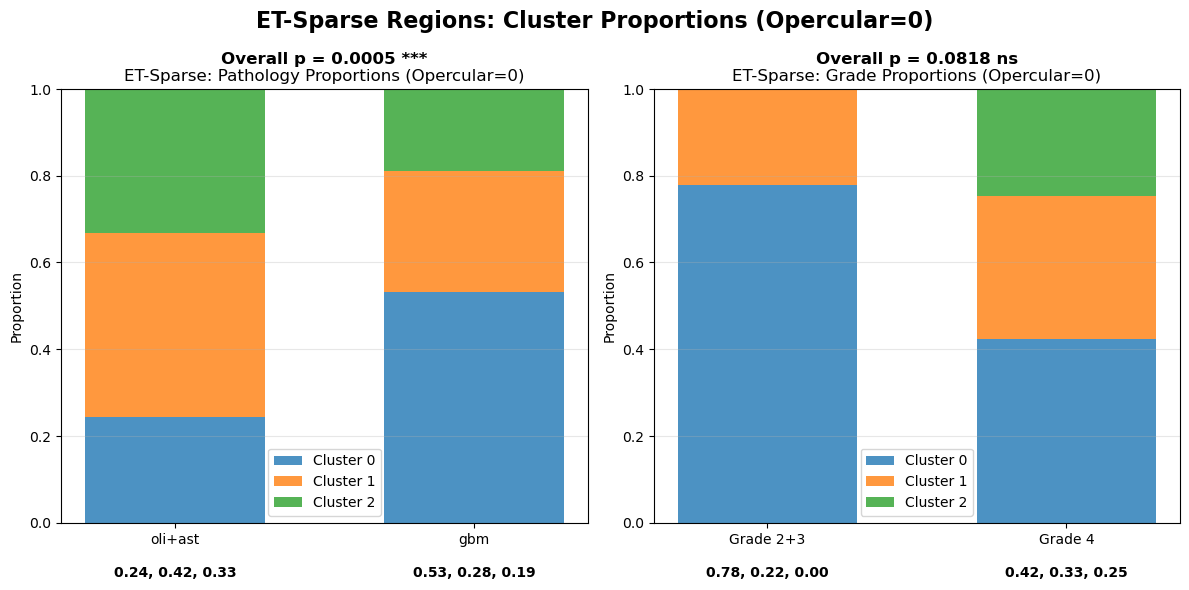


=== DETAILED CLUSTER COMPARISONS ===
Pathology comparison (oli+ast vs gbm) - Cluster proportions:


In [21]:
# ET-SPARSE REGIONS ANALYSIS BY OPERCULAR STATUS = 0 ONLY
# WITH STATISTICAL COMPARISONS AND POST-HOC PAIRWISE TESTS
plt.rcParams['svg.fonttype'] = 'none' 

# Function to calculate proportions for opercular subgroups
def calculate_proportions_opercular(labels, metadata, group_variable, group_values, opercular_value):
    """Calculate proportion of each cluster within a specific group and opercular status"""
    if isinstance(group_values, str):
        group_values = [group_values]
    
    group_mask = np.array([neuron[group_variable] in group_values for neuron in metadata])
    opercular_mask = np.array([neuron['opercular'] == opercular_value for neuron in metadata])
    combined_mask = group_mask & opercular_mask
    
    group_labels = labels[combined_mask]
    
    if len(group_labels) == 0:
        return np.zeros(3)  # Return zeros if no data
    
    cluster_counts = np.bincount(group_labels, minlength=3)
    proportions = cluster_counts / np.sum(cluster_counts)
    return proportions

# Function to perform chi-square test for cluster proportions
def chi_square_test_clusters(labels, metadata, group_variable, group1_values, group2_values, opercular_value):
    """Perform chi-square test comparing cluster distributions between two groups"""
    from scipy.stats import chi2_contingency
    
    # Get masks for both groups
    group1_mask = np.array([neuron[group_variable] in group1_values for neuron in metadata])
    group2_mask = np.array([neuron[group_variable] in group2_values for neuron in metadata])
    opercular_mask = np.array([neuron['opercular'] == opercular_value for neuron in metadata])
    
    combined_mask1 = group1_mask & opercular_mask
    combined_mask2 = group2_mask & opercular_mask
    
    group1_labels = labels[combined_mask1]
    group2_labels = labels[combined_mask2]
    
    if len(group1_labels) == 0 or len(group2_labels) == 0:
        return None, None
    
    # Create contingency table
    group1_counts = np.bincount(group1_labels, minlength=3)
    group2_counts = np.bincount(group2_labels, minlength=3)
    
    contingency_table = np.array([group1_counts, group2_counts])
    
    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    return chi2, p_value

# Function to perform post-hoc pairwise comparisons for individual clusters
def posthoc_cluster_comparisons(labels, metadata, group_variable, group1_values, group2_values, opercular_value):
    """Perform post-hoc comparisons for each individual cluster"""
    from scipy.stats import chi2_contingency
    
    # Get masks for both groups
    group1_mask = np.array([neuron[group_variable] in group1_values for neuron in metadata])
    group2_mask = np.array([neuron[group_variable] in group2_values for neuron in metadata])
    opercular_mask = np.array([neuron['opercular'] == opercular_value for neuron in metadata])
    
    combined_mask1 = group1_mask & opercular_mask
    combined_mask2 = group2_mask & opercular_mask
    
    group1_labels = labels[combined_mask1]
    group2_labels = labels[combined_mask2]
    
    if len(group1_labels) == 0 or len(group2_labels) == 0:
        return None
    
    # Create contingency table
    group1_counts = np.bincount(group1_labels, minlength=3)
    group2_counts = np.bincount(group2_labels, minlength=3)
    
    results = []
    
    # Test each cluster individually (cluster vs all others)
    for cluster_id in range(3):
        # Create 2x2 contingency table: cluster vs all others
        cluster1_count = group1_counts[cluster_id]
        other1_count = np.sum(group1_counts) - cluster1_count
        
        cluster2_count = group2_counts[cluster_id]
        other2_count = np.sum(group2_counts) - cluster2_count
        
        contingency_2x2 = np.array([[cluster1_count, other1_count],
                                   [cluster2_count, other2_count]])
        
        # Perform chi-square test
        chi2, p_value, dof, expected = chi2_contingency(contingency_2x2)
        
        results.append({
            'cluster': cluster_id,
            'chi2': chi2,
            'p_value': p_value,
            'group1_prop': cluster1_count / np.sum(group1_counts),
            'group2_prop': cluster2_count / np.sum(group2_counts)
        })
    
    return results

# Define colors for clusters
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# ET-SPARSE REGIONS ANALYSIS BY OPERCULAR STATUS = 0 ONLY
print("ET-Sparse regions analysis by opercular status = 0:")

# ET-Sparse: Pathology proportions by opercular status = 0
et_sparse_oli_ast_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'], 0)
et_sparse_gbm_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'pathology', ['gbm'], 0)

# ET-Sparse: Grade proportions by opercular status = 0
et_sparse_grade2_3_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3], 0)
et_sparse_grade4_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 'grade', [4], 0)

print(f"ET-Sparse oli+ast opercular=0 proportions: {et_sparse_oli_ast_op0_props}")
print(f"ET-Sparse gbm opercular=0 proportions: {et_sparse_gbm_op0_props}")
print(f"ET-Sparse grade 2+3 opercular=0 proportions: {et_sparse_grade2_3_op0_props}")
print(f"ET-Sparse grade 4 opercular=0 proportions: {et_sparse_grade4_op0_props}")

# Perform statistical tests
print("\n=== STATISTICAL TESTS ===")

# Pathology comparison (oli+ast vs gbm)
chi2_path, p_path = chi_square_test_clusters(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'], ['gbm'], 0)
print(f"Pathology comparison (oli+ast vs gbm):")
print(f"  Overall Chi-square = {chi2_path:.4f}, p-value = {p_path:.4f}")

# Post-hoc pairwise comparisons for pathology
path_posthoc = posthoc_cluster_comparisons(et_sparse_labels, et_sparse_metadata, 'pathology', ['oli', 'ast'], ['gbm'], 0)
if path_posthoc:
    print("  Post-hoc pairwise comparisons:")
    for result in path_posthoc:
        significance = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "ns"
        print(f"    Cluster {result['cluster']}: χ² = {result['chi2']:.3f}, p = {result['p_value']:.4f} {significance}")
        print(f"      oli+ast prop = {result['group1_prop']:.3f}, gbm prop = {result['group2_prop']:.3f}")

# Grade comparison (2+3 vs 4)
chi2_grade, p_grade = chi_square_test_clusters(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3], [4], 0)
print(f"\nGrade comparison (2+3 vs 4):")
print(f"  Overall Chi-square = {chi2_grade:.4f}, p-value = {p_grade:.4f}")

# Post-hoc pairwise comparisons for grade
grade_posthoc = posthoc_cluster_comparisons(et_sparse_labels, et_sparse_metadata, 'grade', [2, 3], [4], 0)
if grade_posthoc:
    print("  Post-hoc pairwise comparisons:")
    for result in grade_posthoc:
        significance = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "ns"
        print(f"    Cluster {result['cluster']}: χ² = {result['chi2']:.3f}, p = {result['p_value']:.4f} {significance}")
        print(f"      grade 2+3 prop = {result['group1_prop']:.3f}, grade 4 prop = {result['group2_prop']:.3f}")

# Create plots for ET-Sparse regions by opercular status = 0 only
fig_sparse, axes_sparse = plt.subplots(1, 2, figsize=(12, 6))
fig_sparse.suptitle('ET-Sparse Regions: Cluster Proportions (Opercular=0)', fontsize=16, fontweight='bold')

# PLOT 1: ET-Sparse Pathology Proportions - Opercular=0
ax1 = axes_sparse[0]
groups = ['oli+ast', 'gbm']
et_sparse_path_op0_data = [et_sparse_oli_ast_op0_props, et_sparse_gbm_op0_props]

# Create stacked bars
x_pos = np.arange(len(groups))
width = 0.6

bottom = np.zeros(len(groups))
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_path_op0_data).T, cluster_colors)):
    ax1.bar(x_pos, cluster_props, width, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax1.set_title('ET-Sparse: Pathology Proportions (Opercular=0)')
ax1.set_ylabel('Proportion')
ax1.set_ylim(0, 1)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(groups)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels at the bottom of each bar
for i, group in enumerate(groups):
    cluster_props = et_sparse_path_op0_data[i]
    label_text = f"{cluster_props[0]:.2f}, {cluster_props[1]:.2f}, {cluster_props[2]:.2f}"
    ax1.text(i, -0.1, label_text, ha='center', va='top', fontweight='bold', fontsize=10)

# Add significance annotation between bars
if p_path is not None:
    significance = "***" if p_path < 0.001 else "**" if p_path < 0.01 else "*" if p_path < 0.05 else "ns"
    ax1.text(0.5, 1.05, f"Overall p = {p_path:.4f} {significance}", ha='center', va='bottom', 
             fontweight='bold', fontsize=12, transform=ax1.transAxes)

# PLOT 2: ET-Sparse Grade Proportions - Opercular=0
ax2 = axes_sparse[1]
groups = ['Grade 2+3', 'Grade 4']
et_sparse_grade_op0_data = [et_sparse_grade2_3_op0_props, et_sparse_grade4_op0_props]

# Create stacked bars
bottom = np.zeros(len(groups))
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_grade_op0_data).T, cluster_colors)):
    ax2.bar(x_pos, cluster_props, width, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax2.set_title('ET-Sparse: Grade Proportions (Opercular=0)')
ax2.set_ylabel('Proportion')
ax2.set_ylim(0, 1)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(groups)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels at the bottom of each bar
for i, group in enumerate(groups):
    cluster_props = et_sparse_grade_op0_data[i]
    label_text = f"{cluster_props[0]:.2f}, {cluster_props[1]:.2f}, {cluster_props[2]:.2f}"
    ax2.text(i, -0.1, label_text, ha='center', va='top', fontweight='bold', fontsize=10)

# Add significance annotation between bars
if p_grade is not None:
    significance = "***" if p_grade < 0.001 else "**" if p_grade < 0.01 else "*" if p_grade < 0.05 else "ns"
    ax2.text(0.5, 1.05, f"Overall p = {p_grade:.4f} {significance}", ha='center', va='bottom', 
             fontweight='bold', fontsize=12, transform=ax2.transAxes)

plt.tight_layout()
plt.savefig("groupproprotions_sparse.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Print detailed cluster-by-cluster comparisons
print("\n=== DETAILED CLUSTER COMPARISONS ===")

# Pathology comparison - cluster by cluster
print("Pathology comparison (oli+ast vs gbm) - Cluster proportions:")
for i in range(3):
    oli_ast_prop = et_sparse_oli_ast_op0_props[i]
    gbm_prop = et_sparse_gbm_op0_props[i]
    diff = gbm_prop - oli_ast_prop


ET-Sparse regions analysis by opercular status (0 vs 1):
ET-Sparse opercular=0 proportions: [0.43842365 0.32512315 0.2364532 ]
ET-Sparse opercular=1 proportions: [0.55617978 0.25842697 0.18539326]

=== STATISTICAL TESTS ===
Opercular comparison (0 vs 1):
  Overall Chi-square = 5.2634, p-value = 0.0720
  Post-hoc pairwise comparisons:
    Cluster 0: χ² = 4.801, p = 0.0284 *
      opercular=0 prop = 0.438, opercular=1 prop = 0.556
    Cluster 1: χ² = 1.724, p = 0.1892 ns
      opercular=0 prop = 0.325, opercular=1 prop = 0.258
    Cluster 2: χ² = 1.188, p = 0.2758 ns
      opercular=0 prop = 0.236, opercular=1 prop = 0.185


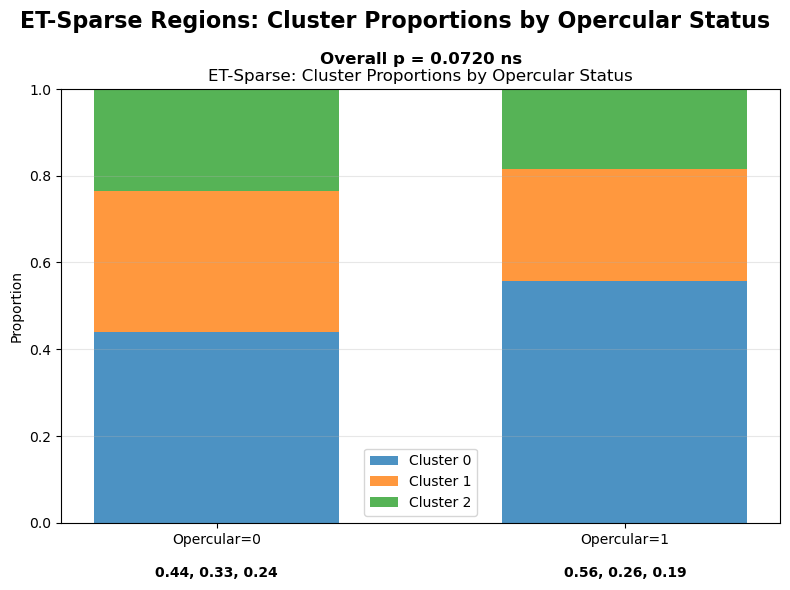


=== DETAILED CLUSTER COMPARISONS ===
Opercular comparison (0 vs 1) - Cluster proportions:
  Cluster 0: opercular=0 = 0.438, opercular=1 = 0.556, diff = +0.118
  Cluster 1: opercular=0 = 0.325, opercular=1 = 0.258, diff = -0.067
  Cluster 2: opercular=0 = 0.236, opercular=1 = 0.185, diff = -0.051

ET-Sparse opercular analysis complete!


In [22]:
# ET-SPARSE REGIONS ANALYSIS BY OPERCULAR STATUS (0 vs 1)
# WITH STATISTICAL COMPARISONS AND POST-HOC PAIRWISE TESTS
plt.rcParams['svg.fonttype'] = 'none' 

# Function to calculate proportions for opercular subgroups
def calculate_proportions_opercular(labels, metadata, opercular_value):
    """Calculate proportion of each cluster within a specific opercular status"""
    opercular_mask = np.array([neuron['opercular'] == opercular_value for neuron in metadata])
    
    group_labels = labels[opercular_mask]
    
    if len(group_labels) == 0:
        return np.zeros(3)  # Return zeros if no data
    
    cluster_counts = np.bincount(group_labels, minlength=3)
    proportions = cluster_counts / np.sum(cluster_counts)
    return proportions

# Function to perform chi-square test for cluster proportions
def chi_square_test_clusters(labels, metadata, opercular1_value, opercular2_value):
    """Perform chi-square test comparing cluster distributions between two opercular statuses"""
    from scipy.stats import chi2_contingency
    
    # Get masks for both opercular statuses
    opercular1_mask = np.array([neuron['opercular'] == opercular1_value for neuron in metadata])
    opercular2_mask = np.array([neuron['opercular'] == opercular2_value for neuron in metadata])
    
    group1_labels = labels[opercular1_mask]
    group2_labels = labels[opercular2_mask]
    
    if len(group1_labels) == 0 or len(group2_labels) == 0:
        return None, None
    
    # Create contingency table
    group1_counts = np.bincount(group1_labels, minlength=3)
    group2_counts = np.bincount(group2_labels, minlength=3)
    
    contingency_table = np.array([group1_counts, group2_counts])
    
    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    return chi2, p_value

# Function to perform post-hoc pairwise comparisons for individual clusters
def posthoc_cluster_comparisons(labels, metadata, opercular1_value, opercular2_value):
    """Perform post-hoc comparisons for each individual cluster"""
    from scipy.stats import chi2_contingency
    
    # Get masks for both opercular statuses
    opercular1_mask = np.array([neuron['opercular'] == opercular1_value for neuron in metadata])
    opercular2_mask = np.array([neuron['opercular'] == opercular2_value for neuron in metadata])
    
    group1_labels = labels[opercular1_mask]
    group2_labels = labels[opercular2_mask]
    
    if len(group1_labels) == 0 or len(group2_labels) == 0:
        return None
    
    # Create contingency table
    group1_counts = np.bincount(group1_labels, minlength=3)
    group2_counts = np.bincount(group2_labels, minlength=3)
    
    results = []
    
    # Test each cluster individually (cluster vs all others)
    for cluster_id in range(3):
        # Create 2x2 contingency table: cluster vs all others
        cluster1_count = group1_counts[cluster_id]
        other1_count = np.sum(group1_counts) - cluster1_count
        
        cluster2_count = group2_counts[cluster_id]
        other2_count = np.sum(group2_counts) - cluster2_count
        
        contingency_2x2 = np.array([[cluster1_count, other1_count],
                                   [cluster2_count, other2_count]])
        
        # Perform chi-square test
        chi2, p_value, dof, expected = chi2_contingency(contingency_2x2)
        
        results.append({
            'cluster': cluster_id,
            'chi2': chi2,
            'p_value': p_value,
            'group1_prop': cluster1_count / np.sum(group1_counts),
            'group2_prop': cluster2_count / np.sum(group2_counts)
        })
    
    return results

# Define colors for clusters
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# ET-SPARSE REGIONS ANALYSIS BY OPERCULAR STATUS (0 vs 1)
print("ET-Sparse regions analysis by opercular status (0 vs 1):")

# ET-Sparse: Proportions by opercular status
et_sparse_op0_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 0)
et_sparse_op1_props = calculate_proportions_opercular(et_sparse_labels, et_sparse_metadata, 1)

print(f"ET-Sparse opercular=0 proportions: {et_sparse_op0_props}")
print(f"ET-Sparse opercular=1 proportions: {et_sparse_op1_props}")

# Perform statistical tests
print("\n=== STATISTICAL TESTS ===")

# Opercular comparison (0 vs 1)
chi2_opercular, p_opercular = chi_square_test_clusters(et_sparse_labels, et_sparse_metadata, 0, 1)
print(f"Opercular comparison (0 vs 1):")
print(f"  Overall Chi-square = {chi2_opercular:.4f}, p-value = {p_opercular:.4f}")

# Post-hoc pairwise comparisons for opercular
opercular_posthoc = posthoc_cluster_comparisons(et_sparse_labels, et_sparse_metadata, 0, 1)
if opercular_posthoc:
    print("  Post-hoc pairwise comparisons:")
    for result in opercular_posthoc:
        significance = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "ns"
        print(f"    Cluster {result['cluster']}: χ² = {result['chi2']:.3f}, p = {result['p_value']:.4f} {significance}")
        print(f"      opercular=0 prop = {result['group1_prop']:.3f}, opercular=1 prop = {result['group2_prop']:.3f}")

# Create plot for ET-Sparse regions by opercular status
fig_sparse, ax_sparse = plt.subplots(1, 1, figsize=(8, 6))
fig_sparse.suptitle('ET-Sparse Regions: Cluster Proportions by Opercular Status', fontsize=16, fontweight='bold')

# ET-Sparse Opercular Proportions
groups = ['Opercular=0', 'Opercular=1']
et_sparse_opercular_data = [et_sparse_op0_props, et_sparse_op1_props]

# Create stacked bars
x_pos = np.arange(len(groups))
width = 0.6

bottom = np.zeros(len(groups))
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_opercular_data).T, cluster_colors)):
    ax_sparse.bar(x_pos, cluster_props, width, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax_sparse.set_title('ET-Sparse: Cluster Proportions by Opercular Status')
ax_sparse.set_ylabel('Proportion')
ax_sparse.set_ylim(0, 1)
ax_sparse.set_xticks(x_pos)
ax_sparse.set_xticklabels(groups)
ax_sparse.legend()
ax_sparse.grid(axis='y', alpha=0.3)

# Add value labels at the bottom of each bar
for i, group in enumerate(groups):
    cluster_props = et_sparse_opercular_data[i]
    label_text = f"{cluster_props[0]:.2f}, {cluster_props[1]:.2f}, {cluster_props[2]:.2f}"
    ax_sparse.text(i, -0.1, label_text, ha='center', va='top', fontweight='bold', fontsize=10)

# Add significance annotation between bars
if p_opercular is not None:
    significance = "***" if p_opercular < 0.001 else "**" if p_opercular < 0.01 else "*" if p_opercular < 0.05 else "ns"
    ax_sparse.text(0.5, 1.05, f"Overall p = {p_opercular:.4f} {significance}", ha='center', va='bottom', 
             fontweight='bold', fontsize=12, transform=ax_sparse.transAxes)

plt.tight_layout()
plt.savefig("groupproprotions_sparse_opercular.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Print detailed cluster-by-cluster comparisons
print("\n=== DETAILED CLUSTER COMPARISONS ===")

# Opercular comparison - cluster by cluster
print("Opercular comparison (0 vs 1) - Cluster proportions:")
for i in range(3):
    op0_prop = et_sparse_op0_props[i]
    op1_prop = et_sparse_op1_props[i]
    diff = op1_prop - op0_prop
    print(f"  Cluster {i}: opercular=0 = {op0_prop:.3f}, opercular=1 = {op1_prop:.3f}, diff = {diff:+.3f}")

print("\nET-Sparse opercular analysis complete!")

ET-Sparse regions analysis by opercular status (0 vs 1) - separate by pathology:
ET-Sparse oli+ast opercular=0 proportions: [0.24242424 0.42424242 0.33333333]
ET-Sparse oli+ast opercular=1 proportions: [0.55294118 0.25294118 0.19411765]
ET-Sparse gbm opercular=0 proportions: [0.53284672 0.27737226 0.18978102]
ET-Sparse gbm opercular=1 proportions: [0.625 0.375 0.   ]

=== STATISTICAL TESTS ===
Opercular comparison for oli+ast (0 vs 1):
  Overall Chi-square = 18.4258, p-value = 0.0001
  Post-hoc pairwise comparisons:
    Cluster 0: χ² = 17.194, p = 0.0000 ***
      opercular=0 prop = 0.242, opercular=1 prop = 0.553
    Cluster 1: χ² = 5.843, p = 0.0156 *
      opercular=0 prop = 0.424, opercular=1 prop = 0.253
    Cluster 2: χ² = 4.406, p = 0.0358 *
      opercular=0 prop = 0.333, opercular=1 prop = 0.194

Opercular comparison for gbm (0 vs 1):
  Overall Chi-square = 1.8924, p-value = 0.3882
  Post-hoc pairwise comparisons:
    Cluster 0: χ² = 0.021, p = 0.8860 ns
      opercular=0 prop

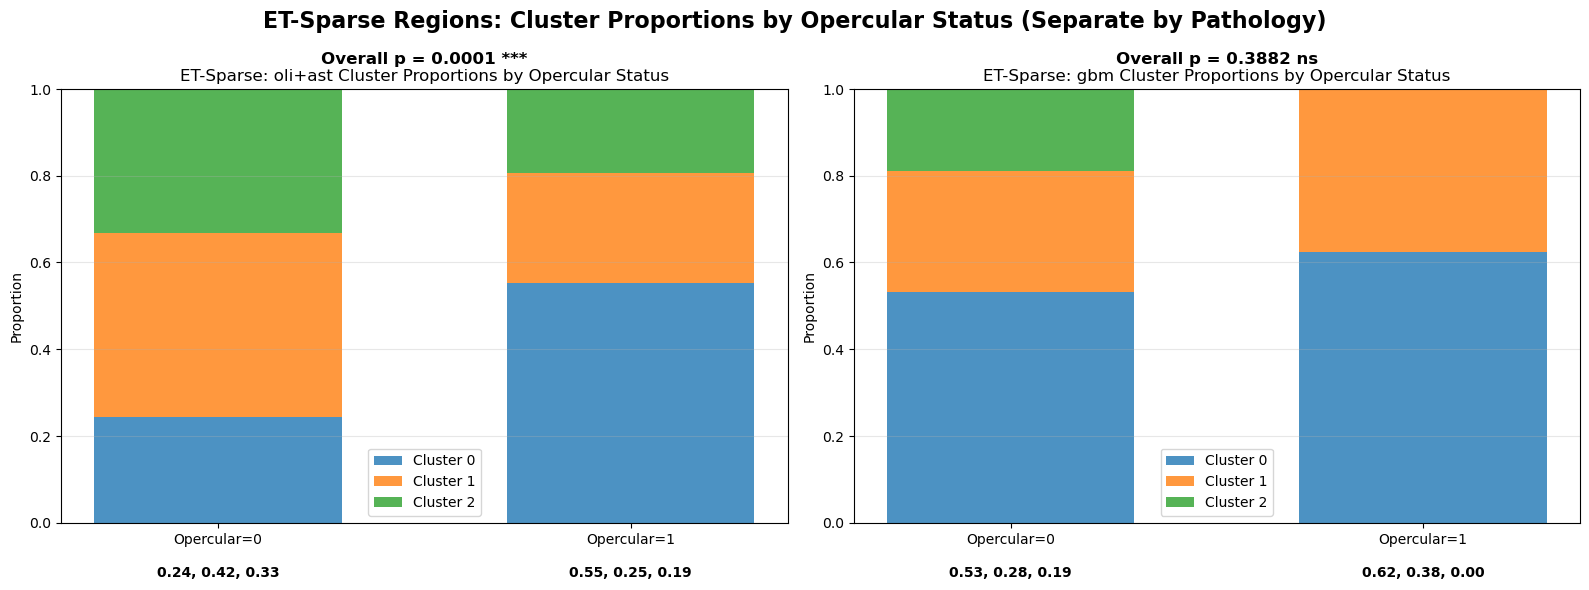


=== DETAILED CLUSTER COMPARISONS ===
Opercular comparison for oli+ast (0 vs 1) - Cluster proportions:
  Cluster 0: opercular=0 = 0.242, opercular=1 = 0.553, diff = +0.311
  Cluster 1: opercular=0 = 0.424, opercular=1 = 0.253, diff = -0.171
  Cluster 2: opercular=0 = 0.333, opercular=1 = 0.194, diff = -0.139

Opercular comparison for gbm (0 vs 1) - Cluster proportions:
  Cluster 0: opercular=0 = 0.533, opercular=1 = 0.625, diff = +0.092
  Cluster 1: opercular=0 = 0.277, opercular=1 = 0.375, diff = +0.098
  Cluster 2: opercular=0 = 0.190, opercular=1 = 0.000, diff = -0.190

ET-Sparse opercular analysis by pathology complete!


In [23]:
# ET-SPARSE REGIONS ANALYSIS BY OPERCULAR STATUS (0 vs 1) - SEPARATE BY PATHOLOGY
# WITH STATISTICAL COMPARISONS AND POST-HOC PAIRWISE TESTS
plt.rcParams['svg.fonttype'] = 'none' 

# Function to calculate proportions for opercular subgroups within specific pathology
def calculate_proportions_opercular_pathology(labels, metadata, pathology_values, opercular_value):
    """Calculate proportion of each cluster within a specific pathology and opercular status"""
    if isinstance(pathology_values, str):
        pathology_values = [pathology_values]
    
    pathology_mask = np.array([neuron['pathology'] in pathology_values for neuron in metadata])
    opercular_mask = np.array([neuron['opercular'] == opercular_value for neuron in metadata])
    combined_mask = pathology_mask & opercular_mask
    
    group_labels = labels[combined_mask]
    
    if len(group_labels) == 0:
        return np.zeros(3)  # Return zeros if no data
    
    cluster_counts = np.bincount(group_labels, minlength=3)
    proportions = cluster_counts / np.sum(cluster_counts)
    return proportions

# Function to perform chi-square test for cluster proportions within specific pathology
def chi_square_test_clusters_pathology(labels, metadata, pathology_values, opercular1_value, opercular2_value):
    """Perform chi-square test comparing cluster distributions between two opercular statuses within specific pathology"""
    from scipy.stats import chi2_contingency
    
    if isinstance(pathology_values, str):
        pathology_values = [pathology_values]
    
    # Get masks for both opercular statuses within specific pathology
    pathology_mask = np.array([neuron['pathology'] in pathology_values for neuron in metadata])
    opercular1_mask = np.array([neuron['opercular'] == opercular1_value for neuron in metadata])
    opercular2_mask = np.array([neuron['opercular'] == opercular2_value for neuron in metadata])
    
    combined_mask1 = pathology_mask & opercular1_mask
    combined_mask2 = pathology_mask & opercular2_mask
    
    group1_labels = labels[combined_mask1]
    group2_labels = labels[combined_mask2]
    
    if len(group1_labels) == 0 or len(group2_labels) == 0:
        return None, None
    
    # Create contingency table
    group1_counts = np.bincount(group1_labels, minlength=3)
    group2_counts = np.bincount(group2_labels, minlength=3)
    
    contingency_table = np.array([group1_counts, group2_counts])
    
    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    return chi2, p_value

# Function to perform post-hoc pairwise comparisons for individual clusters within specific pathology
def posthoc_cluster_comparisons_pathology(labels, metadata, pathology_values, opercular1_value, opercular2_value):
    """Perform post-hoc comparisons for each individual cluster within specific pathology"""
    from scipy.stats import chi2_contingency
    
    if isinstance(pathology_values, str):
        pathology_values = [pathology_values]
    
    # Get masks for both opercular statuses within specific pathology
    pathology_mask = np.array([neuron['pathology'] in pathology_values for neuron in metadata])
    opercular1_mask = np.array([neuron['opercular'] == opercular1_value for neuron in metadata])
    opercular2_mask = np.array([neuron['opercular'] == opercular2_value for neuron in metadata])
    
    combined_mask1 = pathology_mask & opercular1_mask
    combined_mask2 = pathology_mask & opercular2_mask
    
    group1_labels = labels[combined_mask1]
    group2_labels = labels[combined_mask2]
    
    if len(group1_labels) == 0 or len(group2_labels) == 0:
        return None
    
    # Create contingency table
    group1_counts = np.bincount(group1_labels, minlength=3)
    group2_counts = np.bincount(group2_labels, minlength=3)
    
    results = []
    
    # Test each cluster individually (cluster vs all others)
    for cluster_id in range(3):
        # Create 2x2 contingency table: cluster vs all others
        cluster1_count = group1_counts[cluster_id]
        other1_count = np.sum(group1_counts) - cluster1_count
        
        cluster2_count = group2_counts[cluster_id]
        other2_count = np.sum(group2_counts) - cluster2_count
        
        contingency_2x2 = np.array([[cluster1_count, other1_count],
                                   [cluster2_count, other2_count]])
        
        # Perform chi-square test
        chi2, p_value, dof, expected = chi2_contingency(contingency_2x2)
        
        results.append({
            'cluster': cluster_id,
            'chi2': chi2,
            'p_value': p_value,
            'group1_prop': cluster1_count / np.sum(group1_counts),
            'group2_prop': cluster2_count / np.sum(group2_counts)
        })
    
    return results

# Define colors for clusters
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# ET-SPARSE REGIONS ANALYSIS BY OPERCULAR STATUS (0 vs 1) - SEPARATE BY PATHOLOGY
print("ET-Sparse regions analysis by opercular status (0 vs 1) - separate by pathology:")

# ET-Sparse: Proportions by opercular status for oli+ast
et_sparse_oli_ast_op0_props = calculate_proportions_opercular_pathology(et_sparse_labels, et_sparse_metadata, ['oli', 'ast'], 0)
et_sparse_oli_ast_op1_props = calculate_proportions_opercular_pathology(et_sparse_labels, et_sparse_metadata, ['oli', 'ast'], 1)

# ET-Sparse: Proportions by opercular status for gbm
et_sparse_gbm_op0_props = calculate_proportions_opercular_pathology(et_sparse_labels, et_sparse_metadata, ['gbm'], 0)
et_sparse_gbm_op1_props = calculate_proportions_opercular_pathology(et_sparse_labels, et_sparse_metadata, ['gbm'], 1)

print(f"ET-Sparse oli+ast opercular=0 proportions: {et_sparse_oli_ast_op0_props}")
print(f"ET-Sparse oli+ast opercular=1 proportions: {et_sparse_oli_ast_op1_props}")
print(f"ET-Sparse gbm opercular=0 proportions: {et_sparse_gbm_op0_props}")
print(f"ET-Sparse gbm opercular=1 proportions: {et_sparse_gbm_op1_props}")

# Perform statistical tests
print("\n=== STATISTICAL TESTS ===")

# Opercular comparison for oli+ast (0 vs 1)
chi2_oli_ast, p_oli_ast = chi_square_test_clusters_pathology(et_sparse_labels, et_sparse_metadata, ['oli', 'ast'], 0, 1)
print(f"Opercular comparison for oli+ast (0 vs 1):")
print(f"  Overall Chi-square = {chi2_oli_ast:.4f}, p-value = {p_oli_ast:.4f}")

# Post-hoc pairwise comparisons for oli+ast opercular
oli_ast_posthoc = posthoc_cluster_comparisons_pathology(et_sparse_labels, et_sparse_metadata, ['oli', 'ast'], 0, 1)
if oli_ast_posthoc:
    print("  Post-hoc pairwise comparisons:")
    for result in oli_ast_posthoc:
        significance = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "ns"
        print(f"    Cluster {result['cluster']}: χ² = {result['chi2']:.3f}, p = {result['p_value']:.4f} {significance}")
        print(f"      opercular=0 prop = {result['group1_prop']:.3f}, opercular=1 prop = {result['group2_prop']:.3f}")

# Opercular comparison for gbm (0 vs 1)
chi2_gbm, p_gbm = chi_square_test_clusters_pathology(et_sparse_labels, et_sparse_metadata, ['gbm'], 0, 1)
print(f"\nOpercular comparison for gbm (0 vs 1):")
print(f"  Overall Chi-square = {chi2_gbm:.4f}, p-value = {p_gbm:.4f}")

# Post-hoc pairwise comparisons for gbm opercular
gbm_posthoc = posthoc_cluster_comparisons_pathology(et_sparse_labels, et_sparse_metadata, ['gbm'], 0, 1)
if gbm_posthoc:
    print("  Post-hoc pairwise comparisons:")
    for result in gbm_posthoc:
        significance = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else "ns"
        print(f"    Cluster {result['cluster']}: χ² = {result['chi2']:.3f}, p = {result['p_value']:.4f} {significance}")
        print(f"      opercular=0 prop = {result['group1_prop']:.3f}, opercular=1 prop = {result['group2_prop']:.3f}")

# Create plots for ET-Sparse regions by opercular status - separate by pathology
fig_sparse, axes_sparse = plt.subplots(1, 2, figsize=(16, 6))
fig_sparse.suptitle('ET-Sparse Regions: Cluster Proportions by Opercular Status (Separate by Pathology)', fontsize=16, fontweight='bold')

# PLOT 1: ET-Sparse oli+ast Opercular Proportions
ax1 = axes_sparse[0]
groups = ['Opercular=0', 'Opercular=1']
et_sparse_oli_ast_opercular_data = [et_sparse_oli_ast_op0_props, et_sparse_oli_ast_op1_props]

# Create stacked bars
x_pos = np.arange(len(groups))
width = 0.6

bottom = np.zeros(len(groups))
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_oli_ast_opercular_data).T, cluster_colors)):
    ax1.bar(x_pos, cluster_props, width, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax1.set_title('ET-Sparse: oli+ast Cluster Proportions by Opercular Status')
ax1.set_ylabel('Proportion')
ax1.set_ylim(0, 1)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(groups)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels at the bottom of each bar
for i, group in enumerate(groups):
    cluster_props = et_sparse_oli_ast_opercular_data[i]
    label_text = f"{cluster_props[0]:.2f}, {cluster_props[1]:.2f}, {cluster_props[2]:.2f}"
    ax1.text(i, -0.1, label_text, ha='center', va='top', fontweight='bold', fontsize=10)

# Add significance annotation between bars
if p_oli_ast is not None:
    significance = "***" if p_oli_ast < 0.001 else "**" if p_oli_ast < 0.01 else "*" if p_oli_ast < 0.05 else "ns"
    ax1.text(0.5, 1.05, f"Overall p = {p_oli_ast:.4f} {significance}", ha='center', va='bottom', 
             fontweight='bold', fontsize=12, transform=ax1.transAxes)

# PLOT 2: ET-Sparse gbm Opercular Proportions
ax2 = axes_sparse[1]
et_sparse_gbm_opercular_data = [et_sparse_gbm_op0_props, et_sparse_gbm_op1_props]

# Create stacked bars
bottom = np.zeros(len(groups))
for i, (cluster_props, color) in enumerate(zip(np.array(et_sparse_gbm_opercular_data).T, cluster_colors)):
    ax2.bar(x_pos, cluster_props, width, bottom=bottom, color=color, alpha=0.8, 
            label=f'Cluster {i}' if cluster_props.sum() > 0 else '')
    bottom += cluster_props

ax2.set_title('ET-Sparse: gbm Cluster Proportions by Opercular Status')
ax2.set_ylabel('Proportion')
ax2.set_ylim(0, 1)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(groups)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels at the bottom of each bar
for i, group in enumerate(groups):
    cluster_props = et_sparse_gbm_opercular_data[i]
    label_text = f"{cluster_props[0]:.2f}, {cluster_props[1]:.2f}, {cluster_props[2]:.2f}"
    ax2.text(i, -0.1, label_text, ha='center', va='top', fontweight='bold', fontsize=10)

# Add significance annotation between bars
if p_gbm is not None:
    significance = "***" if p_gbm < 0.001 else "**" if p_gbm < 0.01 else "*" if p_gbm < 0.05 else "ns"
    ax2.text(0.5, 1.05, f"Overall p = {p_gbm:.4f} {significance}", ha='center', va='bottom', 
             fontweight='bold', fontsize=12, transform=ax2.transAxes)

plt.tight_layout()
plt.savefig("groupproprotions_sparse_opercular_by_pathology.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Print detailed cluster-by-cluster comparisons
print("\n=== DETAILED CLUSTER COMPARISONS ===")

# Opercular comparison for oli+ast - cluster by cluster
print("Opercular comparison for oli+ast (0 vs 1) - Cluster proportions:")
for i in range(3):
    op0_prop = et_sparse_oli_ast_op0_props[i]
    op1_prop = et_sparse_oli_ast_op1_props[i]
    diff = op1_prop - op0_prop
    print(f"  Cluster {i}: opercular=0 = {op0_prop:.3f}, opercular=1 = {op1_prop:.3f}, diff = {diff:+.3f}")

# Opercular comparison for gbm - cluster by cluster
print("\nOpercular comparison for gbm (0 vs 1) - Cluster proportions:")
for i in range(3):
    op0_prop = et_sparse_gbm_op0_props[i]
    op1_prop = et_sparse_gbm_op1_props[i]
    diff = op1_prop - op0_prop
    print(f"  Cluster {i}: opercular=0 = {op0_prop:.3f}, opercular=1 = {op1_prop:.3f}, diff = {diff:+.3f}")

print("\nET-Sparse opercular analysis by pathology complete!")

In [24]:
# CALCULATE PERCENTAGE OF ET-SPARSE OPERCULAR=0 THAT ARE GRADE 4 AND IDH-WT
print("=== ET-SPARSE OPERCULAR=0 ANALYSIS ===")

# Filter for ET-Sparse opercular=0 neurons
et_sparse_op0_mask = np.array([
    neuron['opercular'] == 0 
    for neuron in et_sparse_metadata
])

et_sparse_op0_neurons = et_sparse_labels[et_sparse_op0_mask]
et_sparse_op0_metadata = [neuron for neuron in et_sparse_metadata if neuron['opercular'] == 0]

print(f"Total ET-Sparse opercular=0 neurons: {len(et_sparse_op0_neurons)}")

# Count neurons by grade
grade_counts = {}
for neuron in et_sparse_op0_metadata:
    grade = neuron['grade']
    if grade not in grade_counts:
        grade_counts[grade] = 0
    grade_counts[grade] += 1

print(f"\nGrade distribution in ET-Sparse opercular=0:")
for grade in sorted(grade_counts.keys()):
    count = grade_counts[grade]
    percentage = (count / len(et_sparse_op0_neurons)) * 100
    print(f"  Grade {grade}: {count} neurons ({percentage:.1f}%)")

# Count neurons by pathology
pathology_counts = {}
for neuron in et_sparse_op0_metadata:
    pathology = neuron['pathology']
    if pathology not in pathology_counts:
        pathology_counts[pathology] = 0
    pathology_counts[pathology] += 1

print(f"\nPathology distribution in ET-Sparse opercular=0:")
for pathology in sorted(pathology_counts.keys()):
    count = pathology_counts[pathology]
    percentage = (count / len(et_sparse_op0_neurons)) * 100
    print(f"  {pathology}: {count} neurons ({percentage:.1f}%)")

# Count Grade 4 neurons
grade4_count = grade_counts.get(4, 0)
grade4_percentage = (grade4_count / len(et_sparse_op0_neurons)) * 100
print(f"\nGrade 4 neurons in ET-Sparse opercular=0: {grade4_count} ({grade4_percentage:.1f}%)")

# Count IDH-wt neurons (assuming gbm = IDH-wt)
idh_wt_count = pathology_counts.get('gbm', 0)
idh_wt_percentage = (idh_wt_count / len(et_sparse_op0_neurons)) * 100
print(f"IDH-wt (gbm) neurons in ET-Sparse opercular=0: {idh_wt_count} ({idh_wt_percentage:.1f}%)")

# Count neurons that are BOTH Grade 4 AND IDH-wt
grade4_idh_wt_count = 0
for neuron in et_sparse_op0_metadata:
    if neuron['grade'] == 4 and neuron['pathology'] == 'gbm':
        grade4_idh_wt_count += 1

grade4_idh_wt_percentage = (grade4_idh_wt_count / len(et_sparse_op0_neurons)) * 100
print(f"\nGrade 4 AND IDH-wt neurons in ET-Sparse opercular=0: {grade4_idh_wt_count} ({grade4_idh_wt_percentage:.1f}%)")

# Additional breakdown by grade and pathology
print(f"\n=== DETAILED BREAKDOWN ===")
print("Grade and Pathology combinations in ET-Sparse opercular=0:")

grade_pathology_counts = {}
for neuron in et_sparse_op0_metadata:
    grade = neuron['grade']
    pathology = neuron['pathology']
    key = f"Grade {grade} + {pathology}"
    if key not in grade_pathology_counts:
        grade_pathology_counts[key] = 0
    grade_pathology_counts[key] += 1

for key in sorted(grade_pathology_counts.keys()):
    count = grade_pathology_counts[key]
    percentage = (count / len(et_sparse_op0_neurons)) * 100
    print(f"  {key}: {count} neurons ({percentage:.1f}%)")

print(f"\nAnalysis complete!")

=== ET-SPARSE OPERCULAR=0 ANALYSIS ===
Total ET-Sparse opercular=0 neurons: 203

Grade distribution in ET-Sparse opercular=0:
  Grade 2: 9 neurons (4.4%)
  Grade 4: 194 neurons (95.6%)

Pathology distribution in ET-Sparse opercular=0:
  ast: 66 neurons (32.5%)
  gbm: 137 neurons (67.5%)

Grade 4 neurons in ET-Sparse opercular=0: 194 (95.6%)
IDH-wt (gbm) neurons in ET-Sparse opercular=0: 137 (67.5%)

Grade 4 AND IDH-wt neurons in ET-Sparse opercular=0: 137 (67.5%)

=== DETAILED BREAKDOWN ===
Grade and Pathology combinations in ET-Sparse opercular=0:
  Grade 2 + ast: 9 neurons (4.4%)
  Grade 4 + ast: 57 neurons (28.1%)
  Grade 4 + gbm: 137 neurons (67.5%)

Analysis complete!


=== ET-SPARSE OPERCULAR=0 PIE CHART ANALYSIS ===
Total ET-Sparse opercular=0 neurons: 203

Grade distribution in ET-Sparse opercular=0:
  Grade 2: 9 neurons (4.4%)
  Grade 4: 194 neurons (95.6%)

Pathology distribution in ET-Sparse opercular=0:
  ast: 66 neurons (32.5%)
  gbm: 137 neurons (67.5%)


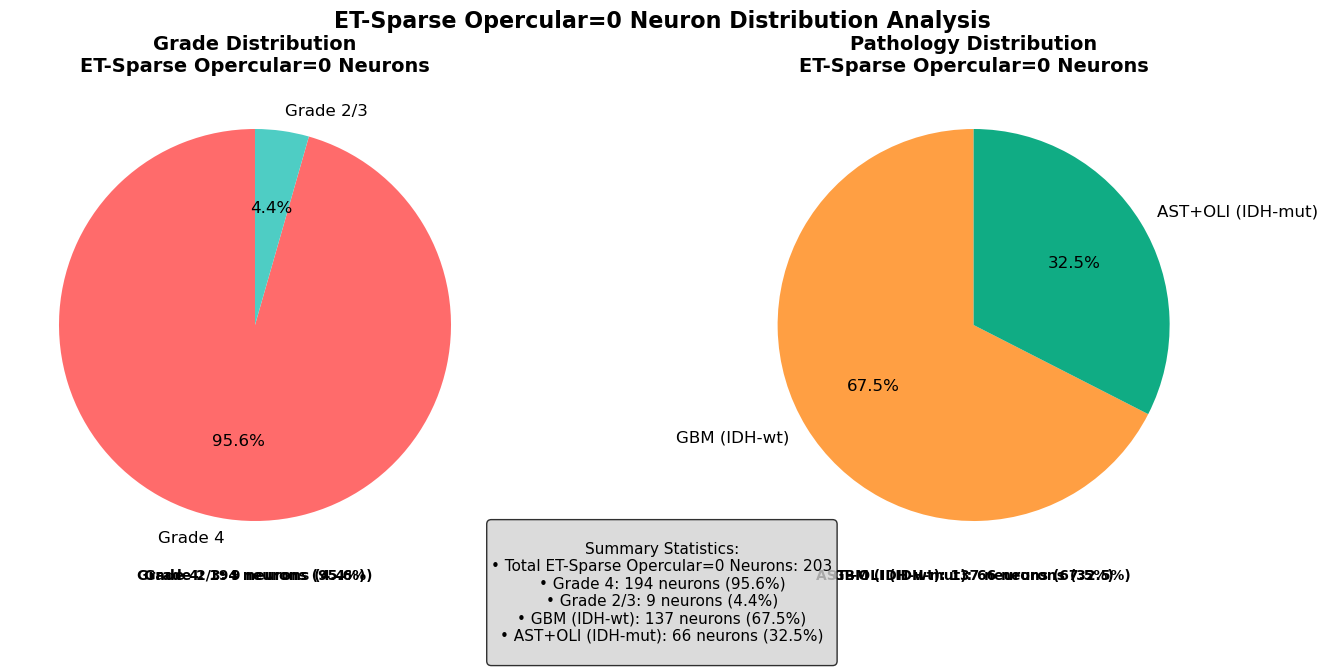


=== DETAILED BREAKDOWN ===
Grade and Pathology combinations in ET-Sparse opercular=0:
  Grade 2 + ast: 9 neurons (4.4%)
  Grade 4 + ast: 57 neurons (28.1%)
  Grade 4 + gbm: 137 neurons (67.5%)

Analysis complete!


In [25]:
# PIE CHART ANALYSIS FOR ET-SPARSE OPERCULAR=0 NEURONS
# Grade distribution and Pathology distribution
plt.rcParams['svg.fonttype'] = 'none' 

import matplotlib.pyplot as plt
import numpy as np

print("=== ET-SPARSE OPERCULAR=0 PIE CHART ANALYSIS ===")

# Filter for ET-Sparse opercular=0 neurons
et_sparse_op0_mask = np.array([
    neuron['opercular'] == 0 
    for neuron in et_sparse_metadata
])

et_sparse_op0_neurons = et_sparse_labels[et_sparse_op0_mask]
et_sparse_op0_metadata = [neuron for neuron in et_sparse_metadata if neuron['opercular'] == 0]

print(f"Total ET-Sparse opercular=0 neurons: {len(et_sparse_op0_neurons)}")

# Count neurons by grade
grade_counts = {}
for neuron in et_sparse_op0_metadata:
    grade = neuron['grade']
    if grade not in grade_counts:
        grade_counts[grade] = 0
    grade_counts[grade] += 1

print(f"\nGrade distribution in ET-Sparse opercular=0:")
for grade in sorted(grade_counts.keys()):
    count = grade_counts[grade]
    percentage = (count / len(et_sparse_op0_neurons)) * 100
    print(f"  Grade {grade}: {count} neurons ({percentage:.1f}%)")

# Count neurons by pathology
pathology_counts = {}
for neuron in et_sparse_op0_metadata:
    pathology = neuron['pathology']
    if pathology not in pathology_counts:
        pathology_counts[pathology] = 0
    pathology_counts[pathology] += 1

print(f"\nPathology distribution in ET-Sparse opercular=0:")
for pathology in sorted(pathology_counts.keys()):
    count = pathology_counts[pathology]
    percentage = (count / len(et_sparse_op0_neurons)) * 100
    print(f"  {pathology}: {count} neurons ({percentage:.1f}%)")

# Create pie charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# 1. Grade distribution pie chart (Grade 4 vs Grade 2/3)
grade4_count = grade_counts.get(4, 0)
grade23_count = grade_counts.get(2, 0) + grade_counts.get(3, 0)

grade_labels = ['Grade 4', 'Grade 2/3']
grade_sizes = [grade4_count, grade23_count]
grade_colors = ['#ff6b6b', '#4ecdc4']  # Red for Grade 4, Teal for Grade 2/3

# Only create pie chart if we have data
if sum(grade_sizes) > 0:
    wedges1, texts1, autotexts1 = ax1.pie(grade_sizes, labels=grade_labels, colors=grade_colors, 
                                          autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
    ax1.set_title('Grade Distribution\nET-Sparse Opercular=0 Neurons', fontsize=14, fontweight='bold')
    
    # Add count information
    for i, (label, size) in enumerate(zip(grade_labels, grade_sizes)):
        if size > 0:
            percentage = (size / sum(grade_sizes)) * 100
            ax1.text(0, -1.3, f'{label}: {size} neurons ({percentage:.1f}%)', 
                    ha='center', fontsize=10, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'No Grade Data Available', ha='center', va='center', fontsize=12)
    ax1.set_title('Grade Distribution\nET-Sparse Opercular=0 Neurons', fontsize=14, fontweight='bold')

# 2. Pathology distribution pie chart (GBM vs AST)
gbm_count = pathology_counts.get('gbm', 0)
ast_count = pathology_counts.get('ast', 0)
oli_count = pathology_counts.get('oli', 0)

# Combine AST and OLI as IDH-mutated
idh_mut_count = ast_count + oli_count

pathology_labels = ['GBM (IDH-wt)', 'AST+OLI (IDH-mut)']
pathology_sizes = [gbm_count, idh_mut_count]
pathology_colors = ['#ff9f43', '#10ac84']  # Orange for GBM, Green for IDH-mut

# Only create pie chart if we have data
if sum(pathology_sizes) > 0:
    wedges2, texts2, autotexts2 = ax2.pie(pathology_sizes, labels=pathology_labels, colors=pathology_colors, 
                                          autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
    ax2.set_title('Pathology Distribution\nET-Sparse Opercular=0 Neurons', fontsize=14, fontweight='bold')
    
    # Add count information
    for i, (label, size) in enumerate(zip(pathology_labels, pathology_sizes)):
        if size > 0:
            percentage = (size / sum(pathology_sizes)) * 100
            ax2.text(0, -1.3, f'{label}: {size} neurons ({percentage:.1f}%)', 
                    ha='center', fontsize=10, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No Pathology Data Available', ha='center', va='center', fontsize=12)
    ax2.set_title('Pathology Distribution\nET-Sparse Opercular=0 Neurons', fontsize=14, fontweight='bold')

# Add overall summary
fig.suptitle('ET-Sparse Opercular=0 Neuron Distribution Analysis', fontsize=16, fontweight='bold', y=0.95)

# Add summary text below the plots
summary_text = f"""
Summary Statistics:
• Total ET-Sparse Opercular=0 Neurons: {len(et_sparse_op0_neurons)}
• Grade 4: {grade4_count} neurons ({(grade4_count/len(et_sparse_op0_neurons)*100):.1f}%)
• Grade 2/3: {grade23_count} neurons ({(grade23_count/len(et_sparse_op0_neurons)*100):.1f}%)
• GBM (IDH-wt): {gbm_count} neurons ({(gbm_count/len(et_sparse_op0_neurons)*100):.1f}%)
• AST+OLI (IDH-mut): {idh_mut_count} neurons ({(idh_mut_count/len(et_sparse_op0_neurons)*100):.1f}%)
"""

fig.text(0.5, 0.02, summary_text, ha='center', va='bottom', fontsize=11, 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.15)
plt.savefig("sparse_flair_grade_path_piecharts.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Print detailed breakdown
print(f"\n=== DETAILED BREAKDOWN ===")
print("Grade and Pathology combinations in ET-Sparse opercular=0:")

grade_pathology_counts = {}
for neuron in et_sparse_op0_metadata:
    grade = neuron['grade']
    pathology = neuron['pathology']
    key = f"Grade {grade} + {pathology}"
    if key not in grade_pathology_counts:
        grade_pathology_counts[key] = 0
    grade_pathology_counts[key] += 1

for key in sorted(grade_pathology_counts.keys()):
    count = grade_pathology_counts[key]
    percentage = (count / len(et_sparse_op0_neurons)) * 100
    print(f"  {key}: {count} neurons ({percentage:.1f}%)")

print(f"\nAnalysis complete!")

In [26]:
# SHOW INSERTIONS THAT CONTRIBUTE TO ET-SPARSE OPERCULAR=0 NEURONS
print("=== INSERTIONS CONTRIBUTING TO ET-SPARSE OPERCULAR=0 NEURONS ===")

# Filter for ET-Sparse opercular=0 neurons
et_sparse_op0_mask = np.array([
    neuron['opercular'] == 0 
    for neuron in et_sparse_metadata
])

et_sparse_op0_neurons = et_sparse_labels[et_sparse_op0_mask]
et_sparse_op0_metadata = [neuron for neuron in et_sparse_metadata if neuron['opercular'] == 0]

print(f"Total ET-Sparse opercular=0 neurons: {len(et_sparse_op0_neurons)}")

# Count neurons by insertion
insertion_counts = {}
insertion_details = {}

for neuron in et_sparse_op0_metadata:
    insertion_idx = neuron['insertion_idx']
    subj = neuron['subj']
    region = neuron['region']
    pathology = neuron['pathology']
    grade = neuron['grade']
    
    if insertion_idx not in insertion_counts:
        insertion_counts[insertion_idx] = 0
        insertion_details[insertion_idx] = {
            'subj': subj,
            'region': region,
            'pathology': pathology,
            'grade': grade,
            'neurons': []
        }
    
    insertion_counts[insertion_idx] += 1
    insertion_details[insertion_idx]['neurons'].append({
        'pathology': pathology,
        'grade': grade
    })

print(f"\nInsertions contributing to ET-Sparse opercular=0 neurons:")
print(f"{'Insertion':<12} {'Subject':<8} {'Region':<10} {'Count':<6} {'Percentage':<10} {'Details'}")
print("-" * 80)

total_neurons = len(et_sparse_op0_neurons)
for insertion_idx in sorted(insertion_counts.keys()):
    count = insertion_counts[insertion_idx]
    percentage = (count / total_neurons) * 100
    details = insertion_details[insertion_idx]
    
    # Get unique pathology/grade combinations for this insertion
    unique_combinations = set()
    for neuron in details['neurons']:
        unique_combinations.add(f"{neuron['pathology']}-G{neuron['grade']}")
    
    combinations_str = ", ".join(sorted(unique_combinations))
    
    print(f"{insertion_idx:<12} {details['subj']:<8} {details['region']:<10} {count:<6} {percentage:<9.1f}% {combinations_str}")

# Show summary by subject
print(f"\n=== SUMMARY BY SUBJECT ===")
subject_counts = {}
for neuron in et_sparse_op0_metadata:
    subj = neuron['subj']
    if subj not in subject_counts:
        subject_counts[subj] = 0
    subject_counts[subj] += 1

print(f"{'Subject':<8} {'Count':<6} {'Percentage':<10}")
print("-" * 30)
for subj in sorted(subject_counts.keys()):
    count = subject_counts[subj]
    percentage = (count / total_neurons) * 100
    print(f"{subj:<8} {count:<6} {percentage:<9.1f}%")

# Show summary by region
print(f"\n=== SUMMARY BY REGION ===")
region_counts = {}
for neuron in et_sparse_op0_metadata:
    region = neuron['region']
    if region not in region_counts:
        region_counts[region] = 0
    region_counts[region] += 1

print(f"{'Region':<12} {'Count':<6} {'Percentage':<10}")
print("-" * 35)
for region in sorted(region_counts.keys()):
    count = region_counts[region]
    percentage = (count / total_neurons) * 100
    print(f"{region:<12} {count:<6} {percentage:<9.1f}%")

# Show which insertions have the most neurons
print(f"\n=== TOP 5 INSERTIONS BY NEURON COUNT ===")
sorted_insertions = sorted(insertion_counts.items(), key=lambda x: x[1], reverse=True)
for i, (insertion_idx, count) in enumerate(sorted_insertions[:5]):
    percentage = (count / total_neurons) * 100
    details = insertion_details[insertion_idx]
    print(f"{i+1}. Insertion {insertion_idx} (Subject {details['subj']}, {details['region']}): {count} neurons ({percentage:.1f}%)")

print(f"\nAnalysis complete!")

=== INSERTIONS CONTRIBUTING TO ET-SPARSE OPERCULAR=0 NEURONS ===
Total ET-Sparse opercular=0 neurons: 203

Insertions contributing to ET-Sparse opercular=0 neurons:
Insertion    Subject  Region     Count  Percentage Details
--------------------------------------------------------------------------------
1            2        SFG        57     28.1     % ast-G4
2            3        aSTG       20     9.9      % gbm-G4
7            6        pSTG       49     24.1     % gbm-G4
10           9        aSTG       9      4.4      % ast-G2
13           13       pSTG       31     15.3     % gbm-G4
20           18       SMG        37     18.2     % gbm-G4

=== SUMMARY BY SUBJECT ===
Subject  Count  Percentage
------------------------------
2        57     28.1     %
3        20     9.9      %
6        49     24.1     %
9        9      4.4      %
13       31     15.3     %
18       37     18.2     %

=== SUMMARY BY REGION ===
Region       Count  Percentage
-----------------------------------
SFG  

In [27]:
# LOOP THROUGH ET-SPARSE OPERCULAR=0 INSERTIONS FOR E/I BALANCE ANALYSIS
# WITH BOTH ASSEMBLY AND NEURON INFORMATION CAPACITY ANALYSIS
import fnmatch
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import re
import os
from scipy import stats
from sklearn.decomposition import PCA, FastICA
from scipy.linalg import norm
from scipy.stats import kstest

def imec_key_sorter(key):
    """Extract the number after 'imec', default to a large number if not found."""
    match = re.search(r'imec(\d+)', key)
    return int(match.group(1)) if match else float('inf')

def calculate_mutual_information(x, y, bins=20):
    """
    Calculate mutual information between two variables using histogram-based approach.
    """
    valid_mask = ~(np.isnan(x) | np.isnan(y))
    if np.sum(valid_mask) < 2:
        return np.nan

    x_valid = x[valid_mask]
    y_valid = y[valid_mask]

    hist_2d, _, _ = np.histogram2d(x_valid, y_valid, bins=bins)
    hist_x = np.sum(hist_2d, axis=1)
    hist_y = np.sum(hist_2d, axis=0)

    p_xy = hist_2d / np.sum(hist_2d)
    p_x = hist_x / np.sum(hist_x)
    p_y = hist_y / np.sum(hist_y)

    mi = 0.0
    for i in range(len(p_x)):
        for j in range(len(p_y)):
            if p_xy[i, j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                mi += p_xy[i, j] * np.log2(p_xy[i, j] / (p_x[i] * p_y[j]))
    return mi

def calculate_information_capacity(data, time_bins, min_samples=10):
    """
    Calculate information storage capacity using multiple metrics.
    """
    valid_mask = ~np.isnan(data)
    if np.sum(valid_mask) < min_samples:
        return {
            'entropy': np.nan,
            'mutual_info_temporal': np.nan,
            'capacity': np.nan,
            'n_valid_samples': np.sum(valid_mask),
            'data_range': np.nan,
            'data_std': np.nan
        }

    valid_data = data[valid_mask]

    n_bins = min(20, len(valid_data) // 5)
    if n_bins < 5:
        n_bins = 5

    hist, _ = np.histogram(valid_data, bins=n_bins)
    prob = hist / np.sum(hist)
    prob = prob[prob > 0]

    if len(prob) < 2:
        entropy_val = np.nan
    else:
        entropy_val = -np.sum(prob * np.log2(prob))

    if len(valid_data) > 1:
        try:
            mi_temporal = calculate_mutual_information(
                valid_data[:-1],
                valid_data[1:],
                bins=min(10, len(valid_data) // 10)
            )
        except Exception:
            mi_temporal = np.nan
    else:
        mi_temporal = np.nan

    if not np.isnan(entropy_val) and not np.isnan(mi_temporal):
        capacity = entropy_val - mi_temporal
    elif not np.isnan(entropy_val):
        capacity = entropy_val
    else:
        capacity = np.nan

    data_range = np.max(valid_data) - np.min(valid_data) if len(valid_data) > 0 else np.nan
    data_std = np.std(valid_data) if len(valid_data) > 0 else np.nan

    return {
        'entropy': entropy_val,
        'mutual_info_temporal': mi_temporal,
        'capacity': capacity,
        'n_valid_samples': np.sum(valid_mask),
        'data_range': data_range,
        'data_std': data_std
    }

def calculate_expression_strength(firingRateMatrix, ap_norm_matrix):
    """
    Calculate expression strength using the method from the paper:
    E(b) = R(b)^T * Oi * R(b)
    """
    n_time_bins, n_neurons = firingRateMatrix.shape
    n_assemblies = ap_norm_matrix.shape[0]
    
    expression_strength = np.zeros((n_time_bins, n_assemblies))
    
    for assembly_idx in range(n_assemblies):
        weight_vector = ap_norm_matrix[assembly_idx, :]
        outer_product = np.outer(weight_vector, weight_vector)
        
        for time_bin in range(n_time_bins):
            firing_rate_vector = firingRateMatrix[time_bin, :]
            expression_strength[time_bin, assembly_idx] = firing_rate_vector.T @ outer_product @ firing_rate_vector
    
    return expression_strength

def calculate_ei_balance(assembly_pattern, cluster_labels):
    """
    Calculate E/I balance for an assembly pattern.
    Multiply by -1 for cluster 1, 0 for cluster 2, +1 for cluster 0.
    """
    ei_balance = 0.0
    for neuron_idx, weight in enumerate(assembly_pattern):
        cluster_id = cluster_labels[neuron_idx]
        if cluster_id == 0:  # Excitatory
            ei_balance += weight * 1
        elif cluster_id == 1:  # Inhibitory
            ei_balance += weight * (-1)
        elif cluster_id == 2:  # Other/Unknown
            ei_balance += weight * 0
    
    return ei_balance 

# Get ET-Sparse opercular=0 insertions
et_sparse_op0_mask = np.array([
    neuron['opercular'] == 0 
    for neuron in et_sparse_metadata
])

et_sparse_op0_neurons = et_sparse_labels[et_sparse_op0_mask]
et_sparse_op0_metadata = [neuron for neuron in et_sparse_metadata if neuron['opercular'] == 0]

# Get unique insertion indices for ET-Sparse opercular=0
et_sparse_op0_insertions = set()
for neuron in et_sparse_op0_metadata:
    et_sparse_op0_insertions.add(neuron['insertion_idx'])

print(f"ET-Sparse opercular=0 insertions: {sorted(et_sparse_op0_insertions)}")
print(f"Total insertions to process: {len(et_sparse_op0_insertions)}")

# Create mapping from nwb_paths index to actual insertion index
# Use the same logic as the original data loading to ensure consistency
nwb_to_insertion_map = {}
insertion_counter = 0

for i in range(len(nwb_paths)):
    data = nap.load_file(nwb_paths[i])
    keys = data.keys()

    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    # For NP137, remove 'imec1'
    if 'NP137' in str(nwb_paths[i]) or 'NP139_B2' in str(nwb_paths[i]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)

    for s in range(len(keys)):
        nwb_to_insertion_map[(i, s)] = insertion_counter
        insertion_counter += 1

print(f"NWB to insertion mapping created. Total insertions mapped: {insertion_counter}")

# Debug: Print the mapping to see what's happening
print(f"\nDebug: NWB to insertion mapping:")
for (i, s), insertion_idx in nwb_to_insertion_map.items():
    if insertion_idx in et_sparse_op0_insertions:
        print(f"  NWB[{i}], Session[{s}] -> Insertion {insertion_idx}")

# Storage for results
assembly_results = []
neuron_results = []
insertion_results = []

# Process each insertion
for i in range(len(nwb_paths)):
    data = nap.load_file(nwb_paths[i])
    keys = data.keys()

    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    # For NP137, remove 'imec1'
    if 'NP137' in str(nwb_paths[i]) or 'NP139_B2' in str(nwb_paths[i]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)

    for s in range(len(keys)):
        # Get the correct insertion index using our mapping
        insertion_idx = nwb_to_insertion_map[(i, s)]
        
        # Skip if this insertion is not in ET-Sparse opercular=0
        if insertion_idx not in et_sparse_op0_insertions:
            continue
            
        print(f"\nProcessing insertion {insertion_idx}: {keys[s]}")
        print(f"Region = {region_list[insertion_idx]}")
        print(f"Subject = {subj_list[insertion_idx]}")

        spike_times = data[keys[s]]

        firingRates_all = spike_times.metadata["rate"]
        task_times = data["TaskTimes"]
        beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)
        spike_times_beh = spike_times.restrict(beh_epochs)
        firingRates_beh = spike_times_beh.metadata["rate"]

        start_time = task_times.start
        end_time = task_times.end
        ks_stats = np.zeros(len(spike_times))
        ks_pvals = np.zeros(len(spike_times))
        for u in range(len(spike_times)):
            test = spike_times[u].as_series().index.values
            if len(test) > 1:
                min_time = start_time[0]
                max_time = end_time[-1]
                normalized_spike_times = (test - min_time) / (max_time - min_time)
                ks_result = kstest(normalized_spike_times, 'uniform')
                ks_stats[u] = ks_result.statistic
                ks_pvals[u] = ks_result.pvalue
            else:
                ks_stats[u] = np.nan
                ks_pvals[u] = np.nan

        violationThreshold = 3 / 1000
        violationPct = np.zeros(len(spike_times))
        for u in range(len(spike_times)):
            unit = spike_times[u]
            unit = unit.as_series().index
            if len(unit) < 100:
                violationPct[u] = 1
            else:
                isi = unit.diff()[1:]
                violations = np.where(isi < violationThreshold)
                violations = np.array(violations)
                violationPct[u] = violations.size / len(isi)

        if "KSLabel" in spike_times.metadata:
            KSLabels = spike_times.metadata["KSLabel"]
        else:
            KSLabels = spike_times.metadata["quality"]
        firingRates = firingRates_beh
        mask1 = violationPct < 3 / 100
        mask2 = firingRates > 0.5
        mask3 = KSLabels != "noise"
        mask4 = ks_stats < 0.3
        mask = mask1 & mask2 & mask3 & mask4
        indicesFinal = firingRates.index[mask]
        # now exclude neurons manually rejected
        indicesFinal = np.setdiff1d(indicesFinal, manual_exclude_lists[insertion_idx])
        spike_times_good = spike_times[indicesFinal]
        print(f"Number of good neurons: {len(spike_times_good)}")

        if len(spike_times_good) == 0:
            print("No good neurons found, skipping insertion")
            continue

        # CORRECTED: Get cluster labels for this insertion's neurons
        insertion_cluster_labels = []
        insertion_metadata = []

        # Get all neurons for this insertion from the global ET-Sparse data
        insertion_neurons = []
        for global_idx, global_neuron in enumerate(et_sparse_metadata):
            if (global_neuron['insertion_idx'] == insertion_idx and 
                global_neuron['opercular'] == 0):
                insertion_neurons.append((global_idx, global_neuron))
        
        print(f"Found {len(insertion_neurons)} neurons in global data for insertion {insertion_idx}")
        
        # Now match by sequential position, not by actual neuron index
        for local_neuron_idx, neuron_idx in enumerate(indicesFinal):
            # Use the sequential position (local_neuron_idx) to find the corresponding global neuron
            if local_neuron_idx < len(insertion_neurons):
                global_idx, global_neuron = insertion_neurons[local_neuron_idx]
                cluster_label = et_sparse_labels[global_idx]
                insertion_cluster_labels.append(cluster_label)
                insertion_metadata.append(global_neuron)
            else:
                print(f"Warning: Not enough global neurons for local position {local_neuron_idx}")
                insertion_cluster_labels.append(-1)  # Unknown cluster
                insertion_metadata.append({})

        insertion_cluster_labels = np.array(insertion_cluster_labels)
        
        # Debug: Print cluster distribution for this insertion
        cluster_counts = [0, 0, 0]
        for label in insertion_cluster_labels:
            if 0 <= label <= 2:
                cluster_counts[label] += 1
        
        total_neurons = sum(cluster_counts)
        cluster_props = [count/total_neurons if total_neurons > 0 else 0 for count in cluster_counts]
        
        print(f"Cluster distribution for insertion {insertion_idx}:")
        print(f"  Cluster 0: {cluster_counts[0]} ({cluster_props[0]:.3f})")
        print(f"  Cluster 1: {cluster_counts[1]} ({cluster_props[1]:.3f})")
        print(f"  Cluster 2: {cluster_counts[2]} ({cluster_props[2]:.3f})")
        print(f"  Total: {total_neurons} neurons")

        timescale = 25 / 1000
        spikeCountMatrix = spike_times_good.count(bin_size=timescale)
        bin_edges = spikeCountMatrix.index.values
        bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2
        if len(bin_centers) < len(bin_edges):
            last_width = bin_edges[-1] - bin_edges[-2] if len(bin_edges) > 1 else 0
            last_center = bin_edges[-1] - last_width / 2
            bin_centers = np.append(bin_centers, last_center)
        spikeCountMatrix = spikeCountMatrix.values
        firingRateMatrix = spikeCountMatrix / timescale
        firingRateMatrix = stats.zscore(firingRateMatrix, axis=0)

        pca = PCA()
        firingRateMatrix_pca = pca.fit_transform(firingRateMatrix)
        eigenvalues = pca.explained_variance_
        upperbound = (1 + np.sqrt(firingRateMatrix.shape[1] / firingRateMatrix.shape[0])) ** 2
        assemblyIndices = np.where(eigenvalues > upperbound)
        assemblyEigenvalues = eigenvalues[assemblyIndices]
        print(f"Number of assembly patterns: {len(assemblyEigenvalues)}")

        n_pcs = len(assemblyEigenvalues)
        pc_vectors = pca.components_[:n_pcs, :]

        projections = firingRateMatrix @ pc_vectors.T

        if n_pcs > 0:
            fastica = FastICA(
                n_components=n_pcs,
                algorithm='parallel',
                whiten='unit-variance',
                max_iter=500,
                tol=1e-7,
                random_state=1
            )
            ica_components = fastica.fit_transform(projections)
            mixing_matrix = fastica.mixing_
            unmixing_matrix = fastica.components_
            ica_assembly_patterns = unmixing_matrix @ pc_vectors

            ap_norm_matrix = ica_assembly_patterns
            ap_norm_member = np.zeros(ica_assembly_patterns.shape)
            for ii in range(n_pcs):
                ap = ica_assembly_patterns[ii, :]
                ap_norm = ap / norm(ap)
                maxW = np.max(ap_norm)
                minW = np.min(ap_norm)
                if abs(minW) > maxW:
                    ap_norm = ap_norm * -1
                ap_norm_matrix[ii, :] = ap_norm
                threshold = np.mean(ap_norm) + np.std(ap_norm) * 2
                for c in range(len(ap)):
                    if ap_norm[c] > threshold:
                        ap_norm_member[ii, c] = 1

            sparsity_list = []
            for ap in range(len(ap_norm_matrix)):
                w = np.array(ap_norm_matrix[ap, :])
                n = w.size
                numerator = np.sqrt(n) - np.sum(np.abs(w))
                denominator = np.sqrt(n) - 1
                sparsity = 1 - numerator / denominator if denominator != 0 else np.nan
                sparsity_list.append(sparsity)

            # --- ASSEMBLY INFORMATION CAPACITY ANALYSIS ---
            insertion_assembly_results = []
            
            for assembly_idx in range(n_pcs):
                print(f"Analyzing assembly {assembly_idx + 1} of {n_pcs}")
                assembly_pattern = ap_norm_matrix[assembly_idx, :]
                assembly_members = ap_norm_member[assembly_idx, :]
                
                # Calculate E/I balance
                ei_balance = calculate_ei_balance(assembly_pattern, insertion_cluster_labels)
                
                # Calculate information capacity
                assembly_expression = ica_components[:, assembly_idx]
                assembly_info_capacity = calculate_information_capacity(assembly_expression, bin_centers)
                
                # Store detailed neuron information
                neuron_details = []
                for neuron_idx in range(len(assembly_pattern)):
                    # Handle case where metadata might be empty
                    if neuron_idx < len(insertion_metadata) and insertion_metadata[neuron_idx]:
                        depth = insertion_metadata[neuron_idx].get('depth', 0.0)
                        metadata = insertion_metadata[neuron_idx]
                    else:
                        depth = 0.0
                        metadata = {}
                    
                    neuron_details.append({
                        'neuron_idx': neuron_idx,
                        'assembly_weight': assembly_pattern[neuron_idx],
                        'is_member': bool(assembly_members[neuron_idx]),
                        'cluster_label': insertion_cluster_labels[neuron_idx],
                        'depth': depth,
                        'metadata': metadata
                    })
                
                assembly_result = {
                    'insertion_idx': insertion_idx,
                    'assembly_idx': assembly_idx,
                    'ei_balance': ei_balance,
                    'information_capacity': assembly_info_capacity,
                    'sparsity': sparsity_list[assembly_idx],
                    'n_neurons': len(assembly_pattern),
                    'n_members': np.sum(assembly_members),
                    'neuron_details': neuron_details
                }
                
                insertion_assembly_results.append(assembly_result)
                assembly_results.append(assembly_result)
            
            # --- NEURON INFORMATION CAPACITY ANALYSIS ---
            insertion_neuron_results = []
            
            for neuron_idx in range(firingRateMatrix.shape[1]):
                neuron_activity = firingRateMatrix[:, neuron_idx]
                neuron_info_capacity = calculate_information_capacity(neuron_activity, bin_centers)
                
                # Handle case where metadata might be empty
                if neuron_idx < len(insertion_metadata) and insertion_metadata[neuron_idx]:
                    depth = insertion_metadata[neuron_idx].get('depth', 0.0)
                    metadata = insertion_metadata[neuron_idx]
                else:
                    depth = 0.0
                    metadata = {}
                
                neuron_result = {
                    'insertion_idx': insertion_idx,
                    'neuron_idx': neuron_idx,
                    'cluster_label': insertion_cluster_labels[neuron_idx],
                    'depth': depth,
                    'information_capacity': neuron_info_capacity,
                    'metadata': metadata
                }
                
                insertion_neuron_results.append(neuron_result)
                neuron_results.append(neuron_result)
            
            insertion_result = {
                'insertion_idx': insertion_idx,
                'nwb_path': str(nwb_paths[i]),
                'session_key': keys[s],
                'region': region_list[insertion_idx],
                'subject': subj_list[insertion_idx],
                'pathology': path_list[insertion_idx],
                'grade': grade_list[insertion_idx],
                'n_neurons': len(spike_times_good),
                'n_assemblies': n_pcs,
                'assemblies': insertion_assembly_results,
                'neurons': insertion_neuron_results
            }
            
            insertion_results.append(insertion_result)
            
            print(f"Processed {n_pcs} assemblies and {len(spike_times_good)} neurons for insertion {insertion_idx}")
        else:
            print(f"No assemblies found for insertion {insertion_idx}")

print(f"\nAnalysis complete!")
print(f"Total insertions processed: {len(insertion_results)}")
print(f"Total assemblies analyzed: {len(assembly_results)}")
print(f"Total neurons analyzed: {len(neuron_results)}")

# Print summary
print(f"\n=== SUMMARY ===")
for result in insertion_results:
    print(f"Insertion {result['insertion_idx']}: {result['n_assemblies']} assemblies, "
          f"{result['n_neurons']} neurons, {result['region']}, {result['pathology']}-G{result['grade']}")

# Print E/I balance summary
print(f"\n=== E/I BALANCE SUMMARY ===")
ei_balances = [assembly['ei_balance'] for assembly in assembly_results]
info_capacities_assembly = [assembly['information_capacity']['capacity'] for assembly in assembly_results if not np.isnan(assembly['information_capacity']['capacity'])]

print(f"Assembly E/I Balance: mean = {np.mean(ei_balances):.3f}, std = {np.std(ei_balances):.3f}")
print(f"Assembly Information Capacity: mean = {np.mean(info_capacities_assembly):.3f}, std = {np.std(info_capacities_assembly):.3f}")

# Print neuron information capacity summary
print(f"\n=== NEURON INFORMATION CAPACITY SUMMARY ===")
info_capacities_neuron = [neuron['information_capacity']['capacity'] for neuron in neuron_results if not np.isnan(neuron['information_capacity']['capacity'])]

print(f"Neuron Information Capacity: mean = {np.mean(info_capacities_neuron):.3f}, std = {np.std(info_capacities_neuron):.3f}")

# Print cluster-specific neuron information capacity
print(f"\n=== NEURON INFORMATION CAPACITY BY CLUSTER ===")
for cluster_id in range(3):
    cluster_neurons = [neuron for neuron in neuron_results if neuron['cluster_label'] == cluster_id]
    cluster_capacities = [neuron['information_capacity']['capacity'] for neuron in cluster_neurons if not np.isnan(neuron['information_capacity']['capacity'])]
    
    if len(cluster_capacities) > 0:
        print(f"Cluster {cluster_id}: mean = {np.mean(cluster_capacities):.3f}, std = {np.std(cluster_capacities):.3f}, n = {len(cluster_capacities)}")
    else:
        print(f"Cluster {cluster_id}: no valid data")

ET-Sparse opercular=0 insertions: [1, 2, 7, 10, 13, 20]
Total insertions to process: 6
NWB to insertion mapping created. Total insertions mapped: 24

Debug: NWB to insertion mapping:
  NWB[1], Session[0] -> Insertion 1
  NWB[2], Session[0] -> Insertion 2
  NWB[5], Session[0] -> Insertion 7
  NWB[8], Session[0] -> Insertion 10
  NWB[10], Session[0] -> Insertion 13
  NWB[15], Session[0] -> Insertion 20

Processing insertion 1: NP95_B1_g0_imec1
Region = SFG
Subject = 2
Number of good neurons: 57
Found 57 neurons in global data for insertion 1
Cluster distribution for insertion 1:
  Cluster 0: 9 (0.158)
  Cluster 1: 26 (0.456)
  Cluster 2: 22 (0.386)
  Total: 57 neurons
Number of assembly patterns: 11
Analyzing assembly 1 of 11
Analyzing assembly 2 of 11
Analyzing assembly 3 of 11
Analyzing assembly 4 of 11
Analyzing assembly 5 of 11
Analyzing assembly 6 of 11
Analyzing assembly 7 of 11
Analyzing assembly 8 of 11
Analyzing assembly 9 of 11
Analyzing assembly 10 of 11
Analyzing assembly 11 

=== NEURON INFORMATION CAPACITY BY CLUSTER ===

Kruskal-Wallis test: H = 22.148, p = 0.0000
Cluster 0 vs Cluster 1:
  T-test: t = 1.806, p = 0.0729
  Mann-Whitney U: U = 3334.000, p = 0.1513
Cluster 0 vs Cluster 2:
  T-test: t = -4.901, p = 0.0000
  Mann-Whitney U: U = 1304.000, p = 0.0002
Cluster 1 vs Cluster 2:
  T-test: t = -5.790, p = 0.0000
  Mann-Whitney U: U = 812.000, p = 0.0000


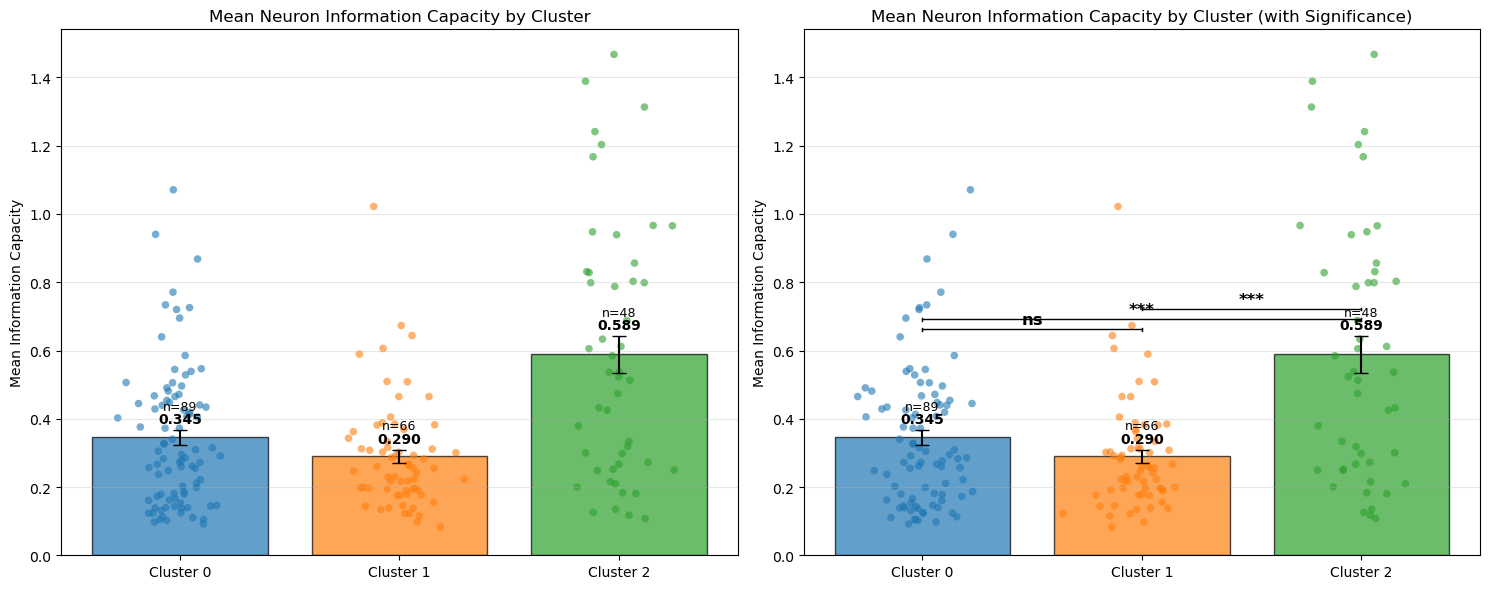


=== DETAILED CLUSTER STATISTICS ===
Cluster 0:
  n = 89
  Mean = 0.345
  Median = 0.295
  Std = 0.206
  SEM = 0.022
  Range = 0.092 - 1.071
  IQR = 0.282

Cluster 1:
  n = 66
  Mean = 0.290
  Median = 0.255
  Std = 0.160
  SEM = 0.020
  Range = 0.083 - 1.022
  IQR = 0.149

Cluster 2:
  n = 48
  Mean = 0.589
  Median = 0.530
  Std = 0.371
  SEM = 0.054
  Range = 0.108 - 1.468
  IQR = 0.566

=== EFFECT SIZES (COHEN'S D) ===
Cluster 0 vs Cluster 1: Cohen's d = 0.293
Cluster 0 vs Cluster 2: Cohen's d = -0.878
Cluster 1 vs Cluster 2: Cohen's d = -1.098

Plot complete!


In [28]:
# NEURON INFORMATION CAPACITY ANALYSIS BY CLUSTER WITH SIGNIFICANCE TESTING
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Plot neuron information capacity by cluster
print("=== NEURON INFORMATION CAPACITY BY CLUSTER ===")

# Extract information capacity data
info_capacities = []
cluster_labels = []
for neuron in neuron_results:
    if not np.isnan(neuron['information_capacity']['capacity']):
        info_capacities.append(neuron['information_capacity']['capacity'])
        cluster_labels.append(neuron['cluster_label'])

info_capacities = np.array(info_capacities)
cluster_labels = np.array(cluster_labels)

# Create plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Prepare cluster data
cluster_data = [info_capacities[cluster_labels == i] for i in range(3)]
cluster_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# Plot 1: Bar plot with individual data points
cluster_means = [np.mean(data) for data in cluster_data]
cluster_sems = [stats.sem(data) for data in cluster_data]

bars = ax1.bar(range(3), cluster_means, yerr=cluster_sems, 
               color=cluster_colors, alpha=0.7, capsize=5, edgecolor='black')

ax1.set_title('Mean Neuron Information Capacity by Cluster')
ax1.set_ylabel('Mean Information Capacity')
ax1.set_xticks(range(3))
ax1.set_xticklabels([f'Cluster {i}' for i in range(3)])
ax1.grid(axis='y', alpha=0.3)

# Add individual data points
for i, data in enumerate(cluster_data):
    # Add jitter to x-coordinates to spread points
    x_jitter = np.random.normal(i, 0.1, len(data))
    ax1.scatter(x_jitter, data, alpha=0.6, color=cluster_colors[i], 
                s=30, edgecolors='none')  # No borders

# Add value labels on bars
for i, (bar, mean, sem) in enumerate(zip(bars, cluster_means, cluster_sems)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sem + 0.01, 
             f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sem + 0.05, 
             f'n={len(cluster_data[i])}', ha='center', va='bottom', fontsize=9)

# Plot 2: Bar plot with significance annotations
bars2 = ax2.bar(range(3), cluster_means, yerr=cluster_sems, 
                color=cluster_colors, alpha=0.7, capsize=5, edgecolor='black')

ax2.set_title('Mean Neuron Information Capacity by Cluster (with Significance)')
ax2.set_ylabel('Mean Information Capacity')
ax2.set_xticks(range(3))
ax2.set_xticklabels([f'Cluster {i}' for i in range(3)])
ax2.grid(axis='y', alpha=0.3)

# Add individual data points
for i, data in enumerate(cluster_data):
    # Add jitter to x-coordinates to spread points
    x_jitter = np.random.normal(i, 0.1, len(data))
    ax2.scatter(x_jitter, data, alpha=0.6, color=cluster_colors[i], 
                s=30, edgecolors='none')  # No borders

# Add value labels on bars
for i, (bar, mean, sem) in enumerate(zip(bars2, cluster_means, cluster_sems)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sem + 0.01, 
             f'{mean:.3f}', ha='center', va='bottom', fontweight='bold')
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sem + 0.05, 
             f'n={len(cluster_data[i])}', ha='center', va='bottom', fontsize=9)

# Add significance annotations
y_max = max([mean + sem for mean, sem in zip(cluster_means, cluster_sems)])
y_range = y_max - min([mean - sem for mean, sem in zip(cluster_means, cluster_sems)])

# Perform pairwise comparisons
from scipy.stats import ttest_ind, mannwhitneyu
from scipy.stats import kruskal

# Overall Kruskal-Wallis test
kw_stat, kw_p = kruskal(*cluster_data)
print(f"\nKruskal-Wallis test: H = {kw_stat:.3f}, p = {kw_p:.4f}")

# Pairwise comparisons
pairwise_results = []
for i in range(3):
    for j in range(i+1, 3):
        data_i = cluster_data[i]
        data_j = cluster_data[j]
        
        # T-test
        t_stat, t_p = ttest_ind(data_i, data_j)
        
        # Mann-Whitney U test
        u_stat, u_p = mannwhitneyu(data_i, data_j, alternative='two-sided')
        
        pairwise_results.append({
            'clusters': (i, j),
            't_stat': t_stat,
            't_p': t_p,
            'u_stat': u_stat,
            'u_p': u_p
        })
        
        print(f"Cluster {i} vs Cluster {j}:")
        print(f"  T-test: t = {t_stat:.3f}, p = {t_p:.4f}")
        print(f"  Mann-Whitney U: U = {u_stat:.3f}, p = {u_p:.4f}")

# Add significance lines and annotations
def get_significance_symbol(p_value):
    if p_value < 0.001:
        return "***"
    elif p_value < 0.01:
        return "**"
    elif p_value < 0.05:
        return "*"
    else:
        return "ns"

# Add significance annotations between bars
y_pos = y_max + 0.05 * y_range
line_height = 0.02 * y_range

for i, result in enumerate(pairwise_results):
    cluster1, cluster2 = result['clusters']
    p_value = result['t_p']  # Use t-test p-value
    symbol = get_significance_symbol(p_value)
    
    # Draw line between bars
    ax2.plot([cluster1, cluster2], [y_pos, y_pos], 'k-', linewidth=1)
    ax2.plot([cluster1, cluster1], [y_pos - line_height/2, y_pos + line_height/2], 'k-', linewidth=1)
    ax2.plot([cluster2, cluster2], [y_pos - line_height/2, y_pos + line_height/2], 'k-', linewidth=1)
    
    # Add significance symbol
    ax2.text((cluster1 + cluster2) / 2, y_pos + line_height, symbol, 
             ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # Move up for next comparison
    y_pos += 0.08 * y_range

plt.tight_layout()
plt.savefig("neuron_info_capacity_by_cluster.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics
print(f"\n=== DETAILED CLUSTER STATISTICS ===")
for i in range(3):
    data = cluster_data[i]
    print(f"Cluster {i}:")
    print(f"  n = {len(data)}")
    print(f"  Mean = {np.mean(data):.3f}")
    print(f"  Median = {np.median(data):.3f}")
    print(f"  Std = {np.std(data):.3f}")
    print(f"  SEM = {stats.sem(data):.3f}")
    print(f"  Range = {np.min(data):.3f} - {np.max(data):.3f}")
    print(f"  IQR = {np.percentile(data, 75) - np.percentile(data, 25):.3f}")
    print()

# Print effect sizes
print(f"=== EFFECT SIZES (COHEN'S D) ===")
for i in range(3):
    for j in range(i+1, 3):
        data_i = cluster_data[i]
        data_j = cluster_data[j]
        
        # Calculate Cohen's d
        pooled_std = np.sqrt(((len(data_i) - 1) * np.var(data_i, ddof=1) + 
                             (len(data_j) - 1) * np.var(data_j, ddof=1)) / 
                            (len(data_i) + len(data_j) - 2))
        cohens_d = (np.mean(data_i) - np.mean(data_j)) / pooled_std
        
        print(f"Cluster {i} vs Cluster {j}: Cohen's d = {cohens_d:.3f}")

print("\nPlot complete!")

=== ENHANCED SIGNIFICANCE TESTING WITH IDH MUTATION STATUS AND COMPONENT INFORMATION ===
=== GRADE 4 NEURONS ONLY ===
Sample size: 33 assemblies
IDH-mutated (ast+oli): 11 assemblies
IDH-wildtype (gbm): 22 assemblies

=== IDH LABELING VERIFICATION ===
IDH Status breakdown:
  IDH-mut: 11 assemblies, avg info capacity: 2.504
  IDH-wt: 22 assemblies, avg info capacity: 2.072

=== MULTIPLE REGRESSION MODEL ===
R² = 0.506
Coefficients:
  excitatory_ratio: -0.266
  inhibitory_ratio: -0.255
  axonal_ratio: 0.104
  component_information: 0.098
  idh_mutated: 0.066

=== PERMUTATION TEST FOR MODEL SIGNIFICANCE ===
Original R² = 0.506
Permuted R² = 0.158 ± 0.086
p-value = 0.001
Model is significant

=== MULTICOLLINEARITY ANALYSIS ===
excitatory_ratio: VIF = 1.66
inhibitory_ratio: VIF = 1.23
axonal_ratio: VIF = 1.72
component_information: VIF = 1.54
idh_mutated: VIF = 1.32

=== INDIVIDUAL CORRELATIONS ===
excitatory_ratio: r = -0.425, p = 0.014
inhibitory_ratio: r = -0.319, p = 0.070
axonal_ratio: 

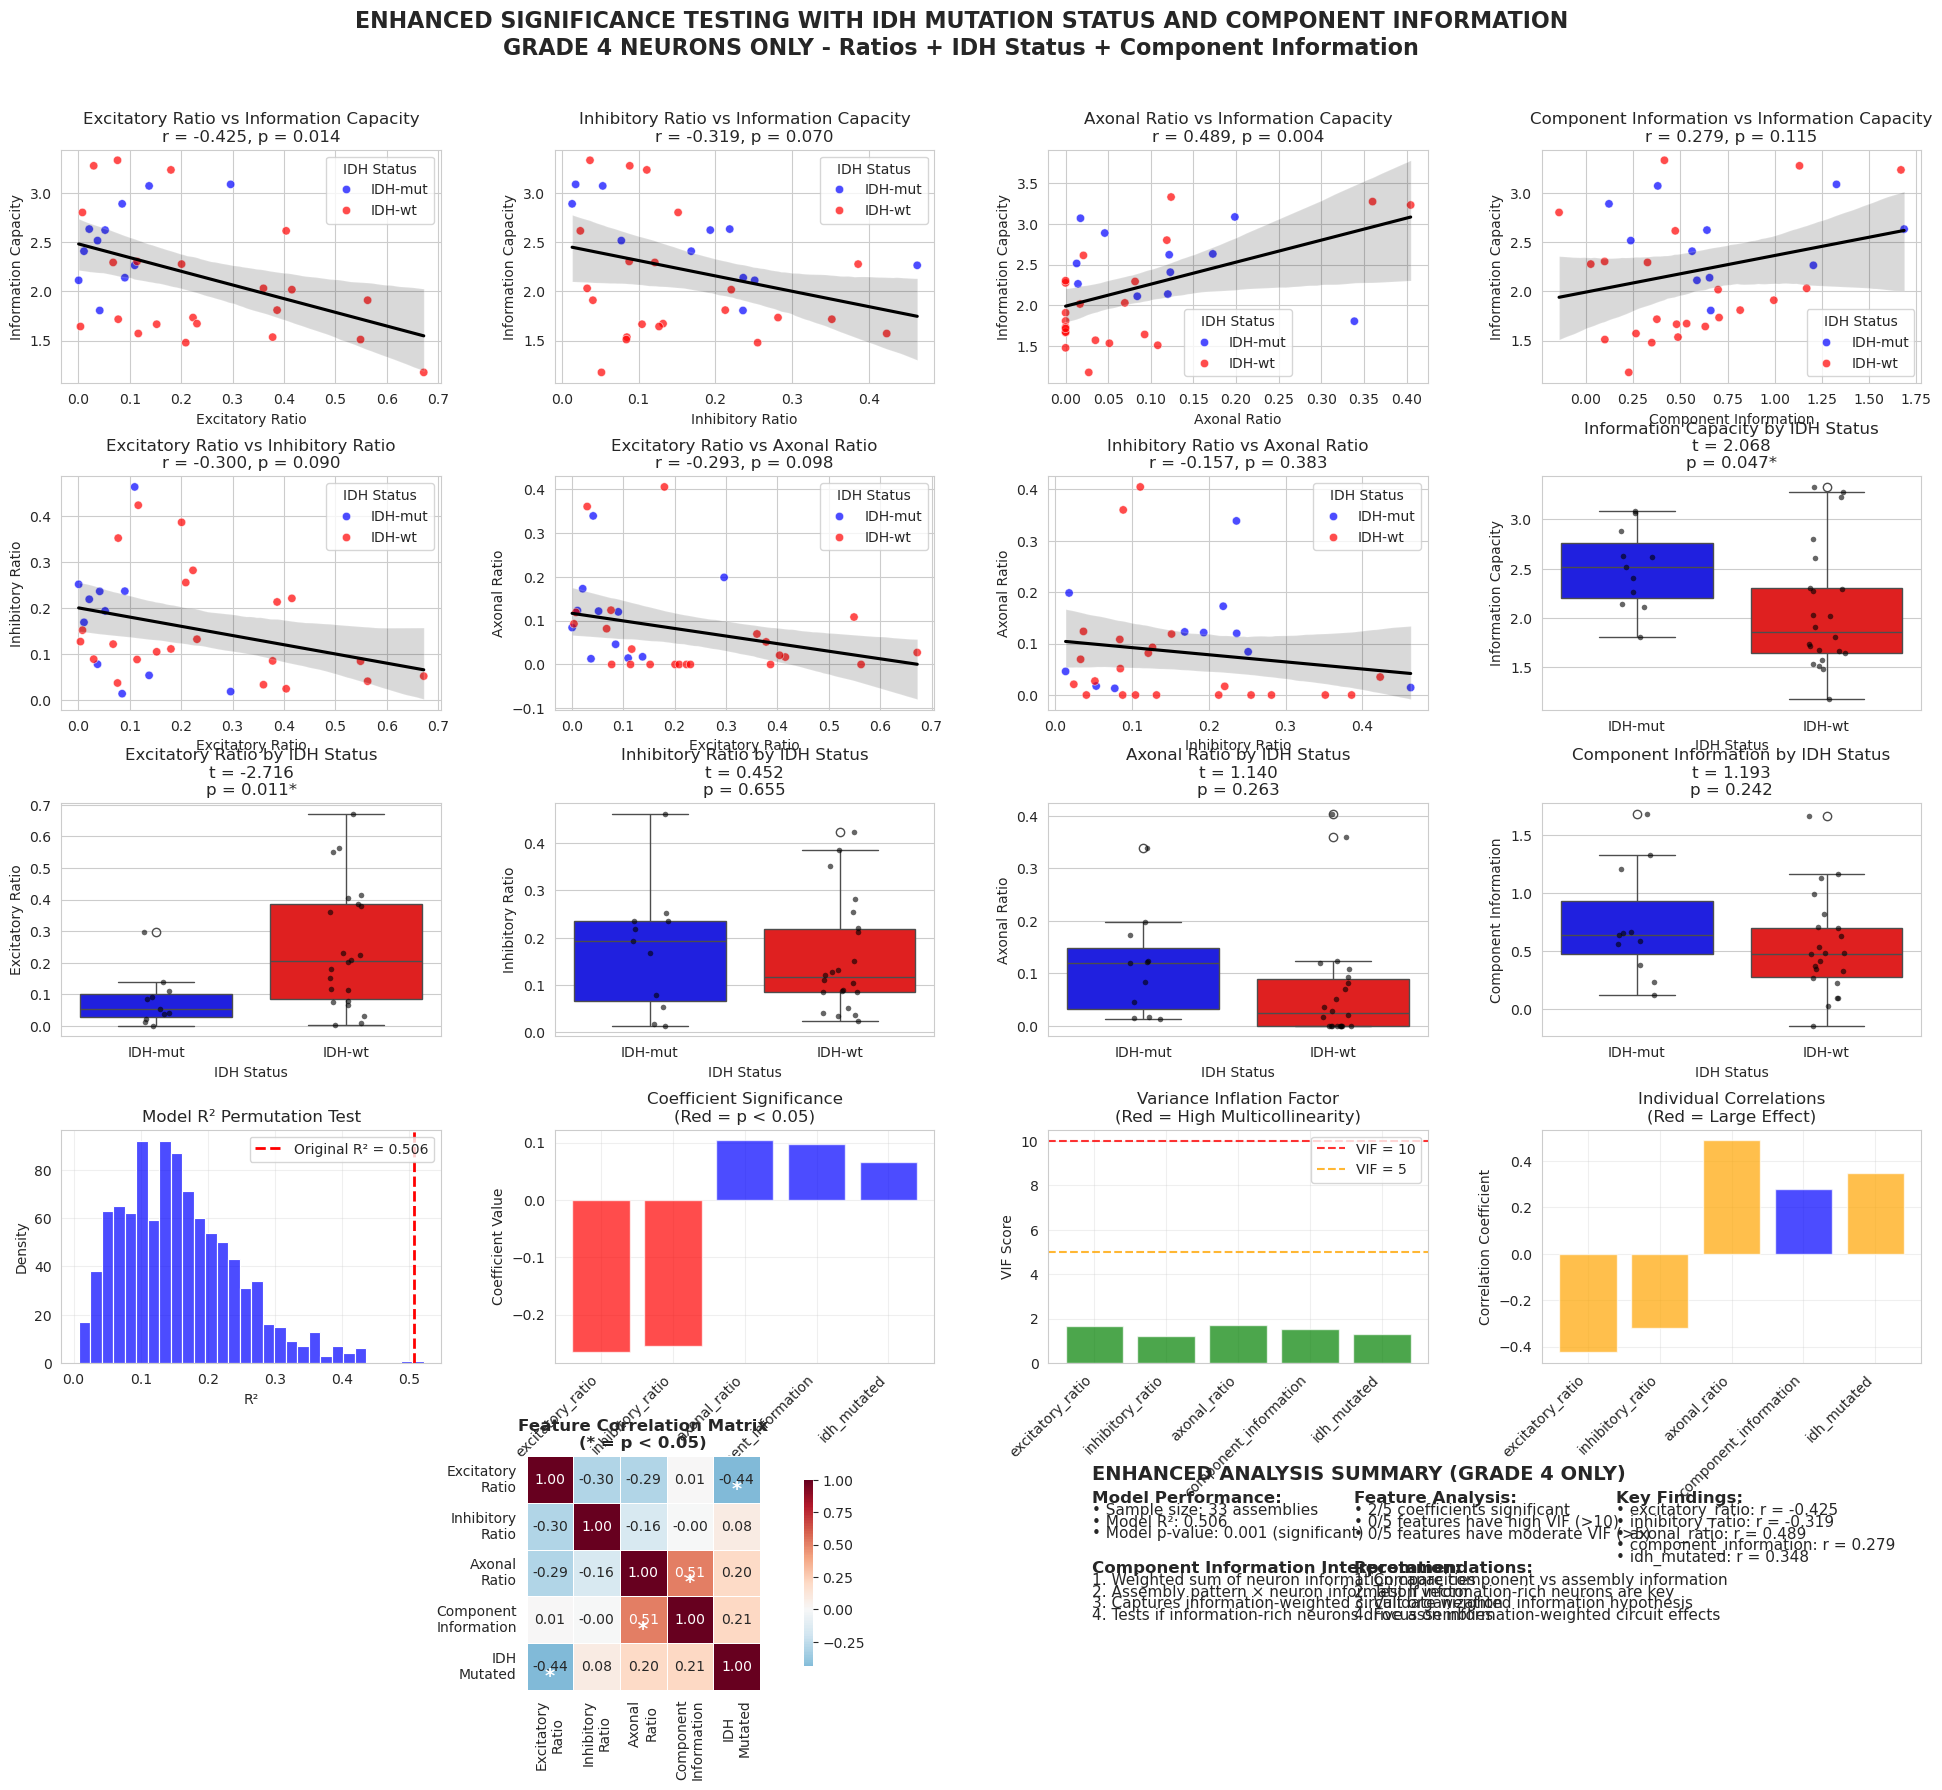


=== ENHANCED ANALYSIS SUMMARY (GRADE 4 ONLY) ===
This analysis includes component information for Grade 4 neurons only:
1. Do ratios + component information predict capacity in Grade 4?
2. Is component information a key predictor in high-grade tumors?
3. Do information-rich neurons drive assemblies in Grade 4?
4. Test information-weighted circuit organization in high-grade tumors
5. Validate weighted information hypothesis in Grade 4 context


In [71]:
# ENHANCED SIGNIFICANCE TESTING WITH IDH MUTATION STATUS AND COMPONENT INFORMATION
# Focus on ratios + IDH mutation status + component information
# GRADE 4 NEURONS ONLY
plt.rcParams['svg.fonttype'] = 'none' 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style for prettier plots
sns.set_style("whitegrid")
sns.set_palette("husl")

# Create dataset - GRADE 4 ONLY
def create_enhanced_dataset():
    assembly_data = []
    for i, assembly in enumerate(assembly_results):
        insertion_idx = assembly['insertion_idx']
        
        # Only include Grade 4 assemblies
        if grade_list[insertion_idx] != 4:
            continue
        
        # Calculate tone metrics
        weights = []
        cluster_labels = []
        neuron_info_capacities = []
        
        for neuron_detail in assembly['neuron_details']:
            if neuron_detail['metadata']:
                weights.append(neuron_detail['assembly_weight'])
                cluster_labels.append(neuron_detail['cluster_label'])
                
                # Get neuron information capacity from neuron_results
                # Find the corresponding neuron in neuron_results
                neuron_idx = neuron_detail['neuron_idx']
                insertion_idx = assembly['insertion_idx']
                
                # Find the neuron in neuron_results
                neuron_info_capacity = 0.0
                for neuron_result in neuron_results:
                    if (neuron_result['insertion_idx'] == insertion_idx and 
                        neuron_result['neuron_idx'] == neuron_idx):
                        neuron_info_capacity = neuron_result['information_capacity']['capacity']
                        break
                
                neuron_info_capacities.append(neuron_info_capacity)
        
        weights = np.array(weights)
        cluster_labels = np.array(cluster_labels)
        neuron_info_capacities = np.array(neuron_info_capacities)
        
        excitatory_tone = np.sum(weights[cluster_labels == 0])
        inhibitory_tone = np.sum(weights[cluster_labels == 1])
        axonal_tone = np.sum(weights[cluster_labels == 2])
        
        # Calculate ratios
        total_tone = np.sum(np.abs(weights))
        excitatory_ratio = np.abs(excitatory_tone) / (total_tone + 1e-10)
        inhibitory_ratio = np.abs(inhibitory_tone) / (total_tone + 1e-10)
        axonal_ratio = np.abs(axonal_tone) / (total_tone + 1e-10)
        
        # Calculate component information (weighted sum of neuron information capacities)
        component_information = np.sum(weights * neuron_info_capacities)
        
        # Determine IDH mutation status - FIXED LABELING
        pathology = path_list[insertion_idx]
        idh_mutated = 1 if pathology in ['ast', 'oli'] else 0  # IDH-mut = 1, IDH-wt = 0
        
        # Create explicit IDH status labels for clarity
        idh_status = 'IDH-mut' if pathology in ['ast', 'oli'] else 'IDH-wt'
        
        assembly_data.append({
            'assembly_idx': i,
            'insertion_idx': insertion_idx,
            'pathology': pathology,
            'grade': grade_list[insertion_idx],
            'information_capacity': assembly['information_capacity']['capacity'],
            'excitatory_ratio': excitatory_ratio,
            'inhibitory_ratio': inhibitory_ratio,
            'axonal_ratio': axonal_ratio,
            'component_information': component_information,
            'idh_mutated': idh_mutated,
            'idh_status': idh_status  # Add explicit status label
        })
    
    return pd.DataFrame(assembly_data)

df = create_enhanced_dataset()
df_valid = df.dropna(subset=['information_capacity', 'component_information'])

print("=== ENHANCED SIGNIFICANCE TESTING WITH IDH MUTATION STATUS AND COMPONENT INFORMATION ===")
print("=== GRADE 4 NEURONS ONLY ===")
print(f"Sample size: {len(df_valid)} assemblies")

# Check IDH distribution
idh_counts = df_valid['idh_mutated'].value_counts()
print(f"IDH-mutated (ast+oli): {idh_counts.get(1, 0)} assemblies")
print(f"IDH-wildtype (gbm): {idh_counts.get(0, 0)} assemblies")

# Verify IDH labeling
print(f"\n=== IDH LABELING VERIFICATION ===")
print("IDH Status breakdown:")
for status in df_valid['idh_status'].unique():
    subset = df_valid[df_valid['idh_status'] == status]
    print(f"  {status}: {len(subset)} assemblies, avg info capacity: {subset['information_capacity'].mean():.3f}")

# Define features (ratios + IDH mutation status + component information)
features = ['excitatory_ratio', 'inhibitory_ratio', 'axonal_ratio', 'component_information', 'idh_mutated']
X = df_valid[features].values
y = df_valid['information_capacity'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. MULTIPLE REGRESSION MODEL
print(f"\n=== MULTIPLE REGRESSION MODEL ===")
lr = LinearRegression()
lr.fit(X_scaled, y)
y_pred = lr.predict(X_scaled)
r2 = lr.score(X_scaled, y)

print(f"R² = {r2:.3f}")
print(f"Coefficients:")
for i, feature in enumerate(features):
    print(f"  {feature}: {lr.coef_[i]:.3f}")

# 2. PERMUTATION TEST FOR MODEL SIGNIFICANCE
print(f"\n=== PERMUTATION TEST FOR MODEL SIGNIFICANCE ===")

def permutation_test_model(X, y, n_permutations=1000):
    """Test if model R² is significantly better than random"""
    
    # Original model
    lr_orig = LinearRegression()
    lr_orig.fit(X, y)
    r2_orig = lr_orig.score(X, y)
    
    # Permutation test
    r2_permuted = []
    for _ in range(n_permutations):
        y_perm = np.random.permutation(y)
        lr_perm = LinearRegression()
        lr_perm.fit(X, y_perm)
        r2_perm = lr_perm.score(X, y_perm)
        r2_permuted.append(r2_perm)
    
    r2_permuted = np.array(r2_permuted)
    p_value = np.mean(r2_permuted >= r2_orig)
    
    return r2_orig, r2_permuted, p_value

r2_orig, r2_permuted, p_model = permutation_test_model(X_scaled, y)

print(f"Original R² = {r2_orig:.3f}")
print(f"Permuted R² = {np.mean(r2_permuted):.3f} ± {np.std(r2_permuted):.3f}")
print(f"p-value = {p_model:.3f}")
print(f"Model is {'significant' if p_model < 0.05 else 'not significant'}")

# 3. MULTICOLLINEARITY ANALYSIS
print(f"\n=== MULTICOLLINEARITY ANALYSIS ===")

def calculate_vif(X, feature_names):
    """Calculate Variance Inflation Factor for each feature"""
    
    vif_scores = []
    for i in range(len(feature_names)):
        # Regress feature i against all other features
        X_other = np.delete(X, i, axis=1)
        y_feature = X[:, i]
        
        lr_vif = LinearRegression()
        lr_vif.fit(X_other, y_feature)
        r2_vif = lr_vif.score(X_other, y_feature)
        
        vif = 1 / (1 - r2_vif) if r2_vif < 0.99 else float('inf')
        vif_scores.append(vif)
        
        print(f"{feature_names[i]}: VIF = {vif:.2f}")
    
    return vif_scores

vif_scores = calculate_vif(X_scaled, features)

# 4. INDIVIDUAL CORRELATIONS
print(f"\n=== INDIVIDUAL CORRELATIONS ===")
individual_correlations = []
individual_p_values = []
for i, feature in enumerate(features):
    r, p = stats.pearsonr(y, X_scaled[:, i])
    individual_correlations.append(r)
    individual_p_values.append(p)
    print(f"{feature}: r = {r:.3f}, p = {p:.3f}")

# 5. COEFFICIENT SIGNIFICANCE TESTING
print(f"\n=== COEFFICIENT SIGNIFICANCE TESTING ===")

def test_coefficient_significance(X, y, feature_names, n_permutations=1000):
    """Test significance of individual coefficients using permutation"""
    
    # Original model
    lr_orig = LinearRegression()
    lr_orig.fit(X, y)
    coef_orig = lr_orig.coef_
    
    # Permutation test for each coefficient
    coef_permuted = np.zeros((n_permutations, len(feature_names)))
    
    for i in range(n_permutations):
        y_perm = np.random.permutation(y)
        lr_perm = LinearRegression()
        lr_perm.fit(X, y_perm)
        coef_permuted[i] = lr_perm.coef_
    
    # Calculate p-values
    p_values = []
    for i, feature in enumerate(feature_names):
        p_val = np.mean(np.abs(coef_permuted[:, i]) >= np.abs(coef_orig[i]))
        p_values.append(p_val)
        
        print(f"{feature}:")
        print(f"  Coefficient = {coef_orig[i]:.3f}")
        print(f"  p-value = {p_val:.3f}")
        print(f"  {'Significant' if p_val < 0.05 else 'Not significant'}")
        print()
    
    return coef_orig, p_values

coef_orig, coef_p_values = test_coefficient_significance(X_scaled, y, features)

# Convert to numpy arrays for comparison
coef_p_values = np.array(coef_p_values)
vif_scores = np.array(vif_scores)
individual_correlations = np.array(individual_correlations)
individual_p_values = np.array(individual_p_values)

# 6. IDH-SPECIFIC ANALYSIS
print(f"\n=== IDH-SPECIFIC ANALYSIS ===")

# Compare information capacity between IDH groups
idh_mut = df_valid[df_valid['idh_mutated'] == 1]['information_capacity']
idh_wt = df_valid[df_valid['idh_mutated'] == 0]['information_capacity']

# T-test
t_stat, t_p = stats.ttest_ind(idh_mut, idh_wt)
print(f"Information Capacity by IDH Status:")
print(f"  IDH-mutated: {idh_mut.mean():.3f} ± {idh_mut.std():.3f} (n={len(idh_mut)})")
print(f"  IDH-wildtype: {idh_wt.mean():.3f} ± {idh_wt.std():.3f} (n={len(idh_wt)})")
print(f"  T-test: t = {t_stat:.3f}, p = {t_p:.3f}")

# Compare ratios between IDH groups
print(f"\nRatio Comparisons by IDH Status:")
idh_comparisons = {}
for ratio in ['excitatory_ratio', 'inhibitory_ratio', 'axonal_ratio', 'component_information']:
    mut_vals = df_valid[df_valid['idh_mutated'] == 1][ratio]
    wt_vals = df_valid[df_valid['idh_mutated'] == 0][ratio]
    
    t_stat_ratio, t_p_ratio = stats.ttest_ind(mut_vals, wt_vals)
    idh_comparisons[ratio] = {
        't_stat': t_stat_ratio,
        'p_value': t_p_ratio,
        'mut_mean': mut_vals.mean(),
        'mut_std': mut_vals.std(),
        'wt_mean': wt_vals.mean(),
        'wt_std': wt_vals.std()
    }
    
    print(f"  {ratio}:")
    print(f"    IDH-mut: {mut_vals.mean():.3f} ± {mut_vals.std():.3f}")
    print(f"    IDH-wt: {wt_vals.mean():.3f} ± {wt_vals.std():.3f}")
    print(f"    T-test: t = {t_stat_ratio:.3f}, p = {t_p_ratio:.3f}")

# Create comprehensive visualization with seaborn - FIXED LABELING
fig = plt.figure(figsize=(24, 20))
gs = fig.add_gridspec(5, 4, hspace=0.4, wspace=0.3)

fig.suptitle('ENHANCED SIGNIFICANCE TESTING WITH IDH MUTATION STATUS AND COMPONENT INFORMATION\nGRADE 4 NEURONS ONLY - Ratios + IDH Status + Component Information', 
             fontsize=16, fontweight='bold', y=0.95)

# 1. Correlation plots between ratios and information capacity - FIXED LABELING
ratio_features = ['excitatory_ratio', 'inhibitory_ratio', 'axonal_ratio']
for i, ratio in enumerate(ratio_features):
    ax = fig.add_subplot(gs[0, i])
    
    # Create scatter plot with explicit IDH status labels
    sns.scatterplot(data=df_valid, x=ratio, y='information_capacity', 
                   hue='idh_status', palette={'IDH-wt': 'red', 'IDH-mut': 'blue'}, 
                   alpha=0.7, ax=ax)
    
    # Add regression line
    sns.regplot(data=df_valid, x=ratio, y='information_capacity', 
                scatter=False, color='black', ax=ax)
    
    # Calculate correlation
    r, p = stats.pearsonr(df_valid[ratio], df_valid['information_capacity'])
    
    ax.set_title(f'{ratio.replace("_", " ").title()} vs Information Capacity\nr = {r:.3f}, p = {p:.3f}')
    ax.set_xlabel(ratio.replace('_', ' ').title())
    ax.set_ylabel('Information Capacity')
    ax.legend(title='IDH Status')

# 2. Component information vs information capacity - FIXED LABELING
ax = fig.add_subplot(gs[0, 3])
sns.scatterplot(data=df_valid, x='component_information', y='information_capacity', 
               hue='idh_status', palette={'IDH-wt': 'red', 'IDH-mut': 'blue'}, 
               alpha=0.7, ax=ax)
sns.regplot(data=df_valid, x='component_information', y='information_capacity', 
            scatter=False, color='black', ax=ax)

r, p = stats.pearsonr(df_valid['component_information'], df_valid['information_capacity'])
ax.set_title(f'Component Information vs Information Capacity\nr = {r:.3f}, p = {p:.3f}')
ax.set_xlabel('Component Information')
ax.set_ylabel('Information Capacity')
ax.legend(title='IDH Status')

# 3. Correlation plots between ratios - FIXED LABELING
ratio_pairs = [
    ('excitatory_ratio', 'inhibitory_ratio'),
    ('excitatory_ratio', 'axonal_ratio'),
    ('inhibitory_ratio', 'axonal_ratio')
]

for i, (ratio1, ratio2) in enumerate(ratio_pairs):
    ax = fig.add_subplot(gs[1, i])
    
    sns.scatterplot(data=df_valid, x=ratio1, y=ratio2, 
                   hue='idh_status', palette={'IDH-wt': 'red', 'IDH-mut': 'blue'}, 
                   alpha=0.7, ax=ax)
    sns.regplot(data=df_valid, x=ratio1, y=ratio2, 
                scatter=False, color='black', ax=ax)
    
    r, p = stats.pearsonr(df_valid[ratio1], df_valid[ratio2])
    ax.set_title(f'{ratio1.replace("_", " ").title()} vs {ratio2.replace("_", " ").title()}\nr = {r:.3f}, p = {p:.3f}')
    ax.set_xlabel(ratio1.replace('_', ' ').title())
    ax.set_ylabel(ratio2.replace('_', ' ').title())
    ax.legend(title='IDH Status')

# 4. Information capacity comparison by IDH status - FIXED LABELING
ax = fig.add_subplot(gs[1, 3])
sns.boxplot(data=df_valid, x='idh_status', y='information_capacity', 
            palette={'IDH-wt': 'red', 'IDH-mut': 'blue'}, ax=ax)
sns.stripplot(data=df_valid, x='idh_status', y='information_capacity', 
              color='black', alpha=0.6, size=4, ax=ax)

# Add significance annotation
sig_text = f't = {t_stat:.3f}\np = {t_p:.3f}'
if t_p < 0.001:
    sig_text += '***'
elif t_p < 0.01:
    sig_text += '**'
elif t_p < 0.05:
    sig_text += '*'

ax.set_title(f'Information Capacity by IDH Status\n{sig_text}')
ax.set_xlabel('IDH Status')
ax.set_ylabel('Information Capacity')

# 5. Ratio comparisons by IDH status - FIXED LABELING
for i, ratio in enumerate(ratio_features):
    ax = fig.add_subplot(gs[2, i])
    sns.boxplot(data=df_valid, x='idh_status', y=ratio, 
                palette={'IDH-wt': 'red', 'IDH-mut': 'blue'}, ax=ax)
    sns.stripplot(data=df_valid, x='idh_status', y=ratio, 
                  color='black', alpha=0.6, size=4, ax=ax)
    
    # Add significance annotation
    comp = idh_comparisons[ratio]
    sig_text = f't = {comp["t_stat"]:.3f}\np = {comp["p_value"]:.3f}'
    if comp["p_value"] < 0.001:
        sig_text += '***'
    elif comp["p_value"] < 0.01:
        sig_text += '**'
    elif comp["p_value"] < 0.05:
        sig_text += '*'
    
    ax.set_title(f'{ratio.replace("_", " ").title()} by IDH Status\n{sig_text}')
    ax.set_xlabel('IDH Status')
    ax.set_ylabel(ratio.replace('_', ' ').title())

# 6. Component information by IDH status - FIXED LABELING
ax = fig.add_subplot(gs[2, 3])
sns.boxplot(data=df_valid, x='idh_status', y='component_information', 
            palette={'IDH-wt': 'red', 'IDH-mut': 'blue'}, ax=ax)
sns.stripplot(data=df_valid, x='idh_status', y='component_information', 
              color='black', alpha=0.6, size=4, ax=ax)

# Add significance annotation
comp = idh_comparisons['component_information']
sig_text = f't = {comp["t_stat"]:.3f}\np = {comp["p_value"]:.3f}'
if comp["p_value"] < 0.001:
    sig_text += '***'
elif comp["p_value"] < 0.01:
    sig_text += '**'
elif comp["p_value"] < 0.05:
    sig_text += '*'

ax.set_title(f'Component Information by IDH Status\n{sig_text}')
ax.set_xlabel('IDH Status')
ax.set_ylabel('Component Information')

# 7. Model R² vs permutations
ax = fig.add_subplot(gs[3, 0])
sns.histplot(r2_permuted, bins=30, alpha=0.7, color='blue', ax=ax)
ax.axvline(r2_orig, color='red', linestyle='--', linewidth=2, label=f'Original R² = {r2_orig:.3f}')
ax.set_xlabel('R²')
ax.set_ylabel('Density')
ax.set_title('Model R² Permutation Test')
ax.legend()
ax.grid(True, alpha=0.3)

# 8. Coefficient significance
ax = fig.add_subplot(gs[3, 1])
colors = ['red' if p < 0.05 else 'blue' for p in coef_p_values]
bars = ax.bar(range(len(features)), coef_orig, color=colors, alpha=0.7)
ax.set_xticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_ylabel('Coefficient Value')
ax.set_title('Coefficient Significance\n(Red = p < 0.05)')
ax.grid(True, alpha=0.3)

# 9. VIF scores
ax = fig.add_subplot(gs[3, 2])
colors_vif = ['red' if vif > 10 else 'orange' if vif > 5 else 'green' for vif in vif_scores]
bars = ax.bar(range(len(features)), vif_scores, color=colors_vif, alpha=0.7)
ax.set_xticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_ylabel('VIF Score')
ax.set_title('Variance Inflation Factor\n(Red = High Multicollinearity)')
ax.axhline(y=10, color='red', linestyle='--', alpha=0.8, label='VIF = 10')
ax.axhline(y=5, color='orange', linestyle='--', alpha=0.8, label='VIF = 5')
ax.legend()
ax.grid(True, alpha=0.3)

# 10. Individual correlations
ax = fig.add_subplot(gs[3, 3])
colors_corr = ['red' if abs(r) > 0.5 else 'orange' if abs(r) > 0.3 else 'blue' for r in individual_correlations]
bars = ax.bar(range(len(features)), individual_correlations, color=colors_corr, alpha=0.7)
ax.set_xticks(range(len(features)))
ax.set_xticklabels(features, rotation=45, ha='right')
ax.set_ylabel('Correlation Coefficient')
ax.set_title('Individual Correlations\n(Red = Large Effect)')
ax.grid(True, alpha=0.3)

# 11. ENHANCED Feature correlation matrix with significance indicators
ax = fig.add_subplot(gs[4, :2])
corr_matrix = np.corrcoef(X_scaled.T)

# Create cleaner feature names for display
feature_names_display = ['Excitatory\nRatio', 'Inhibitory\nRatio', 'Axonal\nRatio', 'Component\nInformation', 'IDH\nMutated']

# Calculate significance for each correlation
sig_matrix = np.zeros_like(corr_matrix, dtype=bool)
for i in range(len(features)):
    for j in range(len(features)):
        if i != j:
            _, p_val = stats.pearsonr(X_scaled[:, i], X_scaled[:, j])
            if p_val < 0.05:
                sig_matrix[i, j] = True

# Plot correlation matrix with all values shown
im = sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
                 square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,
                 xticklabels=feature_names_display, yticklabels=feature_names_display,
                 fmt='.2f', annot_kws={'fontsize': 10})

# Add significance indicators
for i in range(len(features)):
    for j in range(len(features)):
        if i != j and sig_matrix[i, j]:
            # Add asterisk for significant correlations
            ax.text(j + 0.5, i + 0.7, '*', ha='center', va='center', 
                   fontsize=14, fontweight='bold', color='white')

ax.set_title('Feature Correlation Matrix\n(* = p < 0.05)', fontsize=12, fontweight='bold')

# 12. Summary statistics
ax = fig.add_subplot(gs[4, 2:])
ax.text(0.05, 0.9, 'ENHANCED ANALYSIS SUMMARY (GRADE 4 ONLY)', fontsize=14, fontweight='bold')

# Model statistics
ax.text(0.05, 0.8, 'Model Performance:', fontsize=12, fontweight='bold')
ax.text(0.05, 0.75, f'• Sample size: {len(df_valid)} assemblies', fontsize=11)
ax.text(0.05, 0.7, f'• Model R²: {r2_orig:.3f}', fontsize=11)

# Fix the f-string issue by using a variable
significance_text = 'significant' if p_model < 0.05 else 'not significant'
ax.text(0.05, 0.65, f'• Model p-value: {p_model:.3f} ({significance_text})', fontsize=11)

# Feature analysis
ax.text(0.35, 0.8, 'Feature Analysis:', fontsize=12, fontweight='bold')
ax.text(0.35, 0.75, f'• {sum(coef_p_values < 0.05)}/{len(features)} coefficients significant', fontsize=11)
ax.text(0.35, 0.7, f'• {sum(vif_scores > 10)}/{len(features)} features have high VIF (>10)', fontsize=11)
ax.text(0.35, 0.65, f'• {sum(vif_scores > 5)}/{len(features)} features have moderate VIF (>5)', fontsize=11)

# Key findings
ax.text(0.65, 0.8, 'Key Findings:', fontsize=12, fontweight='bold')
for i, feature in enumerate(features):
    ax.text(0.65, 0.75 - i*0.05, f'• {feature}: r = {individual_correlations[i]:.3f}', fontsize=11)

# Component information interpretation
ax.text(0.05, 0.5, 'Component Information Interpretation:', fontsize=12, fontweight='bold')
ax.text(0.05, 0.45, '1. Weighted sum of neuron information capacities', fontsize=11)
ax.text(0.05, 0.4, '2. Assembly pattern × neuron information vector', fontsize=11)
ax.text(0.05, 0.35, '3. Captures information-weighted circuit organization', fontsize=11)
ax.text(0.05, 0.3, '4. Tests if information-rich neurons drive assemblies', fontsize=11)

# Recommendations
ax.text(0.35, 0.5, 'Recommendations:', fontsize=12, fontweight='bold')
ax.text(0.35, 0.45, '1. Compare component vs assembly information', fontsize=11)
ax.text(0.35, 0.4, '2. Test if information-rich neurons are key', fontsize=11)
ax.text(0.35, 0.35, '3. Validate weighted information hypothesis', fontsize=11)
ax.text(0.35, 0.3, '4. Focus on information-weighted circuit effects', fontsize=11)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.savefig("tone_model_fixed_labeling.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n=== ENHANCED ANALYSIS SUMMARY (GRADE 4 ONLY) ===")
print("This analysis includes component information for Grade 4 neurons only:")
print("1. Do ratios + component information predict capacity in Grade 4?")
print("2. Is component information a key predictor in high-grade tumors?")
print("3. Do information-rich neurons drive assemblies in Grade 4?")
print("4. Test information-weighted circuit organization in high-grade tumors")
print("5. Validate weighted information hypothesis in Grade 4 context")

=== ENHANCED MODEL VISUALIZATION WITH PREDICTED VS ACTUAL ANALYSIS ===
=== GRADE 4 NEURONS ONLY ===
Sample size: 33 assemblies
Model Performance:
  R² = 0.506
  RMSE = 0.410
  MAE = 0.332


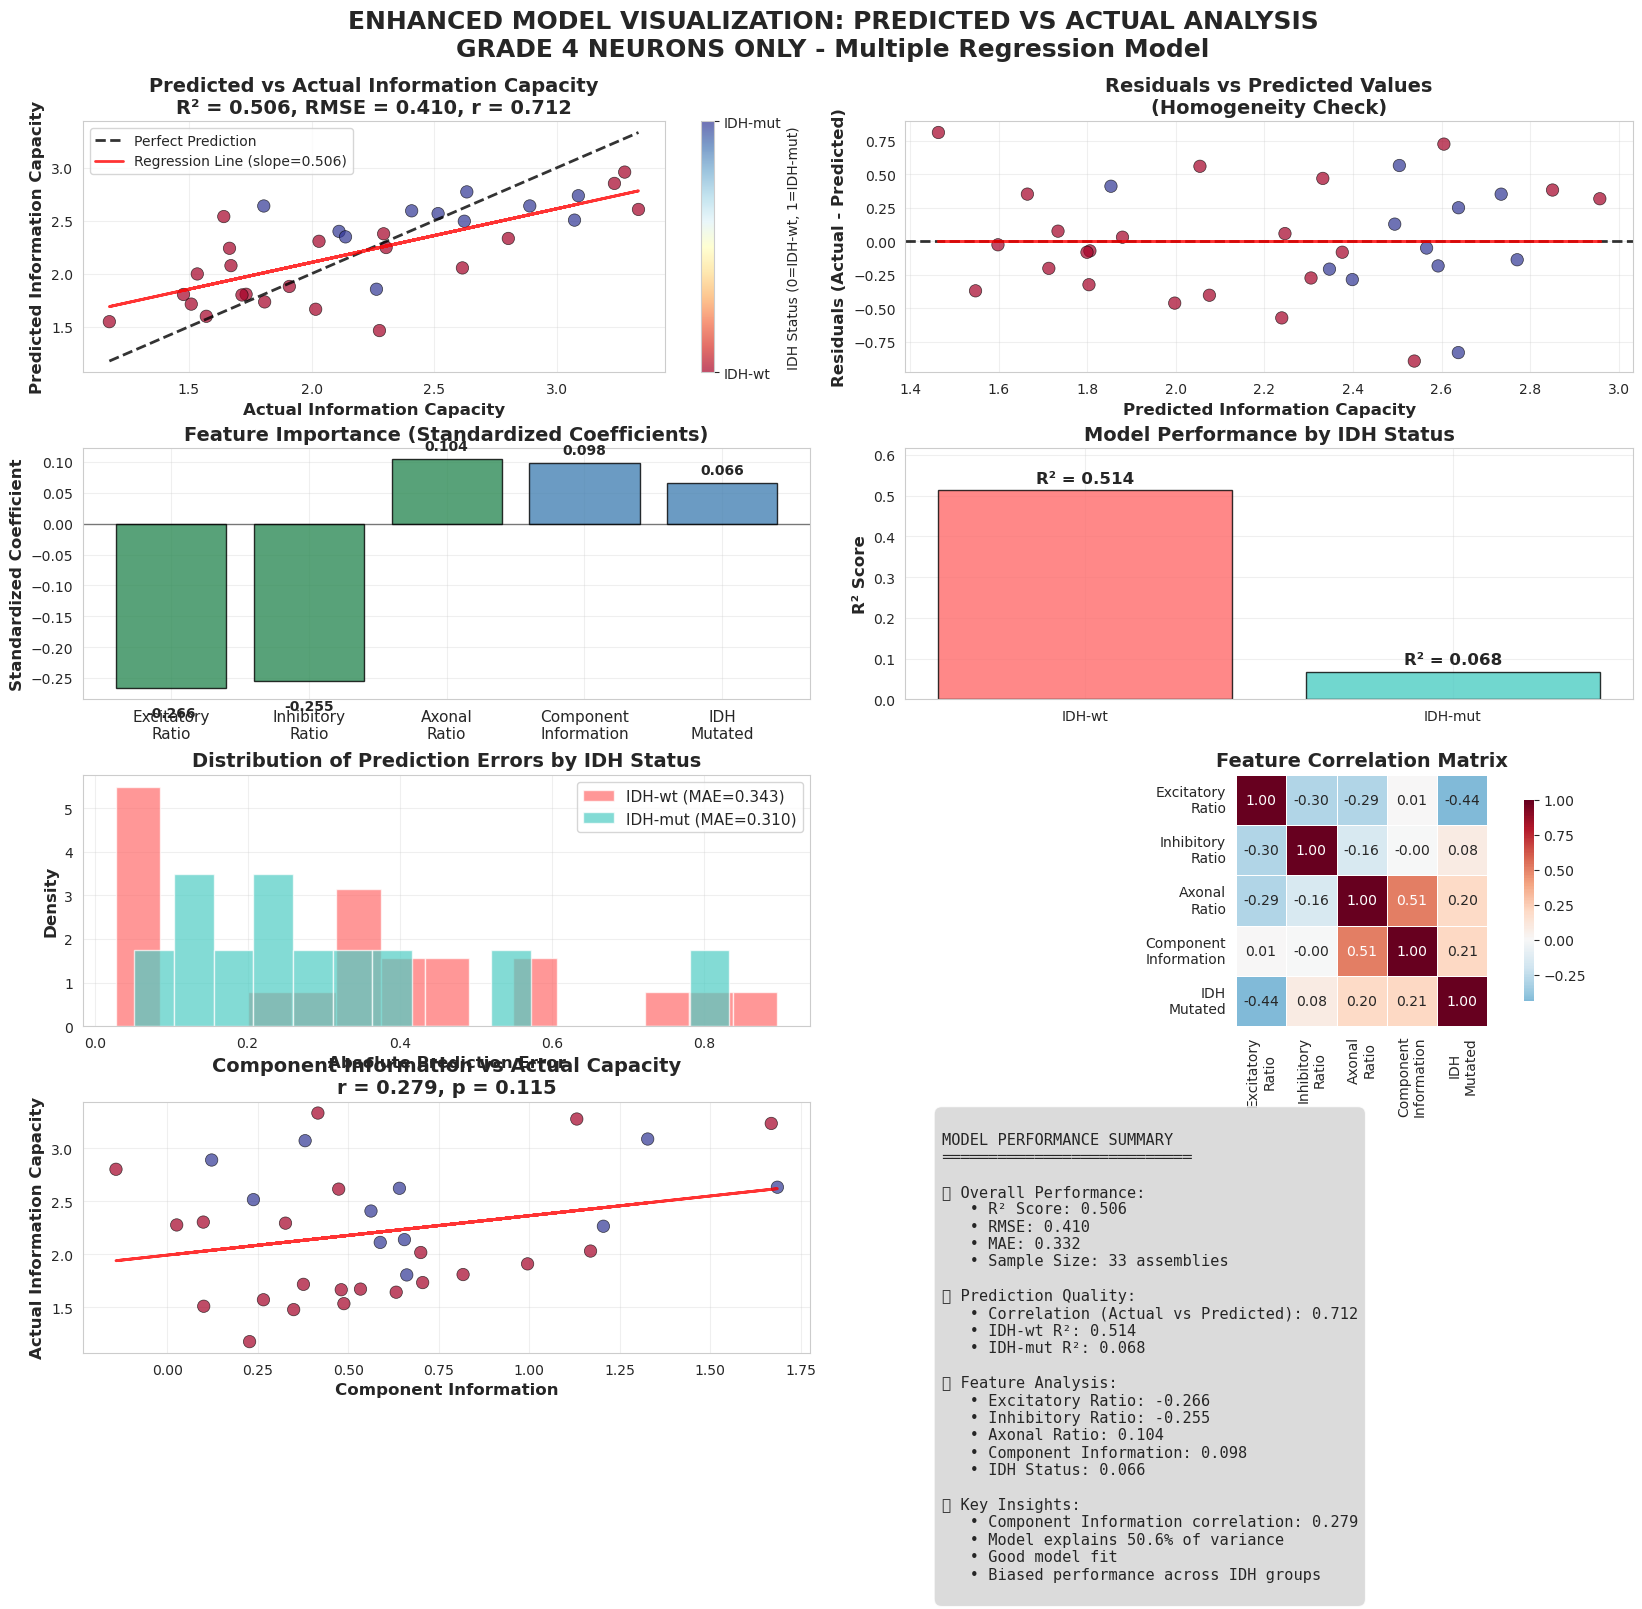


=== DETAILED MODEL ANALYSIS ===
Model Equation:
Predicted Capacity = 2.216
  + -0.266 × excitatory_ratio
  + -0.255 × inhibitory_ratio
  + 0.104 × axonal_ratio
  + 0.098 × component_information
  + 0.066 × idh_mutated

Prediction Accuracy by IDH Status:
  IDH-wt: R² = 0.514, MAE = 0.343
  IDH-mut: R² = 0.068, MAE = 0.310

Feature Contributions:
  excitatory_ratio: -0.266 (std. coef.)
  inhibitory_ratio: -0.255 (std. coef.)
  axonal_ratio: 0.104 (std. coef.)
  component_information: 0.098 (std. coef.)
  idh_mutated: 0.066 (std. coef.)

Model Validation:
  Overall R²: 0.506
  Actual vs Predicted correlation: 0.712
  Root Mean Square Error: 0.410
  Mean Absolute Error: 0.332


In [66]:
# ENHANCED MODEL VISUALIZATION WITH PREDICTED VS ACTUAL ANALYSIS
# Building off the previous analysis with beautiful visualizations
plt.rcParams['svg.fonttype'] = 'none' 

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seaborn style for prettier plots
sns.set_style("whitegrid")
sns.set_palette("husl")

# Create dataset - GRADE 4 ONLY (same as before)
def create_enhanced_dataset():
    assembly_data = []
    for i, assembly in enumerate(assembly_results):
        insertion_idx = assembly['insertion_idx']
        
        # Only include Grade 4 assemblies
        if grade_list[insertion_idx] != 4:
            continue
        
        # Calculate tone metrics
        weights = []
        cluster_labels = []
        neuron_info_capacities = []
        
        for neuron_detail in assembly['neuron_details']:
            if neuron_detail['metadata']:
                weights.append(neuron_detail['assembly_weight'])
                cluster_labels.append(neuron_detail['cluster_label'])
                
                # Get neuron information capacity from neuron_results
                neuron_idx = neuron_detail['neuron_idx']
                insertion_idx = assembly['insertion_idx']
                
                # Find the neuron in neuron_results
                neuron_info_capacity = 0.0
                for neuron_result in neuron_results:
                    if (neuron_result['insertion_idx'] == insertion_idx and 
                        neuron_result['neuron_idx'] == neuron_idx):
                        neuron_info_capacity = neuron_result['information_capacity']['capacity']
                        break
                
                neuron_info_capacities.append(neuron_info_capacity)
        
        weights = np.array(weights)
        cluster_labels = np.array(cluster_labels)
        neuron_info_capacities = np.array(neuron_info_capacities)
        
        excitatory_tone = np.sum(weights[cluster_labels == 0])
        inhibitory_tone = np.sum(weights[cluster_labels == 1])
        axonal_tone = np.sum(weights[cluster_labels == 2])
        
        # Calculate ratios
        total_tone = np.sum(np.abs(weights))
        excitatory_ratio = np.abs(excitatory_tone) / (total_tone + 1e-10)
        inhibitory_ratio = np.abs(inhibitory_tone) / (total_tone + 1e-10)
        axonal_ratio = np.abs(axonal_tone) / (total_tone + 1e-10)
        
        # Calculate component information (weighted sum of neuron information capacities)
        component_information = np.sum(weights * neuron_info_capacities)
        
        # Determine IDH mutation status
        pathology = path_list[insertion_idx]
        idh_mutated = 1 if pathology in ['ast', 'oli'] else 0
        
        assembly_data.append({
            'assembly_idx': i,
            'insertion_idx': insertion_idx,
            'pathology': pathology,
            'grade': grade_list[insertion_idx],
            'information_capacity': assembly['information_capacity']['capacity'],
            'excitatory_ratio': excitatory_ratio,
            'inhibitory_ratio': inhibitory_ratio,
            'axonal_ratio': axonal_ratio,
            'component_information': component_information,
            'idh_mutated': idh_mutated
        })
    
    return pd.DataFrame(assembly_data)

df = create_enhanced_dataset()
df_valid = df.dropna(subset=['information_capacity', 'component_information'])

print("=== ENHANCED MODEL VISUALIZATION WITH PREDICTED VS ACTUAL ANALYSIS ===")
print("=== GRADE 4 NEURONS ONLY ===")
print(f"Sample size: {len(df_valid)} assemblies")

# Define features and prepare data
features = ['excitatory_ratio', 'inhibitory_ratio', 'axonal_ratio', 'component_information', 'idh_mutated']
X = df_valid[features].values
y = df_valid['information_capacity'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Build the model
lr = LinearRegression()
lr.fit(X_scaled, y)
y_pred = lr.predict(X_scaled)

# Calculate model metrics
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"Model Performance:")
print(f"  R² = {r2:.3f}")
print(f"  RMSE = {rmse:.3f}")
print(f"  MAE = {mae:.3f}")

# Add predictions to dataframe for plotting
df_valid['predicted_capacity'] = y_pred
df_valid['residuals'] = y - y_pred

# Create beautiful comprehensive visualization
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)

fig.suptitle('ENHANCED MODEL VISUALIZATION: PREDICTED VS ACTUAL ANALYSIS\nGRADE 4 NEURONS ONLY - Multiple Regression Model', 
             fontsize=18, fontweight='bold', y=0.95)

# 1. PREDICTED VS ACTUAL - Main plot
ax1 = fig.add_subplot(gs[0, :2])

# Create scatter plot with IDH status coloring
scatter = ax1.scatter(y, y_pred, c=df_valid['idh_mutated'], 
                     cmap='RdYlBu', alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

# Add perfect prediction line
min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, alpha=0.8, label='Perfect Prediction')

# Add regression line
z = np.polyfit(y, y_pred, 1)
p = np.poly1d(z)
ax1.plot(y, p(y), 'r-', linewidth=2, alpha=0.8, label=f'Regression Line (slope={z[0]:.3f})')

# Calculate correlation between actual and predicted
corr_coef, corr_p = stats.pearsonr(y, y_pred)

ax1.set_xlabel('Actual Information Capacity', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Information Capacity', fontsize=12, fontweight='bold')
ax1.set_title(f'Predicted vs Actual Information Capacity\nR² = {r2:.3f}, RMSE = {rmse:.3f}, r = {corr_coef:.3f}', 
              fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('IDH Status (0=IDH-wt, 1=IDH-mut)', fontsize=10)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['IDH-wt', 'IDH-mut'])

ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. RESIDUALS PLOT
ax2 = fig.add_subplot(gs[0, 2:])

# Residuals vs predicted
ax2.scatter(y_pred, df_valid['residuals'], c=df_valid['idh_mutated'], 
           cmap='RdYlBu', alpha=0.7, s=80, edgecolors='black', linewidth=0.5)

# Add horizontal line at zero
ax2.axhline(y=0, color='k', linestyle='--', linewidth=2, alpha=0.8)

# Add regression line for residuals
z_res = np.polyfit(y_pred, df_valid['residuals'], 1)
p_res = np.poly1d(z_res)
ax2.plot(y_pred, p_res(y_pred), 'r-', linewidth=2, alpha=0.8)

ax2.set_xlabel('Predicted Information Capacity', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
ax2.set_title('Residuals vs Predicted Values\n(Homogeneity Check)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. FEATURE IMPORTANCE - Standardized Coefficients
ax3 = fig.add_subplot(gs[1, :2])

# Calculate standardized coefficients
feature_names_display = ['Excitatory\nRatio', 'Inhibitory\nRatio', 'Axonal\nRatio', 
                        'Component\nInformation', 'IDH\nMutated']
std_coefs = lr.coef_

# Color bars based on significance (you can add significance testing here)
colors = ['#2E8B57' if abs(coef) > 0.1 else '#4682B4' for coef in std_coefs]
bars = ax3.bar(range(len(feature_names_display)), std_coefs, color=colors, alpha=0.8, 
               edgecolor='black', linewidth=1)

# Add value labels on bars
for i, (bar, coef) in enumerate(zip(bars, std_coefs)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + (0.01 if height >= 0 else -0.03),
             f'{coef:.3f}', ha='center', va='bottom' if height >= 0 else 'top', 
             fontweight='bold', fontsize=10)

ax3.set_xticks(range(len(feature_names_display)))
ax3.set_xticklabels(feature_names_display, fontsize=11)
ax3.set_ylabel('Standardized Coefficient', fontsize=12, fontweight='bold')
ax3.set_title('Feature Importance (Standardized Coefficients)', fontsize=14, fontweight='bold')
ax3.axhline(y=0, color='k', linestyle='-', linewidth=1, alpha=0.5)
ax3.grid(True, alpha=0.3)

# 4. MODEL PERFORMANCE BY IDH STATUS
ax4 = fig.add_subplot(gs[1, 2:])

# Calculate R² for each IDH group
idh_wt_mask = df_valid['idh_mutated'] == 0
idh_mut_mask = df_valid['idh_mutated'] == 1

r2_wt = r2_score(df_valid[idh_wt_mask]['information_capacity'], 
                 df_valid[idh_wt_mask]['predicted_capacity'])
r2_mut = r2_score(df_valid[idh_mut_mask]['information_capacity'], 
                  df_valid[idh_mut_mask]['predicted_capacity'])

# Create bar plot
groups = ['IDH-wt', 'IDH-mut']
r2_values = [r2_wt, r2_mut]
colors_perf = ['#FF6B6B', '#4ECDC4']

bars = ax4.bar(groups, r2_values, color=colors_perf, alpha=0.8, 
               edgecolor='black', linewidth=1)

# Add value labels
for bar, r2_val in zip(bars, r2_values):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'R² = {r2_val:.3f}', ha='center', va='bottom', 
             fontweight='bold', fontsize=12)

ax4.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax4.set_title('Model Performance by IDH Status', fontsize=14, fontweight='bold')
ax4.set_ylim(0, max(r2_values) * 1.2)
ax4.grid(True, alpha=0.3)

# 5. PREDICTION ACCURACY DISTRIBUTION
ax5 = fig.add_subplot(gs[2, :2])

# Calculate prediction errors
prediction_errors = np.abs(df_valid['residuals'])
mae_by_idh = [prediction_errors[idh_wt_mask].mean(), prediction_errors[idh_mut_mask].mean()]

# Create histogram of prediction errors
ax5.hist(prediction_errors[idh_wt_mask], bins=15, alpha=0.7, color='#FF6B6B', 
         label=f'IDH-wt (MAE={mae_by_idh[0]:.3f})', density=True)
ax5.hist(prediction_errors[idh_mut_mask], bins=15, alpha=0.7, color='#4ECDC4', 
         label=f'IDH-mut (MAE={mae_by_idh[1]:.3f})', density=True)

ax5.set_xlabel('Absolute Prediction Error', fontsize=12, fontweight='bold')
ax5.set_ylabel('Density', fontsize=12, fontweight='bold')
ax5.set_title('Distribution of Prediction Errors by IDH Status', fontsize=14, fontweight='bold')
ax5.legend(fontsize=11)
ax5.grid(True, alpha=0.3)

# 6. FEATURE CORRELATION HEATMAP
ax6 = fig.add_subplot(gs[2, 2:])

# Calculate correlation matrix
corr_matrix = np.corrcoef(X_scaled.T)

# Create heatmap
im = sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
                 square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax6,
                 xticklabels=feature_names_display, yticklabels=feature_names_display,
                 fmt='.2f', annot_kws={'fontsize': 10})

ax6.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

# 7. COMPONENT INFORMATION ANALYSIS
ax7 = fig.add_subplot(gs[3, :2])

# Scatter plot of component information vs actual information capacity
scatter = ax7.scatter(df_valid['component_information'], df_valid['information_capacity'], 
                     c=df_valid['idh_mutated'], cmap='RdYlBu', alpha=0.7, s=80, 
                     edgecolors='black', linewidth=0.5)

# Add regression line
z_comp = np.polyfit(df_valid['component_information'], df_valid['information_capacity'], 1)
p_comp = np.poly1d(z_comp)
ax7.plot(df_valid['component_information'], p_comp(df_valid['component_information']), 
         'r-', linewidth=2, alpha=0.8)

# Calculate correlation
comp_corr, comp_p = stats.pearsonr(df_valid['component_information'], df_valid['information_capacity'])

ax7.set_xlabel('Component Information', fontsize=12, fontweight='bold')
ax7.set_ylabel('Actual Information Capacity', fontsize=12, fontweight='bold')
ax7.set_title(f'Component Information vs Actual Capacity\nr = {comp_corr:.3f}, p = {comp_p:.3f}', 
              fontsize=14, fontweight='bold')
ax7.grid(True, alpha=0.3)

# 8. MODEL SUMMARY STATISTICS
ax8 = fig.add_subplot(gs[3, 2:])
ax8.axis('off')

# Create comprehensive summary
summary_text = f"""
MODEL PERFORMANCE SUMMARY
═══════════════════════════

📊 Overall Performance:
   • R² Score: {r2:.3f}
   • RMSE: {rmse:.3f}
   • MAE: {mae:.3f}
   • Sample Size: {len(df_valid)} assemblies

🎯 Prediction Quality:
   • Correlation (Actual vs Predicted): {corr_coef:.3f}
   • IDH-wt R²: {r2_wt:.3f}
   • IDH-mut R²: {r2_mut:.3f}

🔍 Feature Analysis:
   • Excitatory Ratio: {std_coefs[0]:.3f}
   • Inhibitory Ratio: {std_coefs[1]:.3f}
   • Axonal Ratio: {std_coefs[2]:.3f}
   • Component Information: {std_coefs[3]:.3f}
   • IDH Status: {std_coefs[4]:.3f}

📈 Key Insights:
   • Component Information correlation: {comp_corr:.3f}
   • Model explains {r2*100:.1f}% of variance
   • {'Good' if r2 > 0.5 else 'Moderate' if r2 > 0.3 else 'Poor'} model fit
   • {'Balanced' if abs(r2_wt - r2_mut) < 0.1 else 'Biased'} performance across IDH groups
"""

ax8.text(0.05, 0.95, summary_text, transform=ax8.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

plt.savefig("enhanced_model_visualization.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Additional detailed analysis
print(f"\n=== DETAILED MODEL ANALYSIS ===")
print(f"Model Equation:")
print(f"Predicted Capacity = {lr.intercept_:.3f}")
for i, feature in enumerate(features):
    print(f"  + {lr.coef_[i]:.3f} × {feature}")

print(f"\nPrediction Accuracy by IDH Status:")
print(f"  IDH-wt: R² = {r2_wt:.3f}, MAE = {mae_by_idh[0]:.3f}")
print(f"  IDH-mut: R² = {r2_mut:.3f}, MAE = {mae_by_idh[1]:.3f}")

print(f"\nFeature Contributions:")
for i, feature in enumerate(features):
    print(f"  {feature}: {std_coefs[i]:.3f} (std. coef.)")

print(f"\nModel Validation:")
print(f"  Overall R²: {r2:.3f}")
print(f"  Actual vs Predicted correlation: {corr_coef:.3f}")
print(f"  Root Mean Square Error: {rmse:.3f}")
print(f"  Mean Absolute Error: {mae:.3f}")

=== DEPTH ANALYSIS SUMMARY (UNIQUE NEURONS ONLY) ===
Total unique neurons: 203
Oli+Ast neurons: 66
GBM neurons: 137


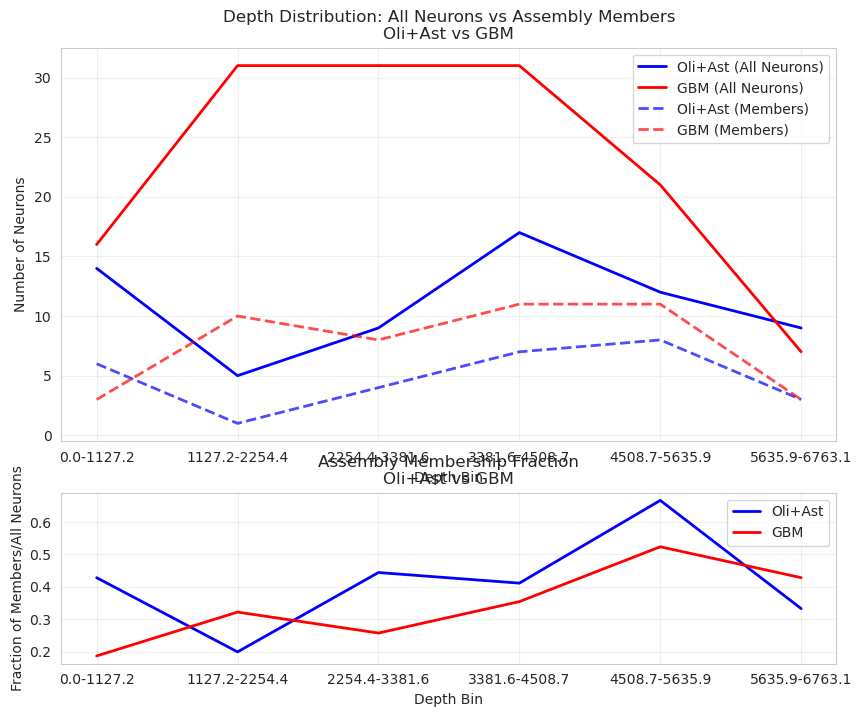

=== STATISTICAL ANALYSIS ===

Oli+Ast vs GBM:
Chi-square statistic: 14.774
p-value: 0.011
Degrees of freedom: 5
✓ Significant difference in depth distributions

Oli+Ast Members vs GBM Members:
Chi-square statistic: 7.597
p-value: 0.180
Degrees of freedom: 5
✗ No significant difference in depth distributions

=== MEMBERSHIP FRACTION DIFFERENCES: Oli+Ast vs GBM ===
Membership fractions by depth bin:
Bin 1 (0.0-1127.2):
  Oli+Ast: 0.429
  GBM: 0.188
  Difference: 0.241
Bin 2 (1127.2-2254.4):
  Oli+Ast: 0.200
  GBM: 0.323
  Difference: -0.123
Bin 3 (2254.4-3381.6):
  Oli+Ast: 0.444
  GBM: 0.258
  Difference: 0.186
Bin 4 (3381.6-4508.7):
  Oli+Ast: 0.412
  GBM: 0.355
  Difference: 0.057
Bin 5 (4508.7-5635.9):
  Oli+Ast: 0.667
  GBM: 0.524
  Difference: 0.143
Bin 6 (5635.9-6763.1):
  Oli+Ast: 0.333
  GBM: 0.429
  Difference: -0.095

Statistical tests on membership fractions:
Kolmogorov-Smirnov test:
  KS statistic: 0.333
  p-value: 0.931
  ✗ No significant difference in membership fraction d

In [65]:
# DEPTH ANALYSIS FOR UNIQUE NEURONS FROM ASSEMBLY ANALYSIS ONLY
# OLI/AST vs GBM COMPARISONS ONLY
plt.rcParams['svg.fonttype'] = 'none' 

def calculate_depth_distributions_unique(assemblies_data):
    """Calculate depth distributions for unique neurons only"""
    
    # Extract unique neurons (avoid counting the same neuron multiple times)
    unique_neurons = {}
    
    for assembly in assemblies_data:
        for neuron_detail in assembly['neuron_details']:
            if neuron_detail['metadata']:  # Only include neurons with metadata
                # Create unique key: insertion_idx + neuron_idx
                neuron_key = f"{assembly['insertion_idx']}_{neuron_detail['neuron_idx']}"
                
                if neuron_key not in unique_neurons:
                    # First time seeing this neuron
                    neuron_data = {
                        'depth': neuron_detail['depth'],
                        'insertion_idx': assembly['insertion_idx'],
                        'is_member': neuron_detail['is_member'],
                        'cluster_label': neuron_detail['cluster_label']
                    }
                    unique_neurons[neuron_key] = neuron_data
                else:
                    # Neuron already exists - update is_member to True if it's a member in this assembly
                    if neuron_detail['is_member']:
                        unique_neurons[neuron_key]['is_member'] = True
    
    # Convert to list
    all_neurons = list(unique_neurons.values())
    
    # Get insertion metadata from the global lists
    insertion_metadata = {}
    for assembly in assemblies_data:
        insertion_idx = assembly['insertion_idx']
        if insertion_idx not in insertion_metadata:
            # Get pathology and grade from global lists
            insertion_metadata[insertion_idx] = {
                'pathology': path_list[insertion_idx],
                'grade': grade_list[insertion_idx]
            }
    
    # Add pathology and grade to neuron data
    for neuron in all_neurons:
        insertion_idx = neuron['insertion_idx']
        neuron['pathology'] = insertion_metadata[insertion_idx]['pathology']
        neuron['grade'] = insertion_metadata[insertion_idx]['grade']
    
    return all_neurons

def create_depth_bins(depths, n_bins=6):
    """Create depth bins from 0 to max depth"""
    # Handle negative depths by setting them to 0
    depths_clean = np.maximum(depths, 0)
    max_depth = np.max(depths_clean)
    bin_edges = np.linspace(0, max_depth, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    return bin_edges, bin_centers

# Calculate depth distributions from your assembly analysis (unique neurons only)
all_neurons = calculate_depth_distributions_unique(assembly_results)

# Create depth bins
depths = [neuron['depth'] for neuron in all_neurons]
bin_edges, bin_centers = create_depth_bins(depths, n_bins=6)

# Define groups - OLI/AST vs GBM only
oli_ast_neurons = [n for n in all_neurons if n['pathology'] in ['oli', 'ast']]
gbm_neurons = [n for n in all_neurons if n['pathology'] == 'gbm']

print("=== DEPTH ANALYSIS SUMMARY (UNIQUE NEURONS ONLY) ===")
print(f"Total unique neurons: {len(all_neurons)}")
print(f"Oli+Ast neurons: {len(oli_ast_neurons)}")
print(f"GBM neurons: {len(gbm_neurons)}")

# Function to calculate depth bin counts
def get_depth_bin_counts(neurons, bin_edges):
    depths = [n['depth'] for n in neurons]
    # Set negative depths to 0
    depths_clean = np.maximum(depths, 0)
    counts, _ = np.histogram(depths_clean, bins=bin_edges)
    return counts.astype(float)  # Convert to float to avoid casting errors

# Function to get assembly members
def get_assembly_members(neurons):
    return [n for n in neurons if n['is_member']]

# Calculate distributions
oli_ast_all_counts = get_depth_bin_counts(oli_ast_neurons, bin_edges)
gbm_all_counts = get_depth_bin_counts(gbm_neurons, bin_edges)

oli_ast_members = get_assembly_members(oli_ast_neurons)
gbm_members = get_assembly_members(gbm_neurons)

oli_ast_member_counts = get_depth_bin_counts(oli_ast_members, bin_edges)
gbm_member_counts = get_depth_bin_counts(gbm_members, bin_edges)

# Calculate fractions (now with float arrays)
oli_ast_fractions = np.divide(oli_ast_member_counts, oli_ast_all_counts, 
                             out=np.zeros_like(oli_ast_member_counts, dtype=float), where=oli_ast_all_counts!=0)
gbm_fractions = np.divide(gbm_member_counts, gbm_all_counts, 
                          out=np.zeros_like(gbm_member_counts, dtype=float), where=gbm_all_counts!=0)

# Create visualization with VERTICAL layout: smaller overall size, reduced top plot
fig = plt.figure(figsize=(10, 8))

# Create custom grid layout - VERTICAL: 3 rows, 1 column with height ratios (reduced top plot)
gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1], hspace=0.3, wspace=0.3)

# First plot: All neurons and assembly members on same axes (takes up 2/3 of space)
ax1 = fig.add_subplot(gs[:2, 0])

# Plot all neurons
ax1.plot(bin_centers, oli_ast_all_counts, 'o-', label='Oli+Ast (All Neurons)', color='blue', linewidth=2, markersize=0)
ax1.plot(bin_centers, gbm_all_counts, 'o-', label='GBM (All Neurons)', color='red', linewidth=2, markersize=0)

# Plot assembly members
ax1.plot(bin_centers, oli_ast_member_counts, 'o--', label='Oli+Ast (Members)', color='blue', linewidth=2, markersize=0, alpha=0.7)
ax1.plot(bin_centers, gbm_member_counts, 'o--', label='GBM (Members)', color='red', linewidth=2, markersize=0, alpha=0.7)

ax1.set_xlabel('Depth Bin')
ax1.set_ylabel('Number of Neurons')
ax1.set_title('Depth Distribution: All Neurons vs Assembly Members\nOli+Ast vs GBM')
ax1.set_xticks(bin_centers)
ax1.set_xticklabels([f'{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}' for i in range(len(bin_centers))])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Second plot: Membership fraction (takes up 1/3 of space)
ax2 = fig.add_subplot(gs[2, 0])

ax2.plot(bin_centers, oli_ast_fractions, 'o-', label='Oli+Ast', color='blue', linewidth=2, markersize=0)
ax2.plot(bin_centers, gbm_fractions, 'o-', label='GBM', color='red', linewidth=2, markersize=0)
ax2.set_xlabel('Depth Bin')
ax2.set_ylabel('Fraction of Members/All Neurons')
ax2.set_title('Assembly Membership Fraction\nOli+Ast vs GBM')
ax2.set_xticks(bin_centers)
ax2.set_xticklabels([f'{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}' for i in range(len(bin_centers))])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("depth_distribution.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Statistical analysis (with error handling)
print("=== STATISTICAL ANALYSIS ===")

# Chi-square tests for depth distributions
from scipy.stats import chi2_contingency, fisher_exact, ttest_ind, ks_2samp, mannwhitneyu
import pandas as pd

def chi_square_test(group1_counts, group2_counts, group1_name, group2_name):
    """Perform chi-square test for depth distributions"""
    # Create contingency table
    contingency_table = np.array([group1_counts, group2_counts])
    
    # Check for zero expected frequencies
    row_totals = np.sum(contingency_table, axis=1)
    col_totals = np.sum(contingency_table, axis=0)
    total = np.sum(contingency_table)
    
    expected = np.outer(row_totals, col_totals) / total
    
    if np.any(expected == 0):
        print(f"\n{group1_name} vs {group2_name}:")
        print(f"⚠️ Cannot perform chi-square test - zero expected frequencies")
        print(f"Group 1 counts: {group1_counts}")
        print(f"Group 2 counts: {group2_counts}")
        return
    
    # Perform chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    print(f"\n{group1_name} vs {group2_name}:")
    print(f"Chi-square statistic: {chi2:.3f}")
    print(f"p-value: {p_value:.3f}")
    print(f"Degrees of freedom: {dof}")
    
    if p_value < 0.05:
        print(f"✓ Significant difference in depth distributions")
    else:
        print(f"✗ No significant difference in depth distributions")

def test_membership_fraction_differences(group1_fractions, group2_fractions, 
                                       group1_member_counts, group1_all_counts,
                                       group2_member_counts, group2_all_counts,
                                       group1_name, group2_name, bin_edges):
    """Test if membership fractions differ between groups using KS test and Mann-Whitney U"""
    print(f"\n=== MEMBERSHIP FRACTION DIFFERENCES: {group1_name} vs {group2_name} ===")
    
    # Show the fractions for each bin
    print("Membership fractions by depth bin:")
    for i in range(len(bin_edges)-1):
        bin_range = f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}"
        
        frac1 = group1_fractions[i]
        frac2 = group2_fractions[i]
        
        print(f"Bin {i+1} ({bin_range}):")
        print(f"  {group1_name}: {frac1:.3f}")
        print(f"  {group2_name}: {frac2:.3f}")
        print(f"  Difference: {frac1 - frac2:.3f}")
    
    # Remove any NaN values for testing
    frac1_clean = group1_fractions[~np.isnan(group1_fractions)]
    frac2_clean = group2_fractions[~np.isnan(group2_fractions)]
    
    print(f"\nStatistical tests on membership fractions:")
    
    # Kolmogorov-Smirnov test
    try:
        ks_statistic, ks_p_value = ks_2samp(frac1_clean, frac2_clean)
        print(f"Kolmogorov-Smirnov test:")
        print(f"  KS statistic: {ks_statistic:.3f}")
        print(f"  p-value: {ks_p_value:.3f}")
        
        if ks_p_value < 0.05:
            print(f"  ✓ Significant difference in membership fraction distributions")
        else:
            print(f"  ✗ No significant difference in membership fraction distributions")
    except Exception as e:
        print(f"  Could not perform KS test - {e}")
    
    # Mann-Whitney U test
    try:
        mw_statistic, mw_p_value = mannwhitneyu(frac1_clean, frac2_clean, alternative='two-sided')
        print(f"Mann-Whitney U test:")
        print(f"  U statistic: {mw_statistic:.3f}")
        print(f"  p-value: {mw_p_value:.3f}")
        
        if mw_p_value < 0.05:
            print(f"  ✓ Significant difference in membership fraction distributions")
        else:
            print(f"  ✗ No significant difference in membership fraction distributions")
    except Exception as e:
        print(f"  Could not perform Mann-Whitney U test - {e}")
    
    # Also test each bin individually
    print(f"\nIndividual bin tests:")
    for i in range(len(bin_edges)-1):
        bin_range = f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}"
        
        # Get counts for this bin
        group1_members = group1_member_counts[i]
        group1_non_members = group1_all_counts[i] - group1_member_counts[i]
        group2_members = group2_member_counts[i]
        group2_non_members = group2_all_counts[i] - group2_member_counts[i]
        
        # Create 2x2 contingency table for this bin
        bin_contingency = np.array([[group1_members, group1_non_members],
                                   [group2_members, group2_non_members]])
        
        try:
            odds_ratio, p_value = fisher_exact(bin_contingency)
            
            print(f"Bin {i+1} ({bin_range}):")
            print(f"  {group1_name}: {group1_members}/{group1_all_counts[i]} = {group1_members/group1_all_counts[i]:.3f}")
            print(f"  {group2_name}: {group2_members}/{group2_all_counts[i]} = {group2_members/group2_all_counts[i]:.3f}")
            print(f"  Fisher's exact test: OR = {odds_ratio:.3f}, p = {p_value:.3f}")
            
            if p_value < 0.05:
                print(f"  ✓ Significant difference in this bin")
            else:
                print(f"  ✗ No significant difference in this bin")
        except Exception as e:
            print(f"Bin {i+1} ({bin_range}): Could not perform test - {e}")

def test_individual_depth_bins(group1_counts, group2_counts, group1_name, group2_name, bin_edges):
    """Test each depth bin individually using Fisher's exact test"""
    print(f"\n=== INDIVIDUAL DEPTH BIN TESTS: {group1_name} vs {group2_name} ===")
    
    for i in range(len(group1_counts)):
        bin_range = f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}"
        
        # Create 2x2 contingency table for this bin
        # Group 1: count in this bin, count in all other bins
        # Group 2: count in this bin, count in all other bins
        group1_this_bin = group1_counts[i]
        group1_other_bins = np.sum(group1_counts) - group1_this_bin
        group2_this_bin = group2_counts[i]
        group2_other_bins = np.sum(group2_counts) - group2_this_bin
        
        # Create contingency table
        contingency_table = np.array([[group1_this_bin, group1_other_bins],
                                     [group2_this_bin, group2_other_bins]])
        
        # Perform Fisher's exact test
        try:
            odds_ratio, p_value = fisher_exact(contingency_table)
            
            print(f"Bin {i+1} ({bin_range}):")
            print(f"  {group1_name}: {group1_this_bin}/{np.sum(group1_counts)} = {group1_this_bin/np.sum(group1_counts):.3f}")
            print(f"  {group2_name}: {group2_this_bin}/{np.sum(group2_counts)} = {group2_this_bin/np.sum(group2_counts):.3f}")
            print(f"  Odds ratio: {odds_ratio:.3f}")
            print(f"  p-value: {p_value:.3f}")
            
            if p_value < 0.05:
                print(f"  ✓ Significant difference in this bin")
            else:
                print(f"  ✗ No significant difference in this bin")
                
        except Exception as e:
            print(f"Bin {i+1} ({bin_range}): Could not perform test - {e}")

# Test all neurons distributions
chi_square_test(oli_ast_all_counts, gbm_all_counts, "Oli+Ast", "GBM")

# Test assembly members distributions
chi_square_test(oli_ast_member_counts, gbm_member_counts, "Oli+Ast Members", "GBM Members")

# MOST IMPORTANT: Test if membership fractions differ between groups
test_membership_fraction_differences(oli_ast_fractions, gbm_fractions, 
                                   oli_ast_member_counts, oli_ast_all_counts,
                                   gbm_member_counts, gbm_all_counts,
                                   "Oli+Ast", "GBM", bin_edges)

# Test individual depth bins
test_individual_depth_bins(oli_ast_all_counts, gbm_all_counts, "Oli+Ast", "GBM", bin_edges)
test_individual_depth_bins(oli_ast_member_counts, gbm_member_counts, "Oli+Ast Members", "GBM Members", bin_edges)

# Summary statistics
print(f"\n=== SUMMARY STATISTICS ===")
print(f"Oli+Ast - Total: {len(oli_ast_neurons)}, Members: {len(oli_ast_members)}, Fraction: {len(oli_ast_members)/len(oli_ast_neurons):.3f}")
print(f"GBM - Total: {len(gbm_neurons)}, Members: {len(gbm_members)}, Fraction: {len(gbm_members)/len(gbm_neurons):.3f}")

# Depth range analysis
print(f"\n=== DEPTH RANGE ANALYSIS ===")
print(f"All neurons depth range: {np.min(depths):.1f} to {np.max(depths):.1f}")
print(f"Bin edges: {bin_edges}")
print(f"Bin centers: {bin_centers}")

Experimental. Trying to make single neuron prediction model. 

In [13]:
# MODIFIED LOOP TO PROCESS ALL INSERTIONS AND CALCULATE INFORMATION CAPACITY
# This replaces the loop in the original code

import fnmatch
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import re
import os
from scipy import stats
from sklearn.decomposition import PCA, FastICA
from scipy.linalg import norm
from scipy.stats import kstest

# Import for ML models
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd

def calculate_mutual_information(x, y, bins=20):
    """Calculate mutual information between two variables using histogram-based approach."""
    valid_mask = ~(np.isnan(x) | np.isnan(y))
    if np.sum(valid_mask) < 2:
        return np.nan

    x_valid = x[valid_mask]
    y_valid = y[valid_mask]

    hist_2d, _, _ = np.histogram2d(x_valid, y_valid, bins=bins)
    hist_x = np.sum(hist_2d, axis=1)
    hist_y = np.sum(hist_2d, axis=0)

    p_xy = hist_2d / np.sum(hist_2d)
    p_x = hist_x / np.sum(hist_x)
    p_y = hist_y / np.sum(hist_y)

    mi = 0.0
    for i in range(len(p_x)):
        for j in range(len(p_y)):
            if p_xy[i, j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                mi += p_xy[i, j] * np.log2(p_xy[i, j] / (p_x[i] * p_y[j]))
    return mi

def calculate_information_capacity(data, time_bins, min_samples=10):
    """Calculate information storage capacity using multiple metrics."""
    valid_mask = ~np.isnan(data)
    if np.sum(valid_mask) < min_samples:
        return {
            'entropy': np.nan,
            'mutual_info_temporal': np.nan,
            'capacity': np.nan,
            'n_valid_samples': np.sum(valid_mask),
            'data_range': np.nan,
            'data_std': np.nan
        }

    valid_data = data[valid_mask]

    n_bins = min(20, len(valid_data) // 5)
    if n_bins < 5:
        n_bins = 5

    hist, _ = np.histogram(valid_data, bins=n_bins)
    prob = hist / np.sum(hist)
    prob = prob[prob > 0]

    if len(prob) < 2:
        entropy_val = np.nan
    else:
        entropy_val = -np.sum(prob * np.log2(prob))

    if len(valid_data) > 1:
        try:
            mi_temporal = calculate_mutual_information(
                valid_data[:-1],
                valid_data[1:],
                bins=min(10, len(valid_data) // 10)
            )
        except Exception:
            mi_temporal = np.nan
    else:
        mi_temporal = np.nan

    if not np.isnan(entropy_val) and not np.isnan(mi_temporal):
        capacity = entropy_val - mi_temporal
    elif not np.isnan(entropy_val):
        capacity = entropy_val
    else:
        capacity = np.nan

    data_range = np.max(valid_data) - np.min(valid_data) if len(valid_data) > 0 else np.nan
    data_std = np.std(valid_data) if len(valid_data) > 0 else np.nan

    return {
        'entropy': entropy_val,
        'mutual_info_temporal': mi_temporal,
        'capacity': capacity,
        'n_valid_samples': np.sum(valid_mask),
        'data_range': data_range,
        'data_std': data_std
    }

def imec_key_sorter(key):
    """Extract the number after 'imec', default to a large number if not found."""
    match = re.search(r'imec(\d+)', key)
    return int(match.group(1)) if match else float('inf')

# Storage for results
neuron_results = []
insertion_results = []

# Create mapping from nwb_paths index to actual insertion index
nwb_to_insertion_map = {}
insertion_counter = 0

for i in range(len(nwb_paths)):
    data = nap.load_file(nwb_paths[i])
    keys = data.keys()

    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    # For NP137, remove 'imec1'
    if 'NP137' in str(nwb_paths[i]) or 'NP139_B2' in str(nwb_paths[i]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)

    for s in range(len(keys)):
        nwb_to_insertion_map[(i, s)] = insertion_counter
        insertion_counter += 1

print(f"NWB to insertion mapping created. Total insertions mapped: {insertion_counter}")

# Process each insertion - PROCESS ALL, NOT JUST ET-SPARSE OPERCULAR=0
for i in range(len(nwb_paths)):
    data = nap.load_file(nwb_paths[i])
    keys = data.keys()

    template = "*imec*"
    keys = [key for key in keys if fnmatch.fnmatch(key, template)]
    ks_keys = [key for key in keys if "KS4" in key]
    if ks_keys:
        keys = ks_keys
    th8_keys = [key for key in keys if "Th=8" in key]
    if th8_keys:
        keys = th8_keys
    else:
        th_keys = [key for key in keys if "Th=" in key]
        if th_keys:
            keys = th_keys
    template_sentgen = "*sentgen*"
    template_auto = "*_auto*"
    keys = [key for key in keys if not fnmatch.fnmatch(key, template_sentgen) and not fnmatch.fnmatch(key, template_auto)]
    # For NP137, remove 'imec1'
    if 'NP137' in str(nwb_paths[i]) or 'NP139_B2' in str(nwb_paths[i]):
        keys = [key for key in keys if 'imec1' not in key]
    keys = sorted(keys, key=imec_key_sorter)

    for s in range(len(keys)):
        # Get the correct insertion index using our mapping
        insertion_idx = nwb_to_insertion_map[(i, s)]
        
        print(f"\nProcessing insertion {insertion_idx}: {keys[s]}")
        print(f"Region = {region_list[insertion_idx]}")
        print(f"Subject = {subj_list[insertion_idx]}")

        spike_times = data[keys[s]]

        firingRates_all = spike_times.metadata["rate"]
        task_times = data["TaskTimes"]
        beh_epochs = nap.IntervalSet(start=task_times.start, end=task_times.end)
        spike_times_beh = spike_times.restrict(beh_epochs)
        firingRates_beh = spike_times_beh.metadata["rate"]

        start_time = task_times.start
        end_time = task_times.end
        ks_stats = np.zeros(len(spike_times))
        ks_pvals = np.zeros(len(spike_times))
        for u in range(len(spike_times)):
            test = spike_times[u].as_series().index.values
            if len(test) > 1:
                min_time = start_time[0]
                max_time = end_time[-1]
                normalized_spike_times = (test - min_time) / (max_time - min_time)
                ks_result = kstest(normalized_spike_times, 'uniform')
                ks_stats[u] = ks_result.statistic
                ks_pvals[u] = ks_result.pvalue
            else:
                ks_stats[u] = np.nan
                ks_pvals[u] = np.nan

        violationThreshold = 3 / 1000
        violationPct = np.zeros(len(spike_times))
        for u in range(len(spike_times)):
            unit = spike_times[u]
            unit = unit.as_series().index
            if len(unit) < 100:
                violationPct[u] = 1
            else:
                isi = unit.diff()[1:]
                violations = np.where(isi < violationThreshold)
                violations = np.array(violations)
                violationPct[u] = violations.size / len(isi)

        if "KSLabel" in spike_times.metadata:
            KSLabels = spike_times.metadata["KSLabel"]
        else:
            KSLabels = spike_times.metadata["quality"]
        firingRates = firingRates_beh
        mask1 = violationPct < 3 / 100
        mask2 = firingRates > 0.5
        mask3 = KSLabels != "noise"
        mask4 = ks_stats < 0.3
        mask = mask1 & mask2 & mask3 & mask4
        indicesFinal = firingRates.index[mask]
        # now exclude neurons manually rejected
        indicesFinal = np.setdiff1d(indicesFinal, manual_exclude_lists[insertion_idx])
        spike_times_good = spike_times[indicesFinal]
        print(f"Number of good neurons: {len(spike_times_good)}")

        if len(spike_times_good) == 0:
            print("No good neurons found, skipping insertion")
            continue

        # Get waveform and firing characteristics for each neuron
        timescale = 25 / 1000
        spikeCountMatrix = spike_times_good.count(bin_size=timescale)
        bin_edges = spikeCountMatrix.index.values
        bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2
        if len(bin_centers) < len(bin_edges):
            last_width = bin_edges[-1] - bin_edges[-2] if len(bin_edges) > 1 else 0
            last_center = bin_edges[-1] - last_width / 2
            bin_centers = np.append(bin_centers, last_center)
        firingRateMatrix = spikeCountMatrix.values / timescale
        
        # For each neuron, calculate information capacity
        for neuron_idx in range(len(spike_times_good)):
            neuron_activity = firingRateMatrix[:, neuron_idx]
            neuron_info_capacity = calculate_information_capacity(neuron_activity, bin_centers)
            
            neuron_result = {
                'insertion_idx': insertion_idx,
                'neuron_idx': neuron_idx,
                'region': region_list[insertion_idx],
                'subject': subj_list[insertion_idx],
                'pathology': path_list[insertion_idx],
                'grade': grade_list[insertion_idx],
                'opercular': opercular_list[insertion_idx],
                'information_capacity': neuron_info_capacity['capacity'],
                'firing_rate': firingRates[indicesFinal[neuron_idx]]
            }
            
            neuron_results.append(neuron_result)
            
        print(f"Processed {len(spike_times_good)} neurons for insertion {insertion_idx}")

print(f"\nAnalysis complete!")
print(f"Total neurons analyzed: {len(neuron_results)}")

# Now merge with clustering results to get cluster_id
# Assuming you have the cluster labels from the notebook (combined_comp_labels or similar)
# You'll need to map neurons to their cluster IDs from the comprehensive clustering

# STORE CLUSTER LABELS
# After the comprehensive clustering is done in the notebook, store the cluster labels
# combined_comp_labels = [...] # This comes from Cell 9

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# PREPARE DATA FOR MACHINE LEARNING MODELS

# Merge neuron results with comprehensive metrics and cluster labels
# Assuming you have: comprehensive_waveform_array, comprehensive_firing_rate_array, combined_comp_labels

# Create DataFrame with all features
ml_data = []

for i in range(len(neuron_results)):
    neuron_data = neuron_results[i]
    
    # Get waveform features (5)
    spike_width = comprehensive_waveform_array[i, 0]
    spike_amplitude = comprehensive_waveform_array[i, 1]
    spike_asymmetry = comprehensive_waveform_array[i, 2]
    rise_time = comprehensive_waveform_array[i, 3]
    decay_time = comprehensive_waveform_array[i, 4]
    
    # Get firing rate features (5)
    firing_rate = comprehensive_firing_rate_array[i, 0]
    burst_index = comprehensive_firing_rate_array[i, 1]
    isi_cv = comprehensive_firing_rate_array[i, 2]
    isi_violation_rate = comprehensive_firing_rate_array[i, 3]
    spike_freq_adaptation = comprehensive_firing_rate_array[i, 4]
    
    # Get metadata
    cluster_id = combined_comp_labels[i]
    grade = neuron_data['grade']
    pathology = neuron_data['pathology']
    opercular = neuron_data['opercular']
    
    # Convert pathology to numeric (astrocytic/oligodendroglioma = 1, GBM = 0)
    pathology_numeric = 1 if pathology in ['ast', 'oli'] else 0
    
    # Target variable
    information_capacity = neuron_data['information_capacity']
    
    ml_data.append({
        # Features (10)
        'spike_width': spike_width,
        'spike_amplitude': spike_amplitude,
        'spike_asymmetry': spike_asymmetry,
        'rise_time': rise_time,
        'decay_time': decay_time,
        'firing_rate': firing_rate,
        'burst_index': burst_index,
        'isi_cv': isi_cv,
        'isi_violation_rate': isi_violation_rate,
        'spike_freq_adaptation': spike_freq_adaptation,
        # Metadata features (4)
        'cluster_id': cluster_id,
        'grade': grade,
        'pathology': pathology_numeric,
        'opercular': opercular,
        # Target
        'information_capacity': information_capacity
    })

# Convert to DataFrame
df = pd.DataFrame(ml_data)
print(f"\nDataFrame created with {len(df)} rows and {len(df.columns)} columns")
print(df.head())
print(df.info())

# Remove rows with NaN information capacity
df_clean = df.dropna(subset=['information_capacity'])
print(f"After removing NaN information capacity: {len(df_clean)} rows")

# Separate features and target
feature_cols = ['spike_width', 'spike_amplitude', 'spike_asymmetry', 'rise_time', 'decay_time',
                'firing_rate', 'burst_index', 'isi_cv', 'isi_violation_rate', 'spike_freq_adaptation',
                'cluster_id', 'grade', 'pathology', 'opercular']

X = df_clean[feature_cols].values
y = df_clean['information_capacity'].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Target stats: mean={np.mean(y):.3f}, std={np.std(y):.3f}")

In [ ]:
# TRAIN RANDOM FOREST MODEL

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Evaluate
print("\n=== RANDOM FOREST RESULTS ===")
print(f"Training R² = {r2_score(y_train, y_train_pred):.3f}")
print(f"Training RMSE = {np.sqrt(mean_squared_error(y_train, y_train_pred)):.3f}")
print(f"Training MAE = {mean_absolute_error(y_train, y_train_pred):.3f}")

print(f"\nTest R² = {r2_score(y_test, y_test_pred):.3f}")
print(f"Test RMSE = {np.sqrt(mean_squared_error(y_test, y_test_pred)):.3f}")
print(f"Test MAE = {mean_absolute_error(y_test, y_test_pred):.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== FEATURE IMPORTANCE ===")
print(feature_importance)

# Cross-validation
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"\nCross-validation R² scores: {cv_scores}")
print(f"Mean CV R²: {np.mean(cv_scores):.3f} (±{np.std(cv_scores):.3f})")

In [ ]:
# TRAIN RNN MODEL

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# Prepare data for RNN (need to reshape for sequence input)
# Since we don't have temporal sequences, we'll use a dense network
# But we'll call it "RNN-style" by using a sequential architecture

print("Training Deep Neural Network (RNN-style architecture)...")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='linear')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

# Train model
history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# Predictions
y_train_pred_nn = model.predict(X_train_scaled).flatten()
y_test_pred_nn = model.predict(X_test_scaled).flatten()

# Evaluate
print("\n=== DEEP NEURAL NETWORK RESULTS ===")
print(f"Training R² = {r2_score(y_train, y_train_pred_nn):.3f}")
print(f"Training RMSE = {np.sqrt(mean_squared_error(y_train, y_train_pred_nn)):.3f}")
print(f"Training MAE = {mean_absolute_error(y_train, y_train_pred_nn):.3f}")

print(f"\nTest R² = {r2_score(y_test, y_test_pred_nn):.3f}")
print(f"Test RMSE = {np.sqrt(mean_squared_error(y_test, y_test_pred_nn)):.3f}")
print(f"Test MAE = {mean_absolute_error(y_test, y_test_pred_nn):.3f}")

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Model MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("nn_training_history.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# VISUALIZE PREDICTIONS

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random Forest predictions
ax1 = axes[0]
ax1.scatter(y_test, y_test_pred, alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Information Capacity')
ax1.set_ylabel('Predicted Information Capacity')
ax1.set_title(f'Random Forest (R²={r2_score(y_test, y_test_pred):.3f})')
ax1.grid(True, alpha=0.3)

# Neural Network predictions
ax2 = axes[1]
ax2.scatter(y_test, y_test_pred_nn, alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Information Capacity')
ax2.set_ylabel('Predicted Information Capacity')
ax2.set_title(f'Deep Neural Network (R²={r2_score(y_test, y_test_pred_nn):.3f})')
ax2.grid(True, alpha=0.3)

# Residuals comparison
ax3 = axes[2]
rf_residuals = y_test - y_test_pred
nn_residuals = y_test - y_test_pred_nn
ax3.scatter(y_test, rf_residuals, alpha=0.5, label='Random Forest')
ax3.scatter(y_test, nn_residuals, alpha=0.5, label='Neural Network')
ax3.axhline(y=0, color='r', linestyle='--')
ax3.set_xlabel('Actual Information Capacity')
ax3.set_ylabel('Residuals')
ax3.set_title('Residuals Plot')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison.svg", format="svg", dpi=300, bbox_inches='tight')
plt.show()

# Summary table
print("\n=== MODEL COMPARISON SUMMARY ===")
print("Metric\t\t\tRandom Forest\tDeep Neural Network")
print("-" * 60)
print(f"Test R²\t\t\t{r2_score(y_test, y_test_pred):.3f}\t\t{r2_score(y_test, y_test_pred_nn):.3f}")
print(f"Test RMSE\t\t{np.sqrt(mean_squared_error(y_test, y_test_pred)):.3f}\t\t{np.sqrt(mean_squared_error(y_test, y_test_pred_nn)):.3f}")
print(f"Test MAE\t\t{mean_absolute_error(y_test, y_test_pred):.3f}\t\t{mean_absolute_error(y_test, y_test_pred_nn):.3f}")